## **Machine-Learning-Modellierung und Evaluation der Rezessionsprognose**

In diesem Notebook werden verschiedene Machine-Learning- und Deep-Learning-Modelle zur binären Klassifikation von Rezessions- und Nicht-Rezessionsphasen entwickelt und evaluiert. Untersucht werden Logistische Regression, Random Forest, XGBoost, GRU und LSTM. Die Hyperparameter der Modelle werden optimiert und die Modellgüte mithilfe einer Expanding-Window-Zeitreihen-Kreuzvalidierung bewertet. Aufgrund der Klassenimbalanz liegt der Schwerpunkt der Evaluation neben der ROC-AUC insbesondere auf Recall, Precision und F1-Score sowie der Analyse von False Positives und False Negatives. Abschließend wird die Bedeutung der makroökonomischen Indikatoren mithilfe geeigneter Verfahren zur Feature Importance untersucht.

##**1. Import der benötigten Bibliotheken**

In [1]:
# Datenverarbeitung
import pandas as pd
import numpy as np

# Machine-Learning-Modelle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Datenvorbereitung und Modell-Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Hyperparameteroptimierung
from sklearn.model_selection import GridSearchCV

**1.2 Datensatz laden**


In [2]:

# Datensatz laden

file_name = "Final_Dataset_Feature_Engineering_1991_2026.xlsx"

try:
    df = pd.read_excel(file_name)

except FileNotFoundError:
    print(f"Fehler: '{file_name}' wurde nicht gefunden.")
    print("Bitte die Excel-Datei zuerst manuell in Colab hochladen.")
    df = None

# --- Grundkontrolle ---

if df is not None:
    df["Datum"] = pd.to_datetime(df["Datum"])
    df = df.sort_values("Datum").reset_index(drop=True)

    print("--- Datensatz erfolgreich geladen ---")
    print("Dimension:", df.shape)
    print("Zeitraum:", df["Datum"].min(), "bis", df["Datum"].max())

    display(df.head())

--- Datensatz erfolgreich geladen ---
Dimension: (401, 338)
Zeitraum: 1993-01-31 00:00:00 bis 2026-05-31 00:00:00


,Datum,Rezession,Industrial_Production_lag_1,Manufacturing_Output_lag_1,Capital_Goods_Output_lag_1,Intermediate_Goods_Output_lag_1,Consumer_Goods_Output_lag_1,Orders_Abroad_Intermediate_Capital_lag_1,Construction_Orders_lag_1,Unemployment_Rate_lag_1,...,Domestic_Capital_Goods_Orders_lag_12,Domestic_Intermediate_Goods_Orders_lag_12,Euribor_3M_lag_12,Brent_Oil_lag_12,Production_Expectations_Manufacturing_lag_12,Business_Situation_Services_lag_12,Business_Situation_Retail_lag_12,Term_Spread_Germany_lag_12,Exports_lag_12,Imports_lag_12
0,1993-01-31,1,-0.018792,-0.017894,-0.035307,-0.010394,0.005206,-0.015456,0.101063,0.1,...,-0.030191,0.008299,-0.05,-0.013673,2.1,-0.938580,0.0,-0.2150,-0.028073,0.047531
1,1993-02-28,1,-0.001356,-0.006969,-0.017337,-0.012012,-0.011488,-0.015699,-0.062370,0.1,...,0.022728,-0.021722,0.08,-0.006076,0.4,6.598765,-6.2,-0.1075,0.008749,-0.010206
2,1993-03-31,1,-0.016416,-0.018349,-0.027399,-0.012158,-0.012685,0.006309,-0.024218,0.1,...,-0.024646,0.018411,0.09,-0.023544,-0.6,-7.300699,-11.3,0.0175,0.015558,-0.012720
3,1993-04-30,1,-0.001380,0.001423,0.009756,-0.003063,0.005305,-0.015848,0.043827,0.1,...,-0.029213,-0.038889,0.05,0.070618,-1.7,-4.267983,0.0,-0.0425,0.021046,0.042676
4,1993-05-31,1,-0.008322,-0.007138,-0.011391,-0.001535,-0.010638,0.012699,-0.019608,0.1,...,-0.040328,-0.001726,0.04,0.049998,-1.7,-2.872531,-3.7,0.0000,-0.094706,-0.061970


## **2 Training**

2.1 **Laden der zeitbasierten Cross-Validation-Folds**

Die bereits in Notebook 4 definierten benutzerdefinierten Cross-Validation-Folds werden aus der Datei custom_cv.pkl geladen. Die gespeicherten Folds enthalten die jeweiligen Trainings- und Testindizes und gewährleisten, dass bei der späteren Modellvalidierung die zeitliche Reihenfolge der Beobachtungen berücksichtigt wird. Dadurch kann die zuvor entwickelte Validierungsstruktur in Notebook 5 direkt für den Vergleich und die Optimierung der Machine-Learning-Modelle wiederverwendet werden. Abschließend wird die Anzahl der geladenen Cross-Validation-Folds kontrolliert.

In [3]:
import pickle

# Laden der benutzerdefinierten zeitbasierten Cross-Validation-Folds

try:
    with open("custom_cv.pkl", "rb") as f:
        custom_cv = pickle.load(f)

    print("custom_cv erfolgreich geladen.")
    print("Anzahl der Cross-Validation-Folds:", len(custom_cv))

except FileNotFoundError:
    print("Fehler: 'custom_cv.pkl' wurde nicht gefunden.")
    print("Bitte die custom_cv.pkl-Datei zuerst manuell in Colab hochladen.")
    custom_cv = None

custom_cv erfolgreich geladen.
Anzahl der Cross-Validation-Folds: 6


**2.2 Vorbereitung von Feature-Matrix und Zielvariable**

Nach dem Laden des Feature-Engineering-Datensatzes werden die Daten für die Machine-Learning-Modellierung strukturiert. Die binäre Zielvariable Rezession wird als Zielvektor y definiert, während sämtliche erzeugten Lag-Features die Feature-Matrix X bilden. Die Datumsspalte wird separat gespeichert und nicht als Prädiktor verwendet. Abschließend werden die Dimensionen von X und y, die Anzahl der verfügbaren Features, die Klassenverteilung der Zielvariable sowie mögliche fehlende Werte kontrolliert.

In [4]:
# --- Vorbereitung der Daten für die Modellierung ---

target_column_name = "Rezession"

# Datum separat speichern
dates = df["Datum"].reset_index(drop=True)

# Zielvariable
y = df[target_column_name].reset_index(drop=True)

# Feature-Matrix
X = df.drop(
    columns=["Datum", target_column_name]
).reset_index(drop=True)

# Sicherstellen, dass alle Feature-Namen Strings sind
X.columns = X.columns.astype(str)

# --- Kontrolle ---

print("--- Vorbereitung der Modellierungsdaten ---")
print("Dimension X:", X.shape)
print("Dimension y:", y.shape)

print("\nAnzahl Features:", X.shape[1])

print("\nKlassenverteilung der Zielvariable:")
print(y.value_counts().sort_index())

print("\nFehlende Werte in X:", X.isna().sum().sum())
print("Fehlende Werte in y:", y.isna().sum())

--- Vorbereitung der Modellierungsdaten ---
Dimension X: (401, 336)
Dimension y: (401,)

Anzahl Features: 336

Klassenverteilung der Zielvariable:
Rezession
0    323
1     78
Name: count, dtype: int64

Fehlende Werte in X: 0
Fehlende Werte in y: 0


**2.3 Hyperparameteroptimierung der logistischen Regression**

Im ersten Schritt wird eine logistische Regression zur Vorhersage von Rezessionsperioden eingesetzt. Um eine geeignete Modellkonfiguration zu bestimmen, werden verschiedene Hyperparameter getestet. Dabei werden unterschiedliche Regularisierungsverfahren und Regularisierungsstärken miteinander verglichen.

Die Bewertung der verschiedenen Modellkonfigurationen erfolgt anhand der ROC-AUC. Für die Validierung wird die zuvor definierte zeitbasierte Cross-Validation verwendet. Dadurch wird die zeitliche Reihenfolge der makroökonomischen Daten berücksichtigt und verhindert, dass Informationen aus zukünftigen Zeitpunkten in das Training des Modells einfließen. Zusätzlich wird das Ungleichgewicht zwischen Rezessionsmonaten und Nicht-Rezessionsmonaten bei der Modellierung berücksichtigt.

Anschließend wird die Hyperparameterkombination ausgewählt, die über die Validierungszeiträume die beste Trennung zwischen Rezession (1) und Nicht-Rezession (0) ermöglicht. Das optimierte Modell wird danach auf den Testdaten evaluiert und mit den weiteren untersuchten Machine-Learning-Modellen verglichen.


In [5]:

# Logistic Regression Pipeline
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(
        random_state=42,
        solver="saga",
        class_weight="balanced",
        max_iter=5000
    ))
])

param_grid_log_reg = {
    "log_reg__penalty": ["l1", "l2"],
    "log_reg__C": [0.01, 0.1, 1, 10, 100]
}

# Grid Search with Custom Cross Validation
grid_search_log_reg = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid_log_reg,
    scoring="roc_auc",
    cv=custom_cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

print("Running GridSearchCV...")
grid_search_log_reg.fit(X, y)

# Results
print("\n========== Logistic Regression ==========")

print("\nBest Parameters:")
print(grid_search_log_reg.best_params_)

print(f"\nBest ROC AUC: {grid_search_log_reg.best_score_:.4f}")

best_log_reg_model = grid_search_log_reg.best_estimator_

# Model Diagnostics
coef = best_log_reg_model.named_steps["log_reg"].coef_

print("\n========== Model Diagnostics ==========")

print(f"Total coefficients      : {coef.size}")
print(f"Non-zero coefficients   : {np.count_nonzero(coef)}")
print(f"Zero coefficients       : {coef.size - np.count_nonzero(coef)}")

if np.count_nonzero(coef) == 0:
    print("\nWARNING: All coefficients are zero.")
    print("The model is not learning meaningful relationships.")
else:
    print("\nThe model selected informative features.")

# Training vs Validation Performance
best_index = grid_search_log_reg.best_index_

print("\n========== Cross-Validation Performance ==========")
print(f"Mean Training ROC AUC : {grid_search_log_reg.cv_results_['mean_train_score'][best_index]:.4f}")
print(f"Mean Validation ROC AUC: {grid_search_log_reg.cv_results_['mean_test_score'][best_index]:.4f}")

print("\nBest Logistic Regression model stored as 'best_log_reg_model'.")

# Store best parameters globally
best_log_reg_params = grid_search_log_reg.best_params_

Running GridSearchCV...
Fitting 6 folds for each of 10 candidates, totalling 60 fits

========== Logistic Regression ==========

Best Parameters:
{'log_reg__C': 1, 'log_reg__penalty': 'l2'}

Best ROC AUC: 0.8005

========== Model Diagnostics ==========
Total coefficients      : 336
Non-zero coefficients   : 336
Zero coefficients       : 0

The model selected informative features.

========== Cross-Validation Performance ==========
Mean Training ROC AUC : 1.0000
Mean Validation ROC AUC: 0.8005

Best Logistic Regression model stored as 'best_log_reg_model'.


**Ergebnisse der logistischen Regression (Benchmark-Modell)**

Für die Optimierung der logistischen Regression wurden mittels GridSearchCV zehn Parameterkombinationen über sechs zeitbasierte Folds getestet. Die beste Konfiguration verwendete C = 1 und eine L2-Regularisierung und erreichte einen Validierungs-ROC-AUC von 0,8005.

Alle 336 Prädiktoren blieben im Modell erhalten, was für die L2-Regularisierung typisch ist, da sie Koeffizienten verkleinert, aber normalerweise nicht auf null setzt. Auffällig ist der Unterschied zwischen dem ROC-AUC auf den Trainingsdaten (1,0000) und den Validierungsdaten (0,8005). Dies weist auf eine mögliche Überanpassung hin und wird bei der weiteren Evaluation und beim Vergleich mit den anderen Modellen berücksichtigt

**2.3.1 Dokumentation der Hyperparameter und Suchräume**

Zur transparenten und reproduzierbaren Dokumentation der Hyperparameteroptimierung werden die für die einzelnen Modelle definierten Suchräume sowie die jeweils ermittelten optimalen Parameterwerte tabellarisch zusammengeführt. Dadurch lässt sich nachvollziehen, welche Hyperparameter im Rahmen der Optimierung untersucht wurden und welche Konfiguration schließlich ausgewählt wurde.

Die Tabelle dient insbesondere der strukturierten Gegenüberstellung der verschiedenen Modellierungsverfahren und wird nach Abschluss der jeweiligen Hyperparameteroptimierung für die Ergebnisdarstellung verwendet. Auf diese Weise können die untersuchten Suchräume und die resultierenden optimalen Modellkonfigurationen einheitlich dokumentiert und später in die Auswertung der Masterarbeit übernommen werden.

In [6]:
def create_hyperparameter_table(model_name, param_grid, best_params):
    rows = []

    hp_display_names = {
        "log_reg__penalty": "Regularization Penalty (`penalty`)",
        "log_reg__C": "Regularization Strength (`C`)",
        "rf__n_estimators": "Number of Trees (`n_estimators`)",
        "rf__max_depth": "Maximum Tree Depth (`max_depth`)",
        "rf__min_samples_split": "Minimum Samples for Split (`min_samples_split`)",
        "rf__min_samples_leaf": "Minimum Samples per Leaf (`min_samples_leaf`)",
        "rf__max_features": "Maximum Features for Split (`max_features`)",
        "xgb__n_estimators": "Number of Estimators (`n_estimators`)",
        "xgb__max_depth": "Maximum Tree Depth (`max_depth`)",
        "xgb__learning_rate": "Learning Rate (`learning_rate`)",
        "xgb__subsample": "Subsample Ratio (`subsample`)",
        "xgb__colsample_bytree": "Column Subsample Ratio (`colsample_bytree`)",
        "xgb__min_child_weight": "Minimum Child Weight (`min_child_weight`)",
        "gru_units": "GRU Units (`gru_units`)",
        "dropout_rate": "Dropout Rate (`dropout_rate`)",
        "learning_rate": "Learning Rate (`learning_rate`)",
        "batch_size": "Batch Size (`batch_size`)",
        "epochs": "Epochs (`epochs`)"
    }

    for param_key, search_space in param_grid.items():
        display_name = hp_display_names.get(param_key, param_key.replace("_", " ").title())
        optimal_value = best_params.get(param_key, "N/A")

        formatted_search_space = str(search_space)
        if isinstance(search_space, list):
            formatted_search_space = ", ".join(map(str, search_space))

        rows.append([display_name, formatted_search_space, str(optimal_value)])

    df = pd.DataFrame(rows, columns=["Hyperparameter", "Search Space", "Optimal Value"])
    return df

log_reg_hp_df = create_hyperparameter_table(
    "Logistic Regression",
    param_grid_log_reg,
    best_log_reg_params
)

display(log_reg_hp_df)

,Hyperparameter,Search Space,Optimal Value
0,Regularization Penalty (`penalty`),"l1, l2",l2
1,Regularization Strength (`C`),"0.01, 0.1, 1, 10, 100",1


**2.3.2 Modellkonfiguration**

Zur Gewährleistung der Transparenz und Reproduzierbarkeit wird die grundlegende Konfiguration der verwendeten Machine-Learning-Modelle strukturiert dokumentiert. Für die logistische Regression werden insbesondere die Skalierung der Eingangsvariablen, der verwendete Solver, die Behandlung des Klassenungleichgewichts sowie die zeitbasierte Cross-Validation berücksichtigt. Die Modellkonfiguration dient als Grundlage für das anschließende Training und die Hyperparameteroptimierung.

In [7]:

def create_model_summary_table(
    library,
    algorithm,
    feature_scaling,
    cv_strategy,
    class_weight_handling=None,
    solver=None,
    optimizer=None,
    random_state=None,
    max_iterations=None,
    network_architecture=None,
    objective_function=None,
    evaluation_metric=None
):
    rows = [
        ["Library", library],
        ["Algorithm", algorithm],
        ["Feature Scaling", feature_scaling],
    ]

    if network_architecture is not None:
        rows.append(["Network Architecture", network_architecture])

    if solver is not None:
        rows.append(["Solver", solver])

    if optimizer is not None:
        rows.append(["Optimizer", optimizer])

    if random_state is not None:
        rows.append(["Random State", random_state])

    if max_iterations is not None:
        rows.append(["Maximum Iterations", max_iterations])

    if class_weight_handling is not None:
        rows.append(["Class Weight Handling", class_weight_handling])

    if objective_function is not None:
        rows.append(["Objective Function", objective_function])

    if evaluation_metric is not None:
        rows.append(["Evaluation Metric", evaluation_metric])

    rows.append(["Cross-Validation Strategy", cv_strategy])

    return pd.DataFrame(rows, columns=["Parameter", "Setting"])

log_reg_summary_df = create_model_summary_table(
    library="scikit-learn",
    algorithm="Logistic Regression",
    feature_scaling="StandardScaler (Pipeline)",
    solver="SAGA",
    random_state=42,
    max_iterations=5000,
    class_weight_handling="class_weight='balanced'",
    cv_strategy="Expanding-Window Time-Series Cross-Validation"
)

print("Table: Configuration of the Logistic Regression Model")
display(log_reg_summary_df)

Table: Configuration of the Logistic Regression Model


,Parameter,Setting
0,Library,scikit-learn
1,Algorithm,Logistic Regression
2,Feature Scaling,StandardScaler (Pipeline)
3,Solver,SAGA
4,Random State,42
5,Maximum Iterations,5000
6,Class Weight Handling,class_weight='balanced'
7,Cross-Validation Strategy,Expanding-Window Time-Series Cross-Validation


**2.4 Random Forest Hyperparameter Optimization**

Für das Random-Forest-Modell wird eine Hyperparameteroptimierung mittels GridSearchCV durchgeführt. Dabei werden verschiedene Kombinationen der Anzahl und Tiefe der Entscheidungsbäume sowie weiterer baumspezifischer Parameter getestet. Die Bewertung erfolgt anhand des ROC-AUC unter Verwendung der zuvor definierten zeitbasierten Cross-Validation. Zusätzlich werden Trainings- und Validierungsleistung verglichen, um mögliche Hinweise auf Overfitting zu erkennen. Abschließend werden die optimalen Hyperparameter sowie das beste Random-Forest-Modell für die weitere Evaluation gespeichert.



In [8]:
print("Starting Hyperparameter Optimization for Random Forest...")

# Define the pipeline for Random Forest
# No scaler needed for tree-based models
rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid_rf = {
    'rf__n_estimators': [200, 300],
    'rf__max_depth': [5, 8, 10],
    'rf__min_samples_split': [5, 10, 20],
    'rf__min_samples_leaf': [2, 4, 6],
    'rf__max_features': ['sqrt', 'log2']
}

# Setup GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=custom_cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True, # Added as per instructions
    error_score='raise' # Changed to 'raise' as per instructions
)
# Perform the grid search
print("Fitting GridSearchCV for Random Forest (this may take a while)...")
grid_search_rf.fit(X, y)

# Display the best parameters and best score
print("\n--- Random Forest Optimization Results ---")
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best ROC AUC score for Random Forest: {grid_search_rf.best_score_:.4f}")

# Training vs Validation Performance
best_index_rf = grid_search_rf.best_index_
mean_train_roc_auc_rf = grid_search_rf.cv_results_['mean_train_score'][best_index_rf]
mean_val_roc_auc_rf = grid_search_rf.cv_results_['mean_test_score'][best_index_rf]

print(f"Mean Training ROC AUC : {mean_train_roc_auc_rf:.4f}")
print(f"Mean Validation ROC AUC: {mean_val_roc_auc_rf:.4f}")


# Overfitting analysis
if (mean_train_roc_auc_rf - mean_val_roc_auc_rf) > 0.10:
    print("WARNING: The Random Forest model may be overfitting.")
else:
    print("No significant overfitting detected for Random Forest.")

# Store the best model
best_rf_model = grid_search_rf.best_estimator_
print("Best Random Forest model stored as `best_rf_model`.")

# Store best parameters globally
best_rf_params = grid_search_rf.best_params_

Starting Hyperparameter Optimization for Random Forest...
Fitting GridSearchCV for Random Forest (this may take a while)...
Fitting 6 folds for each of 108 candidates, totalling 648 fits

--- Random Forest Optimization Results ---
Best parameters for Random Forest: {'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best ROC AUC score for Random Forest: 0.7108
Mean Training ROC AUC : 1.0000
Mean Validation ROC AUC: 0.7108
Best Random Forest model stored as `best_rf_model`.


**Ergebnisse des Random-Forest-Modells**

Für die Optimierung des Random-Forest-Modells wurden mittels GridSearchCV 108 Parameterkombinationen über sechs zeitbasierte Folds getestet. Insgesamt wurden 648 Modellanpassungen durchgeführt. Die beste Konfiguration umfasste 200 Entscheidungsbäume, eine maximale Baumtiefe von 10, sqrt für die Anzahl berücksichtigter Merkmale sowie Mindestwerte von 5 Samples für eine Teilung und 2 Samples pro Blatt.

Das optimierte Modell erreichte einen mittleren Validierungs-ROC-AUC von 0,7108. Demgegenüber lag der ROC-AUC auf den Trainingsdaten bei 1,0000. Die deutliche Differenz zwischen Trainings- und Validierungsleistung weist auf eine mögliche Überanpassung des Random-Forest-Modells hin.

**2.4.1 Dokumentation der Hyperparameter und Suchräume**

Der untersuchte Hyperparameter-Suchraum des Random-Forest-Modells sowie die durch GridSearchCV ermittelten optimalen Parameter werden tabellarisch dargestellt. Dadurch werden die getesteten Einstellungen und die ausgewählte Modellkonfiguration transparent und nachvollziehbar dokumentiert.

In [9]:
rf_hp_df = create_hyperparameter_table(
    'Random Forest',
    param_grid_rf,
    best_rf_params
)

display(rf_hp_df)

,Hyperparameter,Search Space,Optimal Value
0,Number of Trees (`n_estimators`),"200, 300",200
1,Maximum Tree Depth (`max_depth`),"5, 8, 10",10
2,Minimum Samples for Split (`min_samples_split`),"5, 10, 20",5
3,Minimum Samples per Leaf (`min_samples_leaf`),"2, 4, 6",2
4,Maximum Features for Split (`max_features`),"sqrt, log2",sqrt


**2.4.2 Modellkonfigurationen**

Die grundlegende Konfiguration des Random-Forest-Modells ist in der folgenden Tabelle dargestellt. Da es sich um ein baumbasiertes Verfahren handelt, ist keine Skalierung der Eingangsvariablen erforderlich. Zur Berücksichtigung des Klassenungleichgewichts wird class_weight='balanced' verwendet. Die Modellvalidierung erfolgt anhand der zuvor definierten Expanding-Window Time-Series Cross-Validation.

In [10]:
rf_summary_df = create_model_summary_table(
    library="scikit-learn",
    algorithm="Random Forest Classifier",
    feature_scaling="Not required (Tree-based model)",
    class_weight_handling="class_weight='balanced'",
    random_state=42,
    cv_strategy="Expanding-Window Time-Series Cross-Validation"
)

print("Table: Configuration of the Random Forest Model")
display(rf_summary_df)

Table: Configuration of the Random Forest Model


,Parameter,Setting
0,Library,scikit-learn
1,Algorithm,Random Forest Classifier
2,Feature Scaling,Not required (Tree-based model)
3,Random State,42
4,Class Weight Handling,class_weight='balanced'
5,Cross-Validation Strategy,Expanding-Window Time-Series Cross-Validation


# **2.5 XGBoost**

**2.5.1 Berechnung des Klassengewichts für XGBoost**

Zur Berücksichtigung des Klassenungleichgewichts wird das Verhältnis zwischen Nicht-Rezessionsmonaten (0) und Rezessionsmonaten (1) berechnet. Der daraus resultierende Wert wird als scale_pos_weight für das XGBoost-Modell verwendet. Dadurch erhält die seltener vorkommende Rezessionsklasse bei der Modellierung ein entsprechend höheres Gewicht.



In [11]:
neg_count = y.value_counts().get(0, 0)
pos_count = y.value_counts().get(1, 0)

# Handle case where pos_count might be zero to avoid division by zero
if pos_count > 0:
    scale_pos_weight_value = neg_count / pos_count
else:
    # If no positive samples, the weight for the positive class is irrelevant or can be set to 1
    # depending on the model's behavior. For XGBoost, it's typically used to balance.
    # Setting to 1 means no additional weighting, effectively treating it as balanced.
    scale_pos_weight_value = 1.0

print(f"Calculated scale_pos_weight_value: {scale_pos_weight_value:.2f}")

Calculated scale_pos_weight_value: 4.14


**2.5.2 Hyperparameteroptimierung des XGBoost-Modells**

Für das XGBoost-Modell wird eine Hyperparameteroptimierung mittels GridSearchCV durchgeführt. Dabei werden verschiedene Kombinationen von Hyperparametern getestet, darunter die Anzahl und Tiefe der Bäume sowie die Lernrate. Das zuvor berechnete scale_pos_weight wird verwendet, um das Klassenungleichgewicht zwischen Rezessions- und Nicht-Rezessionsmonaten zu berücksichtigen.

Die Auswahl der optimalen Modellkonfiguration erfolgt anhand der ROC-AUC unter Verwendung der zuvor definierten zeitbasierten Cross-Validation. Zusätzlich werden die Trainings- und Validierungsleistung miteinander verglichen, um mögliche Hinweise auf Overfitting zu erkennen. Das Modell mit der besten Validierungsleistung wird anschließend für die weitere Evaluation gespeichert.

In [12]:
print("Starting Hyperparameter Optimization for XGBoost...")
# Define the pipeline for XGBoost
# No scaler needed for tree-based models
xgb_pipeline = Pipeline([
    ('xgb', xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight_value # Apply calculated class imbalance weight
    ))
])

param_grid_xgb = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [2, 3, 4],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8],
    'xgb__min_child_weight': [3, 5]
}

# Setup GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=custom_cv,
    n_jobs=-1, # Use all available cores
    verbose=1,
    return_train_score=True, # Added as per instructions
    error_score='raise' # Changed to 'raise' as per instructions
)

# Perform the grid search
print("Fitting GridSearchCV for XGBoost (this may take a while)...")
grid_search_xgb.fit(X, y)

# Display the best parameters and best score
print("\n--- XGBoost Optimization Results ---")
print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best ROC AUC score for XGBoost: {grid_search_xgb.best_score_:.4f}")

# Training vs Validation Performance
best_index_xgb = grid_search_xgb.best_index_
mean_train_roc_auc_xgb = grid_search_xgb.cv_results_['mean_train_score'][best_index_xgb]
mean_val_roc_auc_xgb = grid_search_xgb.cv_results_['mean_test_score'][best_index_xgb]

print(f"Mean Training ROC AUC : {mean_train_roc_auc_xgb:.4f}")
print(f"Mean Validation ROC AUC: {mean_val_roc_auc_xgb:.4f}")

# Overfitting analysis
if (mean_train_roc_auc_xgb - mean_val_roc_auc_xgb) > 0.10:
    print("WARNING: The XGBoost model may be overfitting.")
else:
    print("No significant overfitting detected for XGBoost.")

# Store the best model
best_xgb_model = grid_search_xgb.best_estimator_
print("Best XGBoost model stored as `best_xgb_model`.")

# Store best parameters globally
best_xgb_params = grid_search_xgb.best_params_

Starting Hyperparameter Optimization for XGBoost...
Fitting GridSearchCV for XGBoost (this may take a while)...
Fitting 6 folds for each of 144 candidates, totalling 864 fits

--- XGBoost Optimization Results ---
Best parameters for XGBoost: {'xgb__colsample_bytree': 0.7, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 4, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 200, 'xgb__subsample': 0.7}
Best ROC AUC score for XGBoost: 0.6915
Mean Training ROC AUC : 1.0000
Mean Validation ROC AUC: 0.6915
Best XGBoost model stored as `best_xgb_model`.


**Ergebnisse des XGBoost-Modells**

Für die Optimierung des XGBoost-Modells wurden mittels GridSearchCV 144 Hyperparameterkombinationen über sechs zeitbasierte Folds getestet. Insgesamt wurden 864 Modellanpassungen durchgeführt. Die beste Konfiguration erreichte einen mittleren Validierungs-ROC-AUC von 0,6915.

Auf den Trainingsdaten wurde hingegen ein ROC-AUC von 1,0000 erreicht. Die deutliche Differenz zwischen Trainings- und Validierungsleistung weist auf eine mögliche Überanpassung (Overfitting) hin. Das optimierte XGBoost-Modell wird anschließend für die weitere Evaluation auf den Testdaten verwendet.

**Dokumentation der Hyperparameter und Suchräume**

Die Hyperparameter steuern die Komplexität und das Lernverhalten des XGBoost-Modells. Dabei bestimmen sie unter anderem die Anzahl und Tiefe der Bäume, die Lernrate sowie den Anteil der verwendeten Beobachtungen und Merkmale. Mithilfe von GridSearchCV werden verschiedene Kombinationen dieser Einstellungen getestet und anhand der ROC-AUC bewertet. Die Tabelle zeigt die untersuchten Suchräume sowie die Hyperparameter der besten Modellkonfiguration.

In [13]:
xgb_hp_df = create_hyperparameter_table(
    'XGBoost',
    param_grid_xgb,
    best_xgb_params
)

display(xgb_hp_df)

,Hyperparameter,Search Space,Optimal Value
0,Number of Estimators (`n_estimators`),"100, 200",200
1,Maximum Tree Depth (`max_depth`),"2, 3, 4",4
2,Learning Rate (`learning_rate`),"0.01, 0.05, 0.1",0.05
3,Subsample Ratio (`subsample`),"0.7, 0.8",0.7
4,Column Subsample Ratio (`colsample_bytree`),"0.7, 0.8",0.7
5,Minimum Child Weight (`min_child_weight`),"3, 5",5


**2.5.3 Modelkonfiguration**

Die grundlegende Konfiguration des XGBoost-Modells ist in der folgenden Tabelle dargestellt. Da XGBoost ein baumbasiertes Verfahren ist, ist keine Skalierung der Eingangsvariablen erforderlich. Das Klassenungleichgewicht zwischen Rezessions- und Nicht-Rezessionsmonaten wird über scale_pos_weight berücksichtigt. Für die binäre Klassifikation wird eine logistische Zielfunktion verwendet. Die Modellvalidierung erfolgt anhand der zuvor definierten Expanding-Window Time-Series Cross-Validation.

In [14]:
def create_model_summary_table(
    library,
    algorithm,
    feature_scaling,
    cv_strategy,
    class_weight_handling=None,
    solver=None,
    optimizer=None,
    random_state=None,
    max_iterations=None,
    network_architecture=None,
    objective_function=None,
    evaluation_metric=None
):
    rows = [
        ["Library", library],
        ["Algorithm", algorithm],
        ["Feature Scaling", feature_scaling],
    ]

    if network_architecture is not None:
        rows.append(["Network Architecture", network_architecture])

    if solver is not None:
        rows.append(["Solver", solver])

    if optimizer is not None:
        rows.append(["Optimizer", optimizer])

    if random_state is not None:
        rows.append(["Random State", random_state])

    if max_iterations is not None:
        rows.append(["Maximum Iterations", max_iterations])

    if class_weight_handling is not None:
        rows.append(["Class Weight Handling", class_weight_handling])

    if objective_function is not None:
        rows.append(["Objective Function", objective_function])

    if evaluation_metric is not None:
        rows.append(["Evaluation Metric", evaluation_metric])

    rows.append(["Cross-Validation Strategy", cv_strategy])

    return pd.DataFrame(rows, columns=["Parameter", "Setting"])

xgb_summary_df = create_model_summary_table(
    library="XGBoost",
    algorithm="Extreme Gradient Boosting",
    feature_scaling="Not required (Tree-based model)",
    objective_function="binary logistic",
    evaluation_metric="logloss",
    class_weight_handling="scale_pos_weight (per fold)",
    random_state="42",
    cv_strategy="Expanding-Window Time-Series Cross-Validation"
)

print("Table: Configuration of the XGBoost Model")
display(xgb_summary_df)

Table: Configuration of the XGBoost Model


,Parameter,Setting
0,Library,XGBoost
1,Algorithm,Extreme Gradient Boosting
2,Feature Scaling,Not required (Tree-based model)
3,Random State,42
4,Class Weight Handling,scale_pos_weight (per fold)
5,Objective Function,binary logistic
6,Evaluation Metric,logloss
7,Cross-Validation Strategy,Expanding-Window Time-Series Cross-Validation


###  **2.6 GRU Hyperparameter Optimization**

**2.6.1 GRU Hyperparameter-Optimierungsvorbereitung**

Dieser Schritt bereitet das GRU-Modell für die Hyperparameteroptimierung vor. Dazu werden Einstellungen zur Reproduzierbarkeit festgelegt, die Daten in das für GRU benötigte Sequenzformat mit 12 Zeitschritten umgeformt und die Modellarchitektur definiert. Zusätzlich wird der Suchraum der Hyperparameter festgelegt, um anschließend verschiedene Modellkonfigurationen systematisch vergleichen zu können.

In [15]:
import os
import random
import itertools
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# 1. Reproduzierbarkeit

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


print(
    "Starting GRU hyperparameter optimization with "
    "manual Grid Search, Expanding-Window CV and per-fold scaling..."
)

# Ensure X_final and y_final are defined
X_final = X
y_final = y

# 2. Eingabedaten prüfen
if "X_final" not in locals() and "X_final" not in globals():
    raise NameError(
        "DataFrame 'X_final' wurde nicht gefunden."
    )

if "y_final" not in locals() and "y_final" not in globals():
    raise NameError(
        "Series 'y_final' wurde nicht gefunden."
    )

if "custom_cv" not in locals() and "custom_cv" not in globals():
    raise NameError(
        "custom_cv wurde nicht gefunden."
    )

# 3. Daten für GRU vorbereiten
num_timesteps = 12

if X_final.shape[1] % num_timesteps != 0:
    raise ValueError(
        f"Die Anzahl der Features ({X_final.shape[1]}) "
        f"ist nicht durch {num_timesteps} teilbar."
    )

original_features_count = (
    X_final.shape[1] // num_timesteps
)

X_reshaped_for_gru = X_final.values.reshape(
    X_final.shape[0],
    num_timesteps,
    original_features_count
)

print(
    f"Reshaped X_final for GRU: "
    f"{X_reshaped_for_gru.shape}"
)


# 4. GRU-Modell definieren
def create_gru_model(
    gru_units,
    dropout_rate,
    learning_rate,
    input_shape
):

    model = Sequential([

        Input(shape=input_shape),

        GRU(
            units=gru_units,
            activation="tanh"
        ),

        Dropout(
            rate=dropout_rate
        ),

        Dense(
            units=1,
            activation="sigmoid"
        )

    ])

    optimizer = Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# 5. Hyperparameter-Grid definieren
param_grid_gru = {

    "gru_units": [32, 50],

    "dropout_rate": [
        0.2,
        0.4
    ],

    "learning_rate": [
        0.001,
        0.0005
    ],

    "batch_size": [
        32,
        64
    ],

    "epochs": [
        100
    ]
}


# 6. Variablen für beste Ergebnisse initialisieren
best_gru_roc_auc = -np.inf
best_gru_params = {}

best_fold_validation_roc_aucs = []
best_fold_training_roc_aucs = []
best_fold_epochs = []

Starting GRU hyperparameter optimization with manual Grid Search, Expanding-Window CV and per-fold scaling...
Reshaped X_final for GRU: (401, 12, 28)


**2.6.2 Trainings- und Evaluierungsteil GRU**

Für die Hyperparameteroptimierung des GRU-Modells wird eine manuelle Grid Search eingesetzt. Dadurch können die besonderen Anforderungen des neuronalen Netzes gezielt in die zeitbasierte Cross-Validation integriert werden. Insbesondere werden die Standardisierung und Klassengewichtung innerhalb jedes Trainings-Folds durchgeführt, wodurch ein Informationsfluss aus den späteren Validierungszeiträumen vermieden wird. Zudem ermöglicht das Vorgehen die Integration von Early Stopping sowie die Verarbeitung der für das GRU erforderlichen dreidimensionalen Eingabedaten. Die Hyperparameterkombinationen werden anschließend anhand des mittleren ROC-AUC über die zeitbasierten Validierungs-Folds miteinander verglichen.



In [16]:

# 6. Variablen für beste Ergebnisse initialisieren
best_gru_roc_auc = -np.inf
best_gru_params = {}

best_fold_validation_roc_aucs = []
best_fold_training_roc_aucs = []
best_fold_epochs = []


# 7. Manuelle Grid Search
parameter_combinations = list(
    itertools.product(*param_grid_gru.values())
)

print(
    f"Number of parameter combinations: "
    f"{len(parameter_combinations)}"
)


for combination_idx, params in enumerate(parameter_combinations):

    current_params = dict(
        zip(param_grid_gru.keys(), params)
    )

    print("\n" + "=" * 70)
    print(
        f"Testing combination "
        f"{combination_idx + 1}/"
        f"{len(parameter_combinations)}"
    )

    print(current_params)

    # These lists are for the current combination's folds
    fold_validation_roc_aucs = []
    fold_training_roc_aucs = []
    fold_epochs = []

    # 7.2 Expanding-Window Cross-Validation
    for fold_idx, (train_index, test_index) in enumerate(custom_cv):

        print(f"\nProcessing Fold {fold_idx + 1}/{len(custom_cv)}")

        tf.keras.backend.clear_session()

        run_seed = (
            SEED
            + combination_idx * 100
            + fold_idx
        )

        tf.keras.utils.set_random_seed(run_seed)

        # Trainings- und Testdaten
        X_train_fold = X_reshaped_for_gru[train_index]
        X_test_fold = X_reshaped_for_gru[test_index]

        y_train_fold = y_final.iloc[train_index]
        y_test_fold = y_final.iloc[test_index]

        # Per-Fold Standardisierung
        scaler = StandardScaler()

        X_train_2d = X_train_fold.reshape(
            -1,
            original_features_count
        )

        X_test_2d = X_test_fold.reshape(
            -1,
            original_features_count
        )

        scaler.fit(X_train_2d)
        X_train_scaled = scaler.transform(
            X_train_2d
        )

        X_test_scaled = scaler.transform(
            X_test_2d
        )

        X_train_scaled = X_train_scaled.reshape(
            X_train_fold.shape
        )

        X_test_scaled = X_test_scaled.reshape(
            X_test_fold.shape
        )

        # Class Weights berechnen
        class_counts = y_train_fold.value_counts()

        class_weights = {
            cls: len(y_train_fold) /
            (len(class_counts) * count)
            for cls, count in class_counts.items()
        }

        # GRU-Modell erstellen
        model_fold = create_gru_model(
            gru_units=current_params["gru_units"],
            dropout_rate=current_params["dropout_rate"],
            learning_rate=current_params["learning_rate"],
            input_shape=(
                num_timesteps,
                original_features_count
            )
        )

        # Early Stopping
        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=0
        )

        # Modell trainieren
        history = model_fold.fit(

            X_train_scaled,
            y_train_fold,

            validation_split=0.2,

            epochs=current_params["epochs"],

            batch_size=current_params["batch_size"],

            class_weight=class_weights,

            callbacks=[early_stopping],

            shuffle=False,

            verbose=0
        )

        trained_epochs = len(history.history["loss"])

        fold_epochs.append(trained_epochs)

        # Training ROC-AUC berechnen
        train_predictions = model_fold.predict(
            X_train_scaled,
            verbose=0
        ).ravel()

        if len(np.unique(y_train_fold)) < 2:
            train_auc = 0.5
        else:
            train_auc = roc_auc_score(
                y_train_fold,
                train_predictions
            )

        fold_training_roc_aucs.append(train_auc)

        # Validation ROC-AUC berechnen
        validation_predictions = model_fold.predict(
            X_test_scaled,
            verbose=0
        ).ravel()

        if len(np.unique(y_test_fold)) < 2:
            validation_auc = 0.5
        else:
            validation_auc = roc_auc_score(
                y_test_fold,
                validation_predictions
            )

        fold_validation_roc_aucs.append(validation_auc)

        print(
            f"Fold {fold_idx+1}: "
            f"Train ROC-AUC={train_auc:.4f} | "
            f"Validation ROC-AUC={validation_auc:.4f} | "
            f"Epochs={trained_epochs}"
        )

    # 7.3 Durchschnittswerte der aktuellen Kombination
    mean_train_auc = np.mean(
        fold_training_roc_aucs
    )

    mean_validation_auc = np.mean(
        fold_validation_roc_aucs
    )

    mean_epochs = np.mean(
        fold_epochs
    )

    print("\nSummary")

    print(
        f"Mean Train ROC-AUC: "
        f"{mean_train_auc:.4f}"
    )

    print(
        f"Mean Validation ROC-AUC: "
        f"{mean_validation_auc:.4f}"
    )

    print(
        f"Average Epochs: "
        f"{mean_epochs:.1f}"
    )

    # 7.4 Beste Kombination speichern
    if mean_validation_auc > best_gru_roc_auc:

        best_gru_roc_auc = mean_validation_auc

        best_gru_params = current_params.copy()

        best_fold_validation_roc_aucs = (
            fold_validation_roc_aucs.copy()
        )

        best_fold_training_roc_aucs = (
            fold_training_roc_aucs.copy()
        )

        best_fold_epochs = (
            fold_epochs.copy()
        )

        print(
            "New best parameter combination found."
        )


# 8. Finale Ergebnisse berechnen

if not best_gru_params:
    raise RuntimeError(
        "No valid GRU parameter combination was found."
    )


all_gru_roc_auc_scores = (
    best_fold_validation_roc_aucs.copy()
)

all_gru_train_roc_auc_scores = (
    best_fold_training_roc_aucs.copy()
)

mean_val_roc_auc_gru = np.mean(
    all_gru_roc_auc_scores
)

mean_train_roc_auc_gru = np.mean(
    all_gru_train_roc_auc_scores
)

mean_epochs_gru = np.mean(
    best_fold_epochs
)


# 9. Optimierungsergebnisse ausgeben

print("\n" + "=" * 70)
print("--- GRU Optimization Results ---")
print("=" * 70)

print(
    f"Best parameters for GRU: "
    f"{best_gru_params}"
)

print(
    f"Best ROC-AUC score for GRU: "
    f"{mean_val_roc_auc_gru:.4f}"
)

print(
    f"Mean Training ROC-AUC: "
    f"{mean_train_roc_auc_gru:.4f}"
)

print(
    f"Mean Validation ROC-AUC: "
    f"{mean_val_roc_auc_gru:.4f}"
)

print(
    f"Mean number of trained epochs: "
    f"{mean_epochs_gru:.2f}"
)

print(
    f"Validation ROC-AUC scores by fold: "
    f"{np.round(all_gru_roc_auc_scores, 4)}"
)

print(
    f"Training ROC-AUC scores by fold: "
    f"{np.round(all_gru_train_roc_auc_scores, 4)}"
)

    # 10. Beste Hyperparameter dauerhaft speichern

import json

with open("best_gru_params.json", "w") as f:
    json.dump(best_gru_params, f, indent=4)

print("Best GRU hyperparameters saved to 'best_gru_params.json'.")
results_gru = {
    "best_params": best_gru_params,
    "mean_validation_roc_auc": float(mean_val_roc_auc_gru),
    "mean_training_roc_auc": float(mean_train_roc_auc_gru),
    "mean_epochs": float(mean_epochs_gru)
}

with open("gru_results.json", "w") as f:
    json.dump(results_gru, f, indent=4)

print("Complete GRU results saved to 'gru_results.json'.")

Number of parameter combinations: 16

Testing combination 1/16
{'gru_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}

Processing Fold 1/6
Fold 1: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.7530 | Epochs=100

Processing Fold 2/6
Fold 2: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.9222 | Epochs=100

Processing Fold 3/6
Fold 3: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.5833 | Epochs=100

Processing Fold 4/6
Fold 4: Train ROC-AUC=0.9947 | Validation ROC-AUC=0.7222 | Epochs=34

Processing Fold 5/6
Fold 5: Train ROC-AUC=0.9936 | Validation ROC-AUC=0.7315 | Epochs=66

Processing Fold 6/6
Fold 6: Train ROC-AUC=0.9839 | Validation ROC-AUC=0.5000 | Epochs=31

Summary
Mean Train ROC-AUC: 0.9954
Mean Validation ROC-AUC: 0.7020
Average Epochs: 71.8
New best parameter combination found.

Testing combination 2/16
{'gru_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 100}

Processing Fold 1/6
Fold 1: Train ROC-AUC=1.0000

Fold 2: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.9056 | Epochs=100

Processing Fold 3/6
Fold 3: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.5417 | Epochs=100

Processing Fold 4/6
Fold 4: Train ROC-AUC=0.9815 | Validation ROC-AUC=0.6667 | Epochs=35

Processing Fold 5/6
Fold 5: Train ROC-AUC=0.9800 | Validation ROC-AUC=0.7315 | Epochs=37

Processing Fold 6/6
Fold 6: Train ROC-AUC=0.9646 | Validation ROC-AUC=0.5000 | Epochs=29

Summary
Mean Train ROC-AUC: 0.9877
Mean Validation ROC-AUC: 0.6662
Average Epochs: 66.8

Testing combination 3/16
{'gru_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 100}

Processing Fold 1/6
Fold 1: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.7946 | Epochs=100

Processing Fold 2/6


Fold 2: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.9222 | Epochs=100

Processing Fold 3/6
Fold 3: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.4583 | Epochs=100

Processing Fold 4/6
Fold 4: Train ROC-AUC=0.9934 | Validation ROC-AUC=0.8241 | Epochs=58

Processing Fold 5/6
Fold 5: Train ROC-AUC=0.9845 | Validation ROC-AUC=0.7222 | Epochs=52

Processing Fold 6/6
Fold 6: Train ROC-AUC=0.9874 | Validation ROC-AUC=0.7917 | Epochs=40

Summary
Mean Train ROC-AUC: 0.9942
Mean Validation ROC-AUC: 0.7522
Average Epochs: 75.0
New best parameter combination found.

Testing combination 4/16
{'gru_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 64, 'epochs': 100}

Processing Fold 1/6
Fold 1: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.8244 | Epochs=100

Processing Fold 2/6
Fold 2: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.8222 | Epochs=100

Processing Fold 3/6
Fold 3: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.5833 | Epochs=100

Processing Fold 4/6
Fold 4: Train ROC-AUC=0.9

**Ergebnisse des GRU-Modells**

Für das GRU-Modell wurden insgesamt 16 Hyperparameterkombinationen über sechs zeitbasierte Folds untersucht. Die beste Konfiguration verwendet 32 GRU-Einheiten, eine Dropout-Rate von 0,2, eine Lernrate von 0,0005 und eine Batch-Größe von 32. Das Modell erreicht einen mittleren Validierungs-ROC-AUC von 0,7522 und zeigt damit eine insgesamt gute Trennfähigkeit zwischen Rezessions- und Nicht-Rezessionsperioden.

Der mittlere Trainings-ROC-AUC liegt mit 0,9942 deutlich über der Validierungsleistung, was auf eine mögliche Überanpassung hinweist. Zudem schwankt die Leistung zwischen den einzelnen Validierungszeiträumen, wodurch Unterschiede in der Vorhersageleistung über die Zeit sichtbar werden. Durch Early Stopping wurde das Training bei Bedarf vorzeitig beendet; für die beste Konfiguration wurden im Durchschnitt 75 Epochen durchgeführt

**2.6.3 GRU: Hyperparameter-Übersicht**

Diese Zelle erstellt eine Tabelle, die den definierten Suchraum und die optimalen Werte für die Hyperparameter des GRU-Modells zusammenfasst. Sie dient der transparenten Dokumentation der bei der Optimierung verwendeten Konfigurationen. So lässt sich nachvollziehen, welche Parameter getestet und welche Einstellungen als Best-Fit ermittelt wurden.

In [17]:

import pandas as pd

def create_hyperparameter_table(model_name, param_grid, best_params):
    rows = []

    hp_display_names = {
        "log_reg__penalty": "Regularization Penalty (`penalty`)",
        "log_reg__C": "Regularization Strength (`C`)",
        "rf__n_estimators": "Number of Trees (`n_estimators`)",
        "rf__max_depth": "Maximum Tree Depth (`max_depth`)",
        "rf__min_samples_split": "Minimum Samples for Split (`min_samples_split`)",
        "rf__min_samples_leaf": "Minimum Samples per Leaf (`min_samples_leaf`)",
        "rf__max_features": "Maximum Features for Split (`max_features`)",
        "xgb__n_estimators": "Number of Estimators (`n_estimators`)",
        "xgb__max_depth": "Maximum Tree Depth (`max_depth`)",
        "xgb__learning_rate": "Learning Rate (`learning_rate`)",
        "xgb__subsample": "Subsample Ratio (`subsample`)",
        "xgb__colsample_bytree": "Column Subsample Ratio (`colsample_bytree`)",
        "xgb__min_child_weight": "Minimum Child Weight (`min_child_weight`)",
        "gru_units": "GRU Units (`gru_units`)",
        "dropout_rate": "Dropout Rate (`dropout_rate`)",
        "learning_rate": "Learning Rate (`learning_rate`)",
        "batch_size": "Batch Size (`batch_size`)",
        "epochs": "Epochs (`epochs`)"
    }

    for param_key, search_space in param_grid.items():
        display_name = hp_display_names.get(param_key, param_key.replace("_", " ").title())
        optimal_value = best_params.get(param_key, "N/A")

        formatted_search_space = str(search_space)
        if isinstance(search_space, list):
            formatted_search_space = ", ".join(map(str, search_space))

        rows.append([display_name, formatted_search_space, str(optimal_value)])

    df = pd.DataFrame(rows, columns=["Hyperparameter", "Search Space", "Optimal Value"])
    return df

gru_hp_df = create_hyperparameter_table(
    "GRU",
    param_grid_gru,
    best_gru_params
)

display(gru_hp_df)

,Hyperparameter,Search Space,Optimal Value
0,GRU Units (`gru_units`),"32, 50",32
1,Dropout Rate (`dropout_rate`),"0.2, 0.4",0.2
2,Learning Rate (`learning_rate`),"0.001, 0.0005",0.0005
3,Batch Size (`batch_size`),"32, 64",32
4,Epochs (`epochs`),100,100


**2.6.4 Modellkonfiguration**

Die grundlegende Konfiguration des GRU-Modells wird tabellarisch zusammengefasst. Dokumentiert werden dabei zentrale technische Einstellungen wie Bibliothek, Modellarchitektur, Feature-Skalierung, Optimierer und zeitbasierte Cross-Validation-Strategie. Dies schafft eine übersichtliche Grundlage für den späteren Modellvergleich.

In [18]:
import pandas as pd

def create_model_summary_table(
    library,
    algorithm,
    feature_scaling,
    cv_strategy,
    class_weight_handling=None,
    solver=None,
    optimizer=None,
    random_state=None,
    max_iterations=None,
    network_architecture=None,
    objective_function=None,
    evaluation_metric=None
):
    rows = [
        ["Library", library],
        ["Algorithm", algorithm],
        ["Feature Scaling", feature_scaling],
    ]

    if network_architecture is not None:
        rows.append(["Network Architecture", network_architecture])

    if solver is not None:
        rows.append(["Solver", solver])

    if optimizer is not None:
        rows.append(["Optimizer", optimizer])

    if random_state is not None:
        rows.append(["Random State", random_state])

    if max_iterations is not None:
        rows.append(["Maximum Iterations", max_iterations])

    if class_weight_handling is not None:
        rows.append(["Class Weight Handling", class_weight_handling])

    if objective_function is not None:
        rows.append(["Objective Function", objective_function])

    if evaluation_metric is not None:
        rows.append(["Evaluation Metric", evaluation_metric])

    rows.append(["Cross-Validation Strategy", cv_strategy])

    return pd.DataFrame(rows, columns=["Parameter", "Setting"])

gru_summary_df = create_model_summary_table(
    library="TensorFlow / Keras",
    algorithm="Gated Recurrent Unit (GRU)",
    feature_scaling="StandardScaler",
    network_architecture="GRU (tanh) → Dropout → Dense (sigmoid)",
    optimizer="Adam",
    class_weight_handling="class_weight",
    random_state="42",
    cv_strategy="Expanding-Window Time-Series Cross-Validation"
)

print("Table: Configuration of the GRU Model")
display(gru_summary_df)

Table: Configuration of the GRU Model


,Parameter,Setting
0,Library,TensorFlow / Keras
1,Algorithm,Gated Recurrent Unit (GRU)
2,Feature Scaling,StandardScaler
3,Network Architecture,GRU (tanh) → Dropout → Dense (sigmoid)
4,Optimizer,Adam
5,Random State,42
6,Class Weight Handling,class_weight
7,Cross-Validation Strategy,Expanding-Window Time-Series Cross-Validation


**2.7 LSTM Hyperparameter Optimization**

**2.7.1 LSTM Hyperparameter-Optimierungsvorbereitung**

In diesem Schritt wird die Hyperparameteroptimierung des LSTM-Modells vorbereitet. Dazu werden die Reproduzierbarkeit sichergestellt, die Daten in das erforderliche Sequenzformat umgeformt sowie die LSTM-Architektur und der Hyperparameter-Suchraum definiert. Diese Vorbereitung bildet die Grundlage für die anschließende systematische Optimierung des Modells.

In [19]:
import os
import random
import itertools
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score


# 1. Reproduzierbarkeit

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


print(
    "Starting LSTM hyperparameter optimization with "
    "manual Grid Search, Expanding-Window CV and per-fold scaling..."
)


# 2. Datenprüfung

if "X_final" not in locals() and "X_final" not in globals():
    raise NameError(
        "DataFrame 'X_final' wurde nicht gefunden. "
        "Bitte zuerst die Datenaufbereitung ausführen."
    )

if "y_final" not in locals() and "y_final" not in globals():
    raise NameError(
        "Series 'y_final' wurde nicht gefunden. "
        "Bitte zuerst die Datenaufbereitung ausführen."
    )

if "custom_cv" not in locals() and "custom_cv" not in globals():
    raise NameError(
        "Die Expanding-Window-Folds 'custom_cv' wurden nicht gefunden. "
        "Bitte zuerst die Zeitreihen-Cross-Validation erstellen."
    )


# 3. Daten für das LSTM vorbereiten

num_timesteps = 12

if X_final.shape[1] % num_timesteps != 0:
    raise ValueError(
        f"Die Anzahl der Spalten ({X_final.shape[1]}) ist nicht durch "
        f"die Anzahl der Time Steps ({num_timesteps}) teilbar."
    )

original_features_count = X_final.shape[1] // num_timesteps

X_reshaped_for_lstm = X_final.values.reshape(
    X_final.shape[0],
    num_timesteps,
    original_features_count
)

print(
    f"Reshaped X_final for LSTM: "
    f"{X_reshaped_for_lstm.shape}"
)


# 4. Einfache LSTM-Architektur
#    Input -> LSTM -> Dropout -> Dense

def create_lstm_model(
    lstm_units,
    dropout_rate,
    learning_rate,
    input_shape
):
    model = Sequential([
        Input(shape=input_shape),

        LSTM(
            units=lstm_units,
            activation="tanh"
        ),

        Dropout(
            rate=dropout_rate
        ),

        Dense(
            units=1,
            activation="sigmoid"
        )
    ])

    optimizer = Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# 5. Klassischer Grid-Search-Suchraum
param_grid_lstm = {
    "lstm_units": [32, 50],
    "dropout_rate": [0.2, 0.4],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "epochs": [100] # Defined as 100 max epochs, actual epochs determined by early stopping
}


# 6. Variablen zur Speicherung der besten Konfiguration
best_lstm_roc_auc = -np.inf
best_lstm_params = {}

best_fold_validation_roc_aucs = []
best_fold_training_roc_aucs = []
best_fold_epochs = []

Starting LSTM hyperparameter optimization with manual Grid Search, Expanding-Window CV and per-fold scaling...
Reshaped X_final for LSTM: (401, 12, 28)


**2.7.2 Manuelle Hyperparameteroptimierung des LSTM-Modells**

Für das LSTM-Modell werden die definierten Hyperparameterkombinationen systematisch über die Custom Expanding-Window Time-Series Cross-Validation getestet. Innerhalb jedes Folds werden die Daten standardisiert, das Klassenungleichgewicht berücksichtigt und das Modell mit Early Stopping trainiert. Die Auswahl der besten Hyperparameterkombination erfolgt anhand des durchschnittlichen Validierungs-ROC-AUC. Anschließend werden Trainings- und Validierungsleistung zur Beurteilung einer möglichen Überanpassung gegenübergestellt und die Optimierungsergebnisse gespeichert.

In [20]:
# 7. Manuelle Grid Search

parameter_combinations = list(
    itertools.product(*param_grid_lstm.values())
)

print(
    f"Number of parameter combinations: "
    f"{len(parameter_combinations)}"
)


for combination_idx, params in enumerate(parameter_combinations):

    current_params = dict(
        zip(param_grid_lstm.keys(), params)
    )

    print("\n" + "=" * 70)
    print(
        f"Testing combination "
        f"{combination_idx + 1}/"
        f"{len(parameter_combinations)}"
    )
    print(f"Parameters: {current_params}")

    fold_validation_roc_aucs = []
    fold_training_roc_aucs = []
    fold_epochs = []

    # 7.1 Expanding-Window Cross-Validation
    for fold_idx, (train_index, test_index) in enumerate(custom_cv):

        print(f"\nProcessing Fold {fold_idx + 1}/{len(custom_cv)}")

        tf.keras.backend.clear_session()

        run_seed = (
            SEED
            + combination_idx * 100
            + fold_idx
        )

        tf.keras.utils.set_random_seed(run_seed)

        # Trainings- und Testdaten
        X_train_fold = X_reshaped_for_lstm[train_index]
        X_test_fold = X_reshaped_for_lstm[test_index]

        y_train_fold = y_final.iloc[train_index]
        y_test_fold = y_final.iloc[test_index]

        # Per-Fold Standardisierung
        scaler = StandardScaler()

        X_train_2d = X_train_fold.reshape(
            -1,
            original_features_count
        )

        X_test_2d = X_test_fold.reshape(
            -1,
            original_features_count
        )

        scaler.fit(X_train_2d)
        X_train_scaled = scaler.transform(
            X_train_2d
        )

        X_test_scaled = scaler.transform(
            X_test_2d
        )

        X_train_scaled = X_train_scaled.reshape(
            X_train_fold.shape
        )

        X_test_scaled = X_test_scaled.reshape(
            X_test_fold.shape
        )

        # Class Weights berechnen
        class_counts = y_train_fold.value_counts()

        # Ensure class_weights handles cases where one class might be missing (e.g., in early folds)
        class_weights = {}
        if 0 in class_counts: # Check if class 0 is present
            class_weights[0] = len(y_train_fold) / (2 * class_counts[0])
        else:
            class_weights[0] = 1.0 # Default if class 0 is absent

        if 1 in class_counts: # Check if class 1 is present
            class_weights[1] = len(y_train_fold) / (2 * class_counts[1])
        else:
            class_weights[1] = 1.0 # Default if class 1 is absent

        # LSTM-Modell erstellen
        model_fold = create_lstm_model(
            lstm_units=current_params["lstm_units"],
            dropout_rate=current_params["dropout_rate"],
            learning_rate=current_params["learning_rate"],
            input_shape=(
                num_timesteps,
                original_features_count
            )
        )

        # Early Stopping
        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=0
        )

        # Modell trainieren
        history = model_fold.fit(

            X_train_scaled,
            y_train_fold,

            validation_split=0.2, # Use a small portion of training data for validation during early stopping

            epochs=current_params["epochs"],

            batch_size=current_params["batch_size"],

            class_weight=class_weights,

            callbacks=[early_stopping],

            shuffle=False,

            verbose=0
        )

        trained_epochs = len(history.history["loss"])

        fold_epochs.append(trained_epochs)

        # Training ROC-AUC berechnen
        train_predictions = model_fold.predict(
            X_train_scaled,
            verbose=0
        ).ravel()

        if len(np.unique(y_train_fold)) < 2: # Handle case with only one class
            train_auc = 0.5
        else:
            train_auc = roc_auc_score(
                y_train_fold,
                train_predictions
            )

        fold_training_roc_aucs.append(train_auc)

        # Validation ROC-AUC berechnen (on the actual test fold)
        validation_predictions = model_fold.predict(
            X_test_scaled,
            verbose=0
        ).ravel()

        if len(np.unique(y_test_fold)) < 2: # Handle case with only one class
            validation_auc = 0.5
        else:
            validation_auc = roc_auc_score(
                y_test_fold,
                validation_predictions
            )

        fold_validation_roc_aucs.append(validation_auc)

        print(
            f"Fold {fold_idx+1}: "
            f"Train ROC-AUC={train_auc:.4f} | "
            f"Validation ROC-AUC={validation_auc:.4f} | "
            f"Epochs={trained_epochs}"
        )

    # 7.2 Durchschnittswerte der aktuellen Kombination
    mean_train_auc = np.mean(
        fold_training_roc_aucs
    )

    mean_validation_auc = np.mean(
        fold_validation_roc_aucs
    )

    mean_epochs = np.mean(
        fold_epochs
    )

    print("\nSummary")

    print(
        f"Mean Train ROC-AUC: "
        f"{mean_train_auc:.4f}"
    )

    print(
        f"Mean Validation ROC-AUC: "
        f"{mean_validation_auc:.4f}"
    )

    print(
        f"Average Epochs: "
        f"{mean_epochs:.1f}"
    )

    # 7.3 Beste Kombination speichern
    if mean_validation_auc > best_lstm_roc_auc:

        best_lstm_roc_auc = mean_validation_auc

        best_lstm_params = current_params.copy()

        best_fold_validation_roc_aucs = (
            fold_validation_roc_aucs.copy()
        )

        best_fold_training_roc_aucs = (
            fold_training_roc_aucs.copy()
        )

        best_fold_epochs = (
            fold_epochs.copy()
        )

        print(
            "New best parameter combination found."
        )


# 8. Finale Ergebnisse berechnen

if not best_lstm_params:
    raise RuntimeError(
        "No valid LSTM parameter combination was found."
    )


all_lstm_roc_auc_scores = (
    best_fold_validation_roc_aucs.copy()
)

all_lstm_train_roc_auc_scores = (
    best_fold_training_roc_aucs.copy()
)

mean_val_roc_auc_lstm = np.mean(
    all_lstm_roc_auc_scores
)

mean_train_roc_auc_lstm = np.mean(
    all_lstm_train_roc_auc_scores
)

mean_epochs_lstm = np.mean(
    best_fold_epochs
)


# 9. Optimierungsergebnisse ausgeben
print("\n" + "=" * 70)
print("--- LSTM Optimization Results ---")
print("=" * 70)
print(f"Beste Hyperparameter: {best_lstm_params}")
print(f"Mean Validation ROC-AUC: {mean_val_roc_auc_lstm:.4f}")
print(f"Mean Training ROC-AUC: {mean_train_roc_auc_lstm:.4f}")
print(f"Durchschnittliche Epochen: {mean_epochs_lstm:.2f}")
print(f"Validation ROC-AUC scores by fold: {np.round(all_lstm_roc_auc_scores, 4)}")
print(f"Training ROC-AUC scores by fold: {np.round(all_lstm_train_roc_auc_scores, 4)}")

# Overfitting-Analyse
print("\n" + "=" * 70)
print("--- Overfitting-Analyse (LSTM) ---")
print("=" * 70)

roc_auc_difference = mean_train_roc_auc_lstm - mean_val_roc_auc_lstm

print(f"1. Differenz zwischen Training und Validation ROC-AUC: {roc_auc_difference:.4f}")

if roc_auc_difference > 0.10: # Changed from 0.15 to 0.10
    print("  Warnung: Mögliches Overfitting. Trainingsleistung deutlich besser als Validierungsleistung.")
elif roc_auc_difference > 0.05:
    print("  Hinweis: Moderate Lücke zwischen Trainings- und Validierungsleistung.")
else:
    print("  Keine signifikante Overfitting-Tendenz.")

print("\nLSTM Hyperparameter-Optimierung abgeschlossen.")
print(f"Beste Hyperparameter: {best_lstm_params}")
print("Validierungs-Fold-Ergebnisse sind in 'all_lstm_roc_auc_scores' gespeichert.")
print("Trainings-Fold-Ergebnisse sind in 'all_lstm_train_roc_auc_scores' gespeichert.")

# 10. Ergebnisse dauerhaft speichern

import json

# Beste Hyperparameter speichern
with open("best_lstm_params.json", "w") as f:
    json.dump(best_lstm_params, f, indent=4)

# Vollständige Ergebnisse speichern
results_lstm = {
    "best_params": best_lstm_params,
    "mean_validation_roc_auc": float(mean_val_roc_auc_lstm),
    "mean_training_roc_auc": float(mean_train_roc_auc_lstm),
    "mean_epochs": float(mean_epochs_lstm),
    "validation_roc_auc_scores": [float(x) for x in all_lstm_roc_auc_scores],
    "training_roc_auc_scores": [float(x) for x in all_lstm_train_roc_auc_scores]
}

with open("lstm_results.json", "w") as f:
    json.dump(results_lstm, f, indent=4)

print("\nLSTM results successfully saved.")
print("Files created:")
print("- best_lstm_params.json")
print("- lstm_results.json")


Number of parameter combinations: 16

Testing combination 1/16
Parameters: {'lstm_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}

Processing Fold 1/6
Fold 1: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.8274 | Epochs=100

Processing Fold 2/6
Fold 2: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.9667 | Epochs=100

Processing Fold 3/6
Fold 3: Train ROC-AUC=1.0000 | Validation ROC-AUC=0.4583 | Epochs=100

Processing Fold 4/6
Fold 4: Train ROC-AUC=0.9895 | Validation ROC-AUC=0.7685 | Epochs=58

Processing Fold 5/6
Fold 5: Train ROC-AUC=0.9869 | Validation ROC-AUC=0.7778 | Epochs=35

Processing Fold 6/6
Fold 6: Train ROC-AUC=0.9875 | Validation ROC-AUC=0.7500 | Epochs=26

Summary
Mean Train ROC-AUC: 0.9940
Mean Validation ROC-AUC: 0.7581
Average Epochs: 69.8
New best parameter combination found.

Testing combination 2/16
Parameters: {'lstm_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 100}

Processing Fold 1/6
Fo

**Ergebnisse des LSTM-Modells**

Für das LSTM-Modell wurden 16 Hyperparameterkombinationen über sechs zeitbasierte Folds untersucht. Die beste Konfiguration verwendet 50 LSTM-Einheiten, eine Dropout-Rate von 0,4, eine Lernrate von 0,0005 und eine Batch-Größe von 64. Das Modell erreicht einen mittleren Validierungs-ROC-AUC von 0,8129 und zeigt damit eine gute Trennfähigkeit zwischen Rezessions- und Nicht-Rezessionsperioden.

Der mittlere Trainings-ROC-AUC liegt bei 0,9951 und damit deutlich über der Validierungsleistung. Die Differenz von 0,1823 weist auf eine mögliche Überanpassung hin. Die Validierungswerte variieren zwischen 0,6389 und 0,9889. Durch Early Stopping wurde das Modell mit der besten Konfiguration durchschnittlich über etwa 82 Epochen trainiert.

**2.7.3 Tabellarische Darstellung der LSTM-Hyperparameteroptimierung**


Die Ergebnisse der LSTM-Hyperparameteroptimierung werden in einer übersichtlichen Tabelle dargestellt. Dabei werden für jeden Hyperparameter der untersuchte Suchraum und der ermittelte optimale Wert gegenübergestellt.

In [21]:
def create_hyperparameter_table(model_name, param_grid, best_params):
    rows = []

    hp_display_names = {
        "log_reg__penalty": "Regularization Penalty (`penalty`)",
        "log_reg__C": "Regularization Strength (`C`)",
        "rf__n_estimators": "Number of Trees (`n_estimators`)",
        "rf__max_depth": "Maximum Tree Depth (`max_depth`)",
        "rf__min_samples_split": "Minimum Samples for Split (`min_samples_split`)",
        "rf__min_samples_leaf": "Minimum Samples per Leaf (`min_samples_leaf`)",
        "rf__max_features": "Maximum Features for Split (`max_features`)",
        "xgb__n_estimators": "Number of Estimators (`n_estimators`)",
        "xgb__max_depth": "Maximum Tree Depth (`max_depth`)",
        "xgb__learning_rate": "Learning Rate (`learning_rate`)",
        "xgb__subsample": "Subsample Ratio (`subsample`)",
        "xgb__colsample_bytree": "Column Subsample Ratio (`colsample_bytree`)",
        "xgb__min_child_weight": "Minimum Child Weight (`min_child_weight`)",
        "gru_units": "GRU Units (`gru_units`)",
        "dropout_rate": "Dropout Rate (`dropout_rate`)",
        "learning_rate": "Learning Rate (`learning_rate`)",
        "batch_size": "Batch Size (`batch_size`)",
        "epochs": "Epochs (`epochs`)",
        "lstm_units": "LSTM Units (`lstm_units`)"
    }

    for param_key, search_space in param_grid.items():
        display_name = hp_display_names.get(param_key, param_key.replace("_", " ").title())
        optimal_value = best_params.get(param_key, "N/A")

        formatted_search_space = str(search_space)
        if isinstance(search_space, list):
            formatted_search_space = ", ".join(map(str, search_space))

        rows.append([display_name, formatted_search_space, str(optimal_value)])

    df = pd.DataFrame(rows, columns=["Hyperparameter", "Search Space", "Optimal Value"])
    return df

# LSTM Hyperparameter Table
lstm_hp_df = create_hyperparameter_table(
    "LSTM",
    param_grid_lstm,
    best_lstm_params
)

print("Tabelle X: Hyperparameteroptimierung des LSTM-Modells")
display(lstm_hp_df)

Tabelle X: Hyperparameteroptimierung des LSTM-Modells


,Hyperparameter,Search Space,Optimal Value
0,LSTM Units (`lstm_units`),"32, 50",50
1,Dropout Rate (`dropout_rate`),"0.2, 0.4",0.4
2,Learning Rate (`learning_rate`),"0.001, 0.0005",0.0005
3,Batch Size (`batch_size`),"32, 64",64
4,Epochs (`epochs`),100,100


**2.7.4 Dokumentation der LSTM-Modellkonfiguration**

Die verwendete Konfiguration des LSTM-Modells wird tabellarisch zusammengefasst. Dokumentiert werden unter anderem die Skalierung der Eingabedaten, Netzwerkarchitektur, der Adam-Optimizer, die Behandlung des Klassenungleichgewichts sowie die zeitbasierte Cross-Validation. Dadurch wird die verwendete Modellkonfiguration nachvollziehbar festgehalten

In [22]:
def create_model_summary_table(
    library,
    algorithm,
    feature_scaling,
    cv_strategy,
    class_weight_handling=None,
    solver=None,
    optimizer=None,
    random_state=None,
    max_iterations=None,
    network_architecture=None,
    objective_function=None,
    evaluation_metric=None
):
    rows = [
        ["Library", library],
        ["Algorithm", algorithm],
        ["Feature Scaling", feature_scaling],
    ]

    if network_architecture is not None:
        rows.append(["Network Architecture", network_architecture])

    if solver is not None:
        rows.append(["Solver", solver])

    if optimizer is not None:
        rows.append(["Optimizer", optimizer])

    if random_state is not None:
        rows.append(["Random State", random_state])

    if max_iterations is not None:
        rows.append(["Maximum Iterations", max_iterations])

    if class_weight_handling is not None:
        rows.append(["Class Weight Handling", class_weight_handling])

    if objective_function is not None:
        rows.append(["Objective Function", objective_function])

    if evaluation_metric is not None:
        rows.append(["Evaluation Metric", evaluation_metric])

    rows.append(["Cross-Validation Strategy", cv_strategy])

    return pd.DataFrame(rows, columns=["Parameter", "Setting"])

lstm_summary_df = create_model_summary_table(
    library="TensorFlow / Keras",
    algorithm="Long Short-Term Memory (LSTM)",
    feature_scaling="StandardScaler",
    network_architecture="LSTM (tanh) → Dropout → Dense (sigmoid)",
    optimizer="Adam",
    class_weight_handling="class_weight",
    random_state="42",
    cv_strategy="Expanding-Window Time-Series Cross-Validation"
)

print("Table: Configuration of the LSTM Model")
display(lstm_summary_df)

Table: Configuration of the LSTM Model


,Parameter,Setting
0,Library,TensorFlow / Keras
1,Algorithm,Long Short-Term Memory (LSTM)
2,Feature Scaling,StandardScaler
3,Network Architecture,LSTM (tanh) → Dropout → Dense (sigmoid)
4,Optimizer,Adam
5,Random State,42
6,Class Weight Handling,class_weight
7,Cross-Validation Strategy,Expanding-Window Time-Series Cross-Validation


**2.8 Vergleich der Hyperparameteroptimierung von GRU und LSTM**

Die Hyperparameteroptimierung der beiden neuronalen Netzwerkmodelle GRU und LSTM wird in einer gemeinsamen Tabelle zusammengeführt. Dabei werden die untersuchten Suchräume sowie die jeweils ermittelten optimalen Hyperparameter gegenübergestellt, um die gewählten Modellkonfigurationen übersichtlich vergleichen zu können.



In [23]:
import pandas as pd
import json

# Assuming param_grid_gru, best_gru_params, param_grid_lstm, best_lstm_params
# are available from previous executions or loaded.
# If not, ensure they are defined or loaded here.

# Define the order of hyperparameters and their display names for the combined table
ordered_hp_display_map = {
    "units": "Units",
    "dropout_rate": "Dropout Rate (`dropout_rate`)",
    "learning_rate": "Learning Rate (`learning_rate`)",
    "batch_size": "Batch Size (`batch_size`)",
    "epochs": "Epochs (`epochs`)"
}

combined_rows = []

for internal_key, display_name in ordered_hp_display_map.items():
    search_space_combined = "N/A"
    optimal_value_gru = "N/A"
    optimal_value_lstm = "N/A"

    if internal_key == "units":
        gru_key = "gru_units"
        lstm_key = "lstm_units"

        # Get search space from GRU (assuming it's the same for LSTM units)
        if gru_key in param_grid_gru:
            formatted_search_space = param_grid_gru[gru_key]
            if isinstance(formatted_search_space, list):
                search_space_combined = ", ".join(map(str, formatted_search_space))
            else:
                search_space_combined = str(formatted_search_space)

        # Get optimal values from loaded best_params
        if gru_key in best_gru_params:
            optimal_value_gru = best_gru_params[gru_key]
        if lstm_key in best_lstm_params:
            optimal_value_lstm = best_lstm_params[lstm_key]

    else: # For other common hyperparameters
        # Get search space from GRU (assuming param_grid_gru and param_grid_lstm have same search space for these)
        if internal_key in param_grid_gru:
            formatted_search_space = param_grid_gru[internal_key]
            if isinstance(formatted_search_space, list):
                search_space_combined = ", ".join(map(str, formatted_search_space))
            else:
                search_space_combined = str(formatted_search_space)

        # Get optimal values from loaded best_params
        if internal_key in best_gru_params:
            optimal_value_gru = best_gru_params[internal_key]
        if internal_key in best_lstm_params:
            optimal_value_lstm = best_lstm_params[internal_key]

    combined_rows.append([
        display_name,
        search_space_combined,
        f"{optimal_value_gru}" if optimal_value_gru != "N/A" else "N/A",
        f"{optimal_value_lstm}" if optimal_value_lstm != "N/A" else "N/A"
    ])

combined_hp_df = pd.DataFrame(combined_rows, columns=[
    "Hyperparameter",
    "Suchraum (Search Space)",
    "Optimaler Wert (GRU)",
    "Optimaler Wert (LSTM)"
])

print("\nTabelle: Hyperparameter Suchraum und Optimale Werte für GRU und LSTM")
display(combined_hp_df)


Tabelle: Hyperparameter Suchraum und Optimale Werte für GRU und LSTM


,Hyperparameter,Suchraum (Search Space),Optimaler Wert (GRU),Optimaler Wert (LSTM)
0,Units,"32, 50",32,50
1,Dropout Rate (`dropout_rate`),"0.2, 0.4",0.2,0.4
2,Learning Rate (`learning_rate`),"0.001, 0.0005",0.0005,0.0005
3,Batch Size (`batch_size`),"32, 64",32,64
4,Epochs (`epochs`),100,100,100


## **3 Definition der Evaluationsmetriken und Visualisierungsfunktionen**

In diesem Schritt werden die benötigten Bibliotheken, Bewertungsmetriken und Hilfsfunktionen für die anschließende Modellevaluation vorbereitet. Die Modellleistung wird anhand von Accuracy, Precision, Recall, F1-Score und ROC-AUC bewertet. Zusätzlich werden Funktionen zur Darstellung der Confusion Matrix, ROC-Kurve und Precision-Recall-Kurve definiert, um die Ergebnisse der verschiedenen Modelle einheitlich vergleichen zu können.





In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Deep Learning specific imports (already present in hyperparameter cells, but good to ensure)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os
import random

# --- Helper Function for Metric Calculation ---
def calculate_metrics(y_true, y_pred, y_proba):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }
    try:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_proba)
    except ValueError:
        metrics['ROC-AUC'] = np.nan # Handle case where only one class is present
    return metrics

# --- Helper Functions for Plotting ---
def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    cm_display = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {model_name}')
    return ax

def plot_roc_curve(y_true, y_proba, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    if len(np.unique(y_true)) > 1: # Only plot if there are at least two classes
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_score = roc_auc_score(y_true, y_proba)
        ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f})')
        ax.plot([0, 1], [0, 1], 'k--', label='Chance-Level')
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curve - {model_name}')
        ax.legend(loc='lower right')
        ax.grid(True)
    else:
        ax.text(0.5, 0.5, 'ROC Curve not applicable (single class in y_true)',
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f'ROC Curve - {model_name}')
    return ax

def plot_precision_recall_curve(y_true, y_proba, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    if len(np.unique(y_true)) > 1: # Only plot if there are at least two classes
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        ax.plot(recall, precision, label=f'{model_name} Precision-Recall Curve')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_title(f'Precision-Recall Curve - {model_name}')
        ax.legend(loc='lower left')
        ax.grid(True)
    else:
        ax.text(0.5, 0.5, 'Precision-Recall Curve not applicable (single class in y_true)',
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_title(f'Precision-Recall Curve - {model_name}')
    return ax


**3.1 Initialisierung der Speicherstrukturen für die Modellevaluation**

Für jedes Modell werden Speicherstrukturen angelegt, um die Vorhersagen aus den sechs zeitbasierten Validierungs-Folds zu sammeln. Dadurch können die Ergebnisse aller Folds anschließend gemeinsam ausgewertet und für den Vergleich der Modelle verwendet werden.




In [25]:
# Global storage for all models' evaluation results
all_model_results = {}

# Initialize lists to collect predictions for each model across all folds
log_reg_all_y_true = []
log_reg_all_y_pred = []
log_reg_all_y_proba = []

rf_all_y_true = []
rf_all_y_pred = []
rf_all_y_proba = []

xgb_all_y_true = []
xgb_all_y_pred = []
xgb_all_y_proba = []

gru_all_y_true = []
gru_all_y_pred = []
gru_all_y_proba = []

lstm_all_y_true = []
lstm_all_y_pred = []
lstm_all_y_proba = []

SEED = 42 # Ensure reproducibility

print("Initialisierung der Ergebnislisten und Zufallszahlen abgeschlossen.")

Initialisierung der Ergebnislisten und Zufallszahlen abgeschlossen.


**3.2 Evaluation der Logistischen Regression über die Cross-Validation-Fold**

Das optimierte Modell der Logistischen Regression wird für jeden Fold der zuvor definierten zeitbasierten Cross-Validation erneut trainiert und auf dem jeweiligen Testzeitraum bewertet. Die Vorhersagen aller Test-Folds werden zusammengeführt und anschließend anhand von Accuracy, Precision, Recall, F1-Score und ROC-AUC bewertet. Zusätzlich werden Confusion Matrix, ROC-Kurve und Precision-Recall-Kurve zur grafischen Beurteilung der Modellleistung dargestellt.


Starte Evaluierung für Logistische Regression...
Pooled Metrics for Logistic Regression:
  Accuracy: 0.6014
  Precision: 0.6852
  Recall: 0.4805
  F1-Score: 0.5649
  ROC-AUC: 0.7444


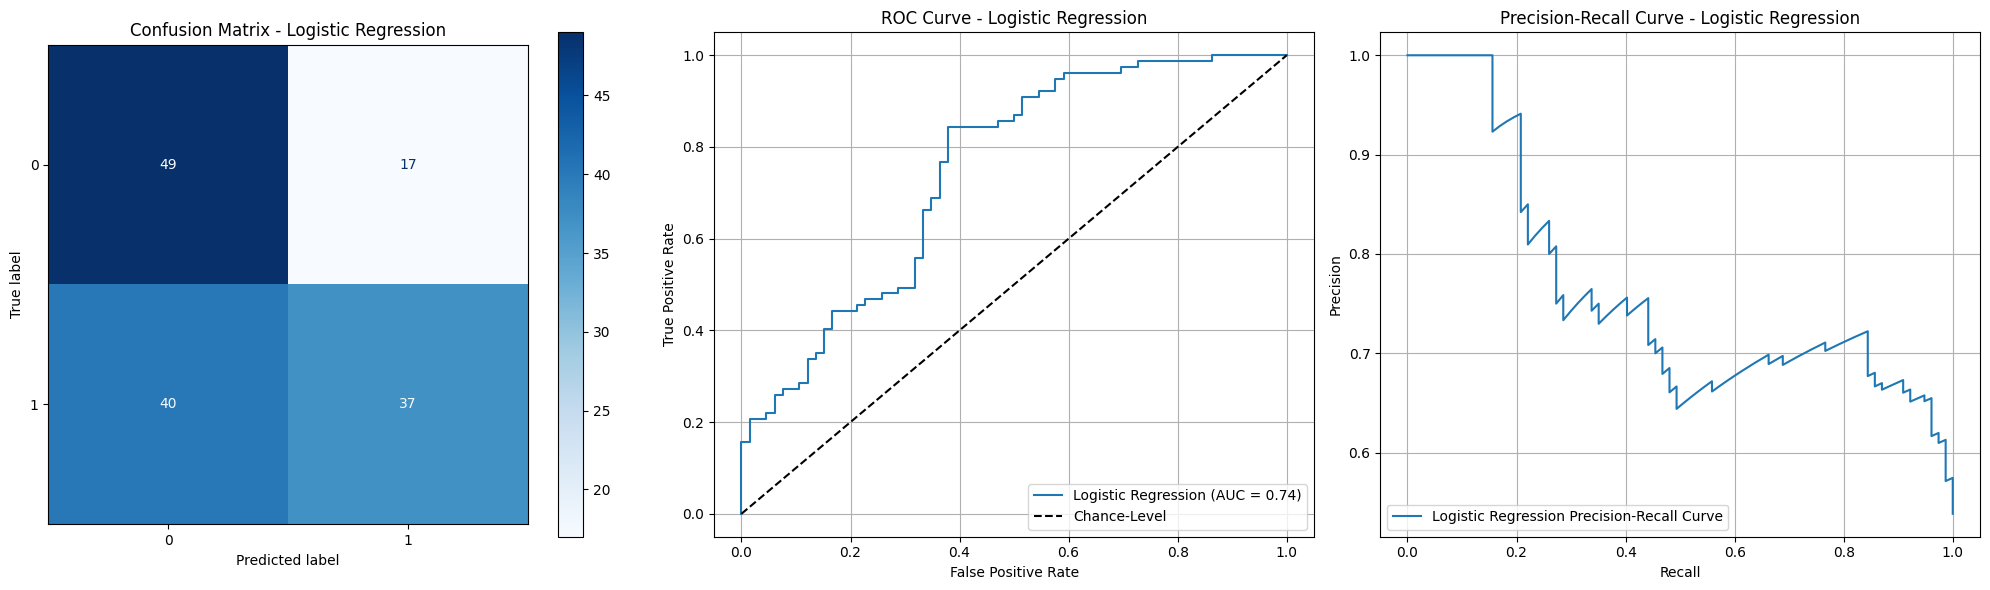

Evaluierung der Logistischen Regression abgeschlossen.


In [26]:
print("Starte Evaluierung für Logistische Regression...")

for fold_idx, (train_index, test_index) in enumerate(custom_cv):
    X_train_fold, X_test_fold = X_final.iloc[train_index], X_final.iloc[test_index]
    y_train_fold, y_test_fold = y_final.iloc[train_index], y_final.iloc[test_index]

    # Recreate the pipeline with best parameters for fitting on each fold
    from sklearn.linear_model import LogisticRegression
    log_reg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("log_reg", LogisticRegression(
            random_state=SEED,
            solver="saga",
            class_weight="balanced",
            max_iter=5000,
            C=best_log_reg_params['log_reg__C'],
            penalty=best_log_reg_params['log_reg__penalty']
        ))
    ])

    log_reg_pipeline.fit(X_train_fold, y_train_fold)

    y_pred_fold = log_reg_pipeline.predict(X_test_fold)
    y_proba_fold = log_reg_pipeline.predict_proba(X_test_fold)[:, 1]

    log_reg_all_y_true.extend(y_test_fold)
    log_reg_all_y_pred.extend(y_pred_fold)
    log_reg_all_y_proba.extend(y_proba_fold)

# Calculate pooled metrics
log_reg_metrics = calculate_metrics(log_reg_all_y_true, log_reg_all_y_pred, log_reg_all_y_proba)
all_model_results['Logistic Regression'] = log_reg_metrics

print("Pooled Metrics for Logistic Regression:")
for metric, value in log_reg_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_confusion_matrix(log_reg_all_y_true, log_reg_all_y_pred, 'Logistic Regression', ax=axes[0])
plot_roc_curve(log_reg_all_y_true, log_reg_all_y_proba, 'Logistic Regression', ax=axes[1])
plot_precision_recall_curve(log_reg_all_y_true, log_reg_all_y_proba, 'Logistic Regression', ax=axes[2])
plt.tight_layout()
plt.show()

print("Evaluierung der Logistischen Regression abgeschlossen.")

**3.3 Evaluation des Random-Forest-Modells über die Cross-Validation-Folds**

Das zuvor optimierte Random-Forest-Modell wird mit den ermittelten Hyperparametern innerhalb jedes Folds der zeitbasierten Cross-Validation erneut trainiert und auf dem jeweiligen Testzeitraum evaluiert. Die Vorhersagen aller Test-Folds werden anschließend zusammengeführt, um die Modellleistung anhand von Accuracy, Precision, Recall, F1-Score und ROC-AUC zu bestimmen. Ergänzend visualisieren die Confusion Matrix, ROC-Kurve und Precision-Recall-Kurve die Klassifikationsleistung, insbesondere im Hinblick auf die Erkennung von Rezessionsmonaten und mögliche Fehlklassifikationen.





Starte Evaluierung für Random Forest...
Pooled Metrics for Random Forest:
  Accuracy: 0.4755
  Precision: 1.0000
  Recall: 0.0260
  F1-Score: 0.0506
  ROC-AUC: 0.5849


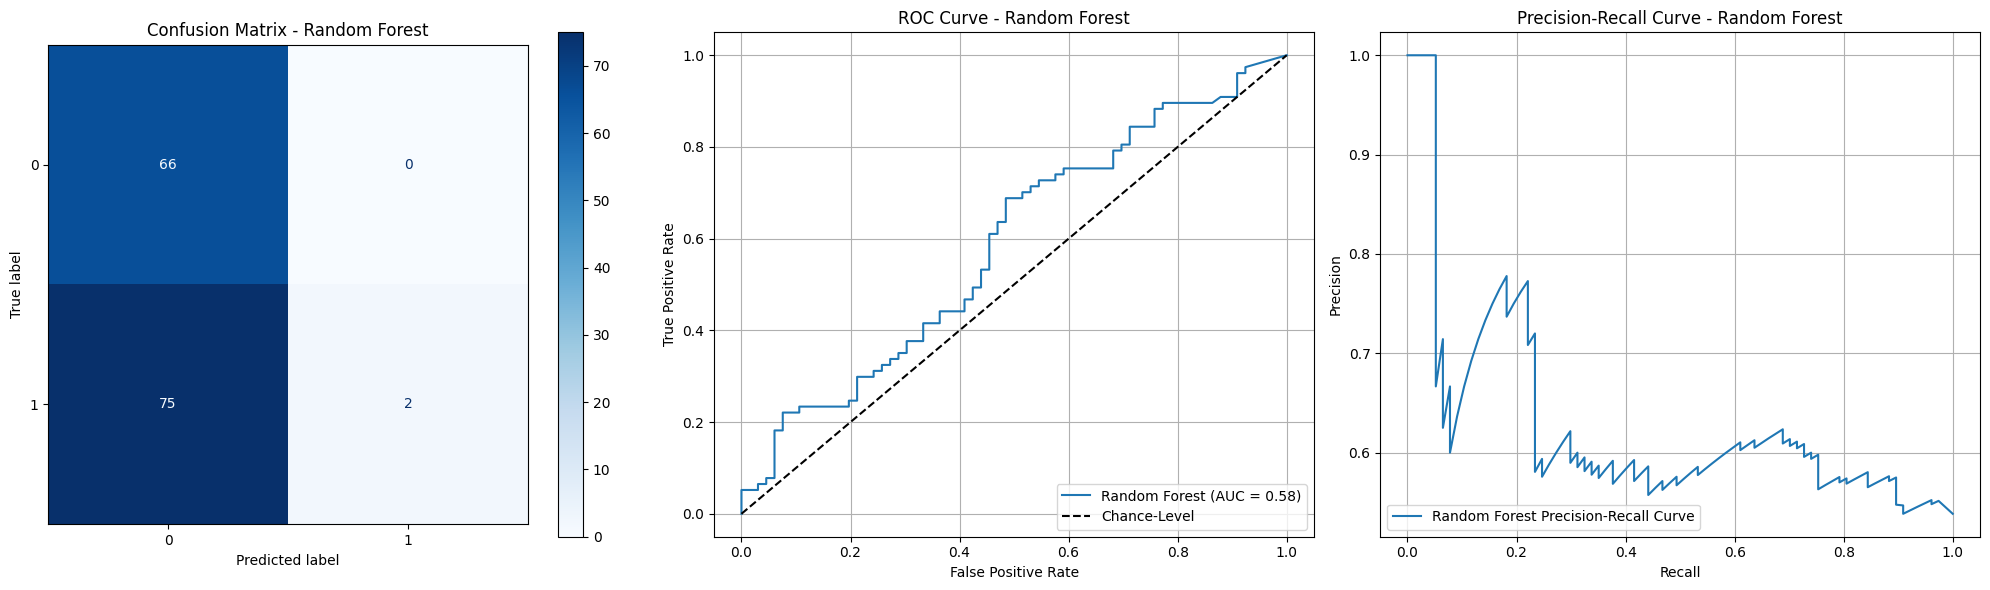

Evaluierung des Random Forest abgeschlossen.


In [27]:
print("Starte Evaluierung für Random Forest...")

for fold_idx, (train_index, test_index) in enumerate(custom_cv):
    X_train_fold, X_test_fold = X_final.iloc[train_index], X_final.iloc[test_index]
    y_train_fold, y_test_fold = y_final.iloc[train_index], y_final.iloc[test_index]

    # Recreate the classifier with best parameters
    from sklearn.ensemble import RandomForestClassifier
    rf_model = RandomForestClassifier(
        random_state=SEED,
        class_weight='balanced',
        n_estimators=best_rf_params['rf__n_estimators'],
        max_depth=best_rf_params['rf__max_depth'],
        min_samples_split=best_rf_params['rf__min_samples_split'],
        min_samples_leaf=best_rf_params['rf__min_samples_leaf'],
        max_features=best_rf_params['rf__max_features']
    )

    rf_model.fit(X_train_fold, y_train_fold)

    y_pred_fold = rf_model.predict(X_test_fold)
    y_proba_fold = rf_model.predict_proba(X_test_fold)[:, 1]

    rf_all_y_true.extend(y_test_fold)
    rf_all_y_pred.extend(y_pred_fold)
    rf_all_y_proba.extend(y_proba_fold)

# Calculate pooled metrics
rf_metrics = calculate_metrics(rf_all_y_true, rf_all_y_pred, rf_all_y_proba)
all_model_results['Random Forest'] = rf_metrics

print("Pooled Metrics for Random Forest:")
for metric, value in rf_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_confusion_matrix(rf_all_y_true, rf_all_y_pred, 'Random Forest', ax=axes[0])
plot_roc_curve(rf_all_y_true, rf_all_y_proba, 'Random Forest', ax=axes[1])
plot_precision_recall_curve(rf_all_y_true, rf_all_y_proba, 'Random Forest', ax=axes[2])
plt.tight_layout()
plt.show()

print("Evaluierung des Random Forest abgeschlossen.")

**3.4 Evaluation des XGBoost-Modells über die Cross-Validation-Folds**

Das optimierte XGBoost-Modell wird mit den zuvor ermittelten Hyperparametern innerhalb jedes Folds der zeitbasierten Cross-Validation erneut trainiert und auf dem jeweiligen Testzeitraum evaluiert. Das Klassenungleichgewicht wird dabei für jeden Trainings-Fold individuell über scale_pos_weight berücksichtigt. Anschließend werden die Vorhersagen aller Test-Folds zusammengeführt und anhand von Accuracy, Precision, Recall, F1-Score und ROC-AUC bewertet. Die Confusion Matrix, ROC-Kurve und Precision-Recall-Kurve ergänzen die quantitative Bewertung und ermöglichen eine genauere Beurteilung der Rezessionserkennung und möglicher Fehlklassifikationen.


Starte Evaluierung für XGBoost...
Pooled Metrics for XGBoost:
  Accuracy: 0.5455
  Precision: 0.7000
  Recall: 0.2727
  F1-Score: 0.3925
  ROC-AUC: 0.6993


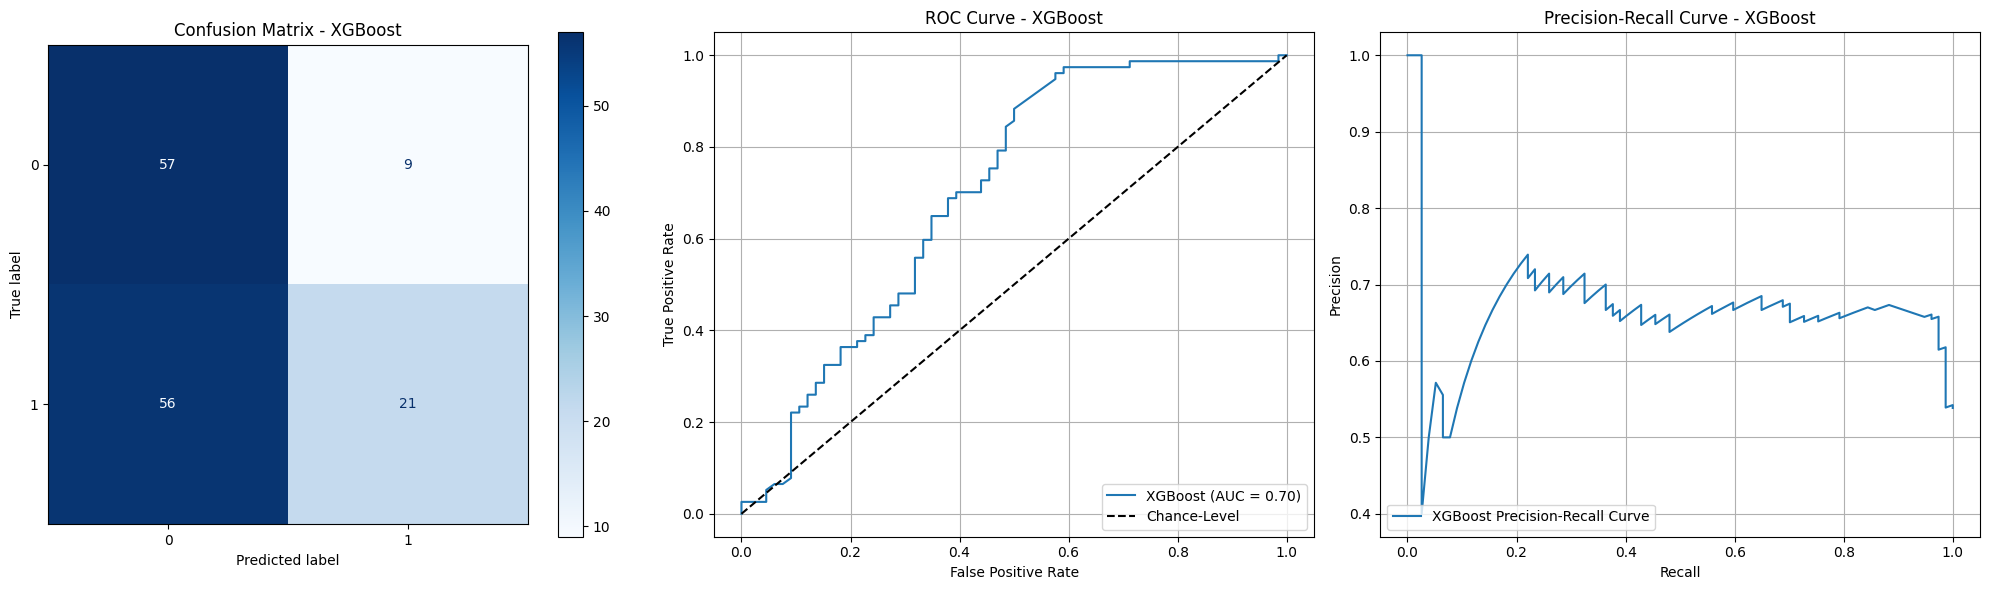

Evaluierung des XGBoost abgeschlossen.


In [28]:
print("Starte Evaluierung für XGBoost...")

for fold_idx, (train_index, test_index) in enumerate(custom_cv):
    X_train_fold, X_test_fold = X_final.iloc[train_index], X_final.iloc[test_index]
    y_train_fold, y_test_fold = y_final.iloc[train_index], y_final.iloc[test_index]

    # Calculate scale_pos_weight for the current training fold
    neg_count_fold = y_train_fold.value_counts().get(0, 0)
    pos_count_fold = y_train_fold.value_counts().get(1, 0)

    if pos_count_fold > 0:
        scale_pos_weight_fold = neg_count_fold / pos_count_fold
    else:
        scale_pos_weight_fold = 1.0 # Default if no positive samples in training fold

    # Recreate the classifier with best parameters
    import xgboost as xgb
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight_fold, # Apply calculated class imbalance weight per fold
        n_estimators=best_xgb_params['xgb__n_estimators'],
        max_depth=best_xgb_params['xgb__max_depth'],
        learning_rate=best_xgb_params['xgb__learning_rate'],
        subsample=best_xgb_params['xgb__subsample'],
        colsample_bytree=best_xgb_params['xgb__colsample_bytree'],
        min_child_weight=best_xgb_params['xgb__min_child_weight']
    )

    xgb_model.fit(X_train_fold, y_train_fold)

    y_pred_fold = xgb_model.predict(X_test_fold)
    y_proba_fold = xgb_model.predict_proba(X_test_fold)[:, 1]

    xgb_all_y_true.extend(y_test_fold)
    xgb_all_y_pred.extend(y_pred_fold)
    xgb_all_y_proba.extend(y_proba_fold)

# Calculate pooled metrics
xgb_metrics = calculate_metrics(xgb_all_y_true, xgb_all_y_pred, xgb_all_y_proba)
all_model_results['XGBoost'] = xgb_metrics

print("Pooled Metrics for XGBoost:")
for metric, value in xgb_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_confusion_matrix(xgb_all_y_true, xgb_all_y_pred, 'XGBoost', ax=axes[0])
plot_roc_curve(xgb_all_y_true, xgb_all_y_proba, 'XGBoost', ax=axes[1])
plot_precision_recall_curve(xgb_all_y_true, xgb_all_y_proba, 'XGBoost', ax=axes[2])
plt.tight_layout()
plt.show()

print("Evaluierung des XGBoost abgeschlossen.")

**3.5 Evaluation des GRU-Modells über die Cross-Validation-Folds**

Das optimierte GRU-Modell wird mit den zuvor bestimmten Hyperparametern für jeden Fold der zeitbasierten Cross-Validation erneut trainiert und auf dem jeweiligen Testzeitraum evaluiert. Die Eingabedaten werden foldweise standardisiert und das Klassenungleichgewicht über Class Weights berücksichtigt. Anschließend werden die Vorhersagen aller Test-Folds zusammengeführt und anhand von Accuracy, Precision, Recall, F1-Score und ROC-AUC bewertet sowie durch Confusion Matrix, ROC-Kurve und Precision-Recall-Kurve visualisiert.


Starte Evaluierung für GRU...
Pooled Metrics for GRU:
  Accuracy: 0.6154
  Precision: 0.6774
  Recall: 0.5455
  F1-Score: 0.6043
  ROC-AUC: 0.7021


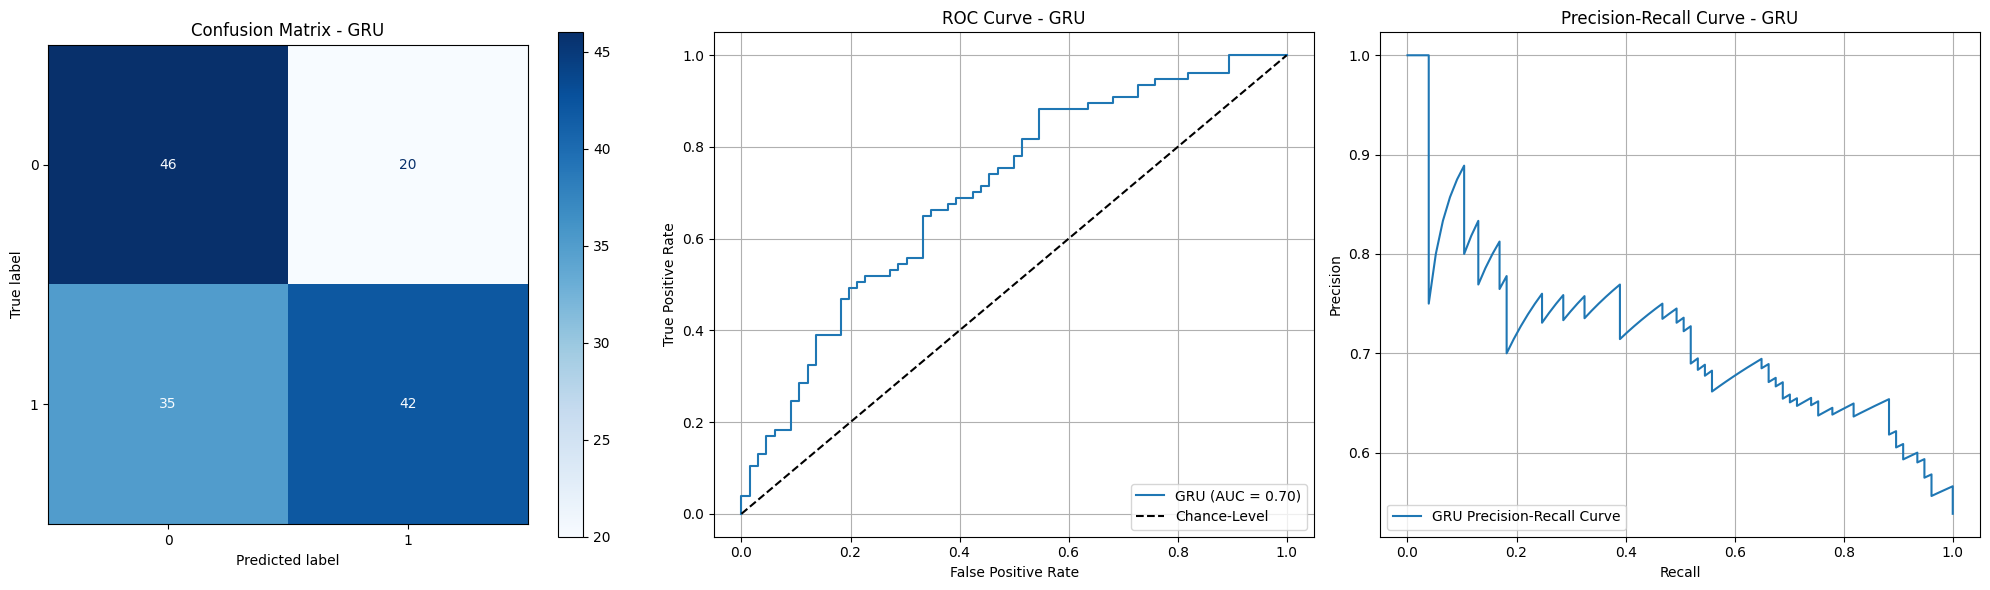

Evaluierung des GRU-Modells abgeschlossen.


In [29]:
print("Starte Evaluierung für GRU...")

# Re-define create_gru_model (from cell 2bfa030d) to ensure it's available
def create_gru_model(gru_units, dropout_rate, learning_rate, input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(units=gru_units, activation="tanh"),
        Dropout(rate=dropout_rate),
        Dense(units=1, activation="sigmoid")
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Data reshaping (from cell 2bfa030d)
num_timesteps = 12
original_features_count = X_final.shape[1] // num_timesteps
X_reshaped_for_gru = X_final.values.reshape(X_final.shape[0], num_timesteps, original_features_count)

for fold_idx, (train_index, test_index) in enumerate(custom_cv):
    tf.keras.backend.clear_session()
    run_seed = SEED + fold_idx # Different seed per fold for deep learning models
    tf.keras.utils.set_random_seed(run_seed)
    np.random.seed(run_seed)
    random.seed(run_seed)
    os.environ["PYTHONHASHSEED"] = str(run_seed)
    X_train_fold_reshaped = X_reshaped_for_gru[train_index]
    X_test_fold_reshaped = X_reshaped_for_gru[test_index]
    y_train_fold, y_test_fold = y_final.iloc[train_index], y_final.iloc[test_index]

    # Per-Fold Standardisierung (from cell _ZCuBPxsu716)
    scaler = StandardScaler()
    X_train_2d = X_train_fold_reshaped.reshape(-1, original_features_count)
    X_test_2d = X_test_fold_reshaped.reshape(-1, original_features_count)
    scaler.fit(X_train_2d)
    X_train_scaled = scaler.transform(X_train_2d).reshape(X_train_fold_reshaped.shape)
    X_test_scaled = scaler.transform(X_test_2d).reshape(X_test_fold_reshaped.shape)

    # Class Weights berechnen (from cell _ZCuBPxsu716)
    class_counts = y_train_fold.value_counts()
    class_weights = {
        cls: len(y_train_fold) / (len(class_counts) * count)
        for cls, count in class_counts.items()
    }

    # Create GRU model with best parameters
    gru_model = create_gru_model(
        gru_units=best_gru_params['gru_units'],
        dropout_rate=best_gru_params['dropout_rate'],
        learning_rate=best_gru_params['learning_rate'],
        input_shape=(num_timesteps, original_features_count)
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    gru_model.fit(
        X_train_scaled,
        y_train_fold,
        validation_split=0.2,
        epochs=best_gru_params['epochs'],
        batch_size=best_gru_params['batch_size'],
        class_weight=class_weights,
        callbacks=[early_stopping],
        shuffle=False,
        verbose=0
    )

    y_proba_fold = gru_model.predict(X_test_scaled, verbose=0).ravel()
    y_pred_fold = (y_proba_fold > 0.5).astype(int)

    gru_all_y_true.extend(y_test_fold)
    gru_all_y_pred.extend(y_pred_fold)
    gru_all_y_proba.extend(y_proba_fold)

# Calculate pooled metrics
gru_metrics = calculate_metrics(gru_all_y_true, gru_all_y_pred, gru_all_y_proba)
all_model_results['GRU'] = gru_metrics

print("Pooled Metrics for GRU:")
for metric, value in gru_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_confusion_matrix(gru_all_y_true, gru_all_y_pred, 'GRU', ax=axes[0])
plot_roc_curve(gru_all_y_true, gru_all_y_proba, 'GRU', ax=axes[1])
plot_precision_recall_curve(gru_all_y_true, gru_all_y_proba, 'GRU', ax=axes[2])
plt.tight_layout()
plt.show()

print("Evaluierung des GRU-Modells abgeschlossen.")

**3.6 Evaluation des LSTM-Modells über die Cross-Validation-Folds**

Das optimierte LSTM-Modell wird mit den zuvor bestimmten Hyperparametern innerhalb jedes Folds der zeitbasierten Cross-Validation erneut trainiert und auf dem jeweiligen Testzeitraum evaluiert. Die Daten werden dabei foldweise standardisiert und das Klassenungleichgewicht durch Class Weights berücksichtigt. Die zusammengeführten Vorhersagen werden anschließend anhand von Accuracy, Precision, Recall, F1-Score und ROC-AUC bewertet und mithilfe von Confusion Matrix, ROC-Kurve und Precision-Recall-Kurve visualisiert.


Starte Evaluierung für LSTM...
Pooled Metrics for LSTM:
  Accuracy: 0.6503
  Precision: 0.7213
  Recall: 0.5714
  F1-Score: 0.6377
  ROC-AUC: 0.7261


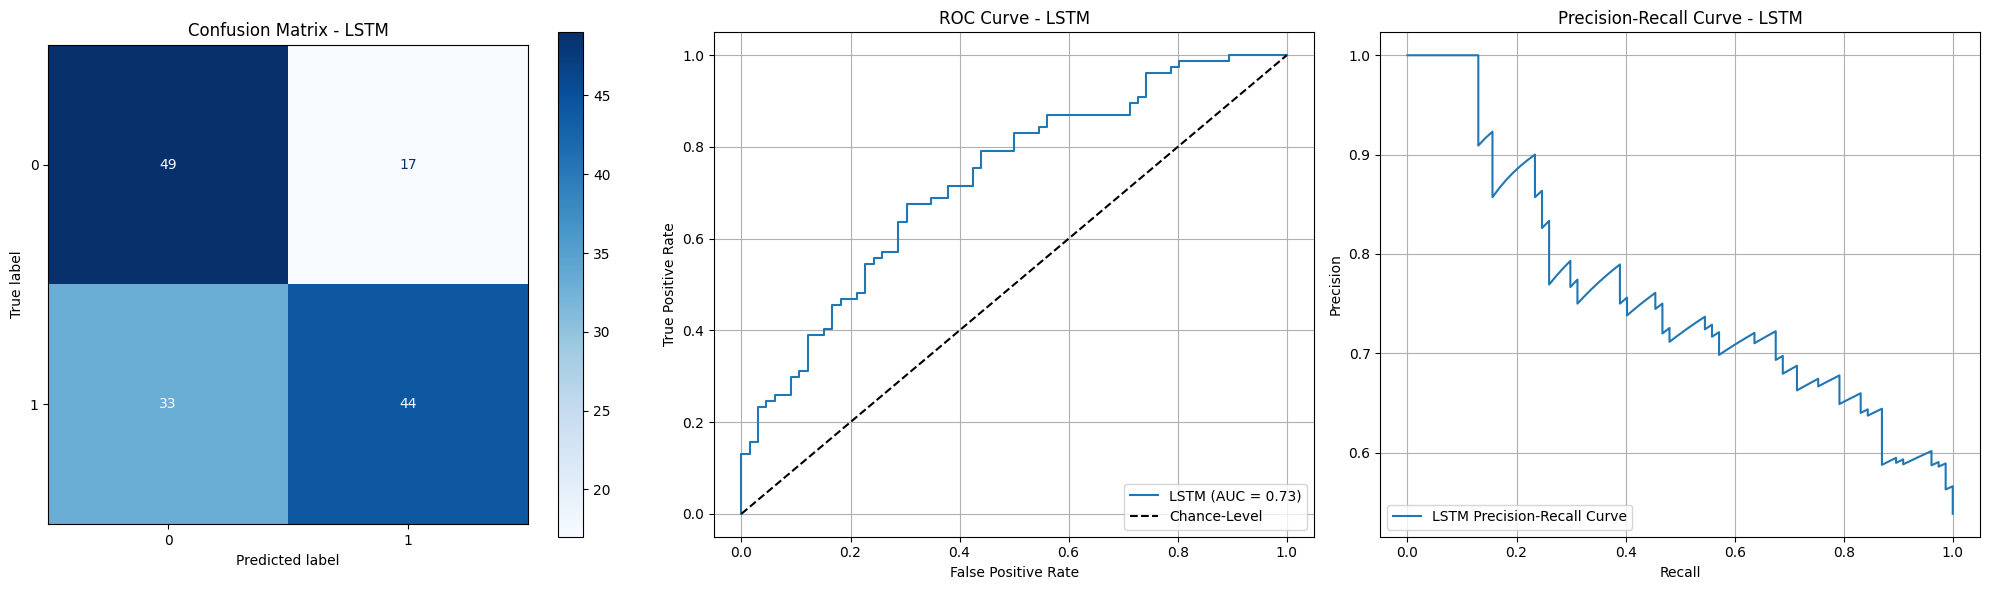

Evaluierung des LSTM-Modells abgeschlossen.


In [30]:
print("Starte Evaluierung für LSTM...")

# Re-define create_lstm_model (from cell j_CXySfz5Gzp) to ensure it's available
def create_lstm_model(lstm_units, dropout_rate, learning_rate, input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units=lstm_units, activation="tanh"),
        Dropout(rate=dropout_rate),
        Dense(units=1, activation="sigmoid")
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Data reshaping (from cell j_CXySfz5Gzp)
num_timesteps = 12
original_features_count = X_final.shape[1] // num_timesteps
X_reshaped_for_lstm = X_final.values.reshape(X_final.shape[0], num_timesteps, original_features_count)

for fold_idx, (train_index, test_index) in enumerate(custom_cv):
    tf.keras.backend.clear_session()
    run_seed = SEED + fold_idx # Different seed per fold for deep learning models
    tf.keras.utils.set_random_seed(run_seed)
    np.random.seed(run_seed)
    random.seed(run_seed)
    os.environ["PYTHONHASHSEED"] = str(run_seed)

    X_train_fold_reshaped = X_reshaped_for_lstm[train_index]
    X_test_fold_reshaped = X_reshaped_for_lstm[test_index]
    y_train_fold, y_test_fold = y_final.iloc[train_index], y_final.iloc[test_index]

    # Per-Fold Standardisierung (from cell L1LhkZoZU0Ua)
    scaler = StandardScaler()
    X_train_2d = X_train_fold_reshaped.reshape(-1, original_features_count)
    X_test_2d = X_test_fold_reshaped.reshape(-1, original_features_count)
    scaler.fit(X_train_2d)
    X_train_scaled = scaler.transform(X_train_2d).reshape(X_train_fold_reshaped.shape)
    X_test_scaled = scaler.transform(X_test_2d).reshape(X_test_fold_reshaped.shape)

    # Class Weights berechnen (from cell L1LhkZoZU0Ua)
    class_counts = y_train_fold.value_counts()
    class_weights = {} # Handle cases where one class might be missing (e.g., in early folds)
    if 0 in class_counts:
        class_weights[0] = len(y_train_fold) / (2 * class_counts[0])
    else:
        class_weights[0] = 1.0
    if 1 in class_counts:
        class_weights[1] = len(y_train_fold) / (2 * class_counts[1])
    else:
        class_weights[1] = 1.0

    # Create LSTM model with best parameters
    lstm_model = create_lstm_model(
        lstm_units=best_lstm_params['lstm_units'],
        dropout_rate=best_lstm_params['dropout_rate'],
        learning_rate=best_lstm_params['learning_rate'],
        input_shape=(num_timesteps, original_features_count)
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    lstm_model.fit(
        X_train_scaled,
        y_train_fold,
        validation_split=0.2,
        epochs=best_lstm_params['epochs'],
        batch_size=best_lstm_params['batch_size'],
        class_weight=class_weights,
        callbacks=[early_stopping],
        shuffle=False,
        verbose=0
    )

    y_proba_fold = lstm_model.predict(X_test_scaled, verbose=0).ravel()
    y_pred_fold = (y_proba_fold > 0.5).astype(int)

    lstm_all_y_true.extend(y_test_fold)
    lstm_all_y_pred.extend(y_pred_fold)
    lstm_all_y_proba.extend(y_proba_fold)

# Calculate pooled metrics
lstm_metrics = calculate_metrics(lstm_all_y_true, lstm_all_y_pred, lstm_all_y_proba)
all_model_results['LSTM'] = lstm_metrics

print("Pooled Metrics for LSTM:")
for metric, value in lstm_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_confusion_matrix(lstm_all_y_true, lstm_all_y_pred, 'LSTM', ax=axes[0])
plot_roc_curve(lstm_all_y_true, lstm_all_y_proba, 'LSTM', ax=axes[1])
plot_precision_recall_curve(lstm_all_y_true, lstm_all_y_proba, 'LSTM', ax=axes[2])
plt.tight_layout()
plt.show()

print("Evaluierung des LSTM-Modells abgeschlossen.")

## **4 Ergebnisse**

**4.1 Vergleichende Gesamtbewertung der Modelle**


Welches Modell erzielt die höchste Vorhersageleistung?

Die Evaluationsergebnisse aller untersuchten Modelle werden in einer gemeinsamen Vergleichstabelle zusammengeführt. Hierzu werden Accuracy, Precision, Recall, F1-Score und ROC-AUC für Logistic Regression, Random Forest, XGBoost, GRU und LSTM gegenübergestellt. Die Modelle werden nach dem ROC-AUC sortiert, um einen übersichtlichen Vergleich ihrer Klassifikationsleistung zu ermöglichen.











In [31]:
# Create a list to store data for the comparison DataFrame
model_comparison_rows = []

# Populate the list with results from all_model_results
for model_name, metrics in all_model_results.items():
    model_comparison_rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC']
    })

comparison_df = pd.DataFrame(model_comparison_rows)

# Sort by ROC-AUC (descending) for better comparison
comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("Vergleichstabelle der Modelle (Vollständige Metriken nach finaler Evaluierung):")
display(comparison_df)

print("\nDie Metriken in dieser Tabelle wurden durch die finale Evaluierung mit den jeweils besten Hyperparametern und der Expanding-Window Time-Series Cross-Validation berechnet.")

Vergleichstabelle der Modelle (Vollständige Metriken nach finaler Evaluierung):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.601399,0.685185,0.480519,0.564885,0.744392
1,LSTM,0.650350,0.721311,0.571429,0.637681,0.726092
2,GRU,0.615385,0.677419,0.545455,0.604317,0.702086
3,XGBoost,0.545455,0.700000,0.272727,0.392523,0.699331
4,Random Forest,0.475524,1.000000,0.025974,0.050633,0.584908



Die Metriken in dieser Tabelle wurden durch die finale Evaluierung mit den jeweils besten Hyperparametern und der Expanding-Window Time-Series Cross-Validation berechnet.


**Vergleich der Modellleistung**

Die Tabelle präsentiert die Resultate der finalen Evaluation der untersuchten Modelle auf Grundlage der jeweils **optimierten Hyperparameter** sowie der **Expanding-Window Time-Series Cross-Validation**. Zur Bewertung werden die Metriken Accuracy, Precision, Recall, F1-Score und ROC-AUC herangezogen.

In der vorliegenden Untersuchung wurde festgestellt, dass das LSTM-Modell im Vergleich die ausgewogenste Leistung erzielt. Das Modell erzielt die höchste Accuracy (**0,6504**), den höchsten Recall (**0,5714**) sowie den höchsten F1-Score (**0,6377**). Die logistische Regression weist mit 0,7444 den höchsten ROC-AUC auf und zeigt damit die beste Trennfähigkeit zwischen Rezessions- und Nicht-Rezessionsperioden. Das GRU-Modell erzielt ebenfalls solide Ergebnisse, bleibt jedoch hinter LSTM und logistischer Regression zurück.

XGBoost und insbesondere Random Forest zeigen einen deutlich niedrigeren Recall und erkennen somit nur einen geringen Anteil der tatsächlichen Rezessionsfälle. Die Auswertung der Ergebnisse lässt den Schluss zu, dass kein Modell in sämtlichen Bewertungsmetriken als überlegen zu betrachten ist. Das LSTM erzielt die ausgewogenste Klassifikationsleistung, während die logistische Regression die höchste ROC-AUC aufweist.


**4.1.1 Grafischer Vergleich der Klassifikationsleistung aller Modelle**


Die Vorhersagewahrscheinlichkeiten der fünf Modelle werden gemeinsam anhand von ROC-Kurven und Precision-Recall-Kurven visualisiert. Die ROC-Kurven ermöglichen den Vergleich der Modelle hinsichtlich ihrer Fähigkeit, Rezessions- und Nicht-Rezessionsmonate zu unterscheiden, während die Precision-Recall-Kurven insbesondere das Verhältnis zwischen der Erkennung tatsächlicher Rezessionen und der Zuverlässigkeit der Rezessionssignale darstellen. Die gemeinsame Darstellung ergänzt die zuvor erstellte metrische Vergleichstabelle um einen grafischen Modellvergleich.

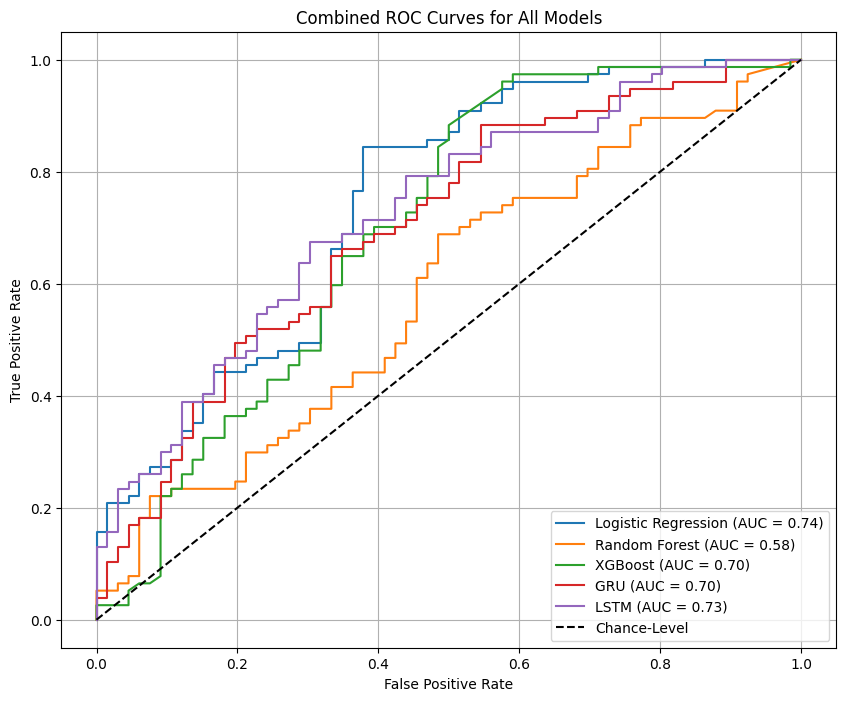

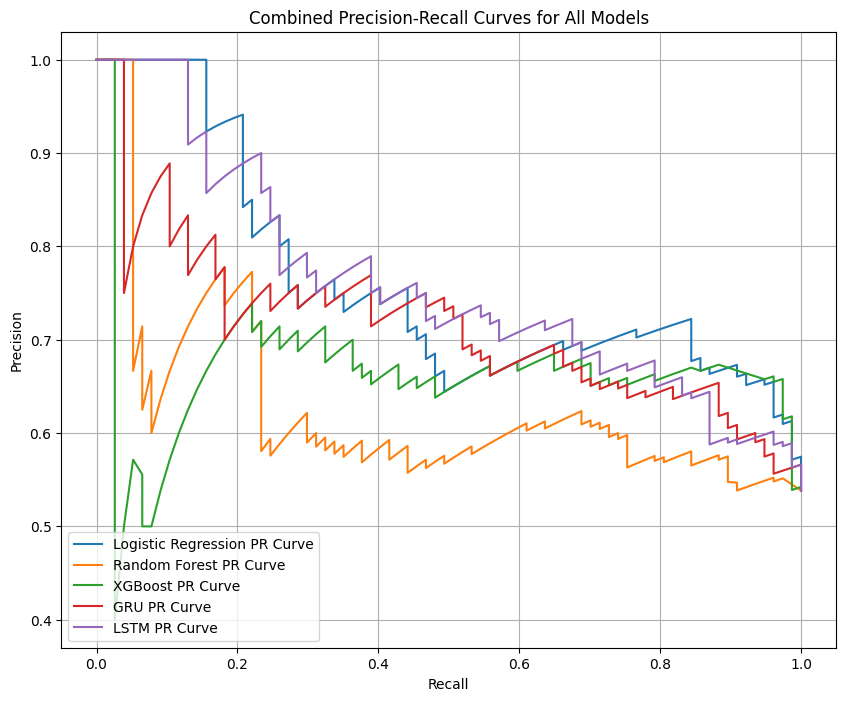

In [32]:
kimport matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

# Prepare data for plotting
model_predictions = {
    'Logistic Regression': {'y_true': log_reg_all_y_true, 'y_proba': log_reg_all_y_proba},
    'Random Forest': {'y_true': rf_all_y_true, 'y_proba': rf_all_y_proba},
    'XGBoost': {'y_true': xgb_all_y_true, 'y_proba': xgb_all_y_proba},
    'GRU': {'y_true': gru_all_y_true, 'y_proba': gru_all_y_proba},
    'LSTM': {'y_true': lstm_all_y_true, 'y_proba': lstm_all_y_proba}
}

# --- Combined ROC Curve Plot ---
plt.figure(figsize=(10, 8))
plt.title('Combined ROC Curves for All Models')

for model_name, data in model_predictions.items():
    y_true = np.array(data['y_true'])
    y_proba = np.array(data['y_proba'])

    # Check for single class in y_true before calculating ROC curve
    if len(np.unique(y_true)) > 1:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        roc_auc = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    else:
        print(f"Warning: ROC Curve for {model_name} not applicable (single class in y_true).")

plt.plot([0, 1], [0, 1], 'k--', label='Chance-Level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- Combined Precision-Recall Curve Plot ---
plt.figure(figsize=(10, 8))
plt.title('Combined Precision-Recall Curves for All Models')

for model_name, data in model_predictions.items():
    y_true = np.array(data['y_true'])
    y_proba = np.array(data['y_proba'])

    # Check for single class in y_true before calculating PR curve
    if len(np.unique(y_true)) > 1:
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        # Note: AUPRC (Area Under Precision-Recall Curve) can also be calculated,
        # but for simplicity, we'll just plot the curve here.
        plt.plot(recall, precision, label=f'{model_name} PR Curve')
    else:
        print(f"Warning: Precision-Recall Curve for {model_name} not applicable (single class in y_true).")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

**4.2 Visualisierung der Rezessionswahrscheinlichkeiten im Zeitverlauf**

Für jedes Modell werden die vorhergesagten Rezessionswahrscheinlichkeiten über den Untersuchungszeitraum dargestellt. Die tatsächlichen Rezessionsperioden werden zusätzlich im Hintergrund markiert, sodass sichtbar wird, wie sich die Modellprognosen während Rezessions- und Nicht-Rezessionsphasen entwickeln. Abschließend werden die drei Modelle mit dem höchsten ROC-AUC gemeinsam dargestellt, um ihre Wahrscheinlichkeitsverläufe direkt miteinander zu vergleichen.

Starte Generierung der Plots für Rezessionswahrscheinlichkeiten...
Generiere Plot für Logistic Regression...


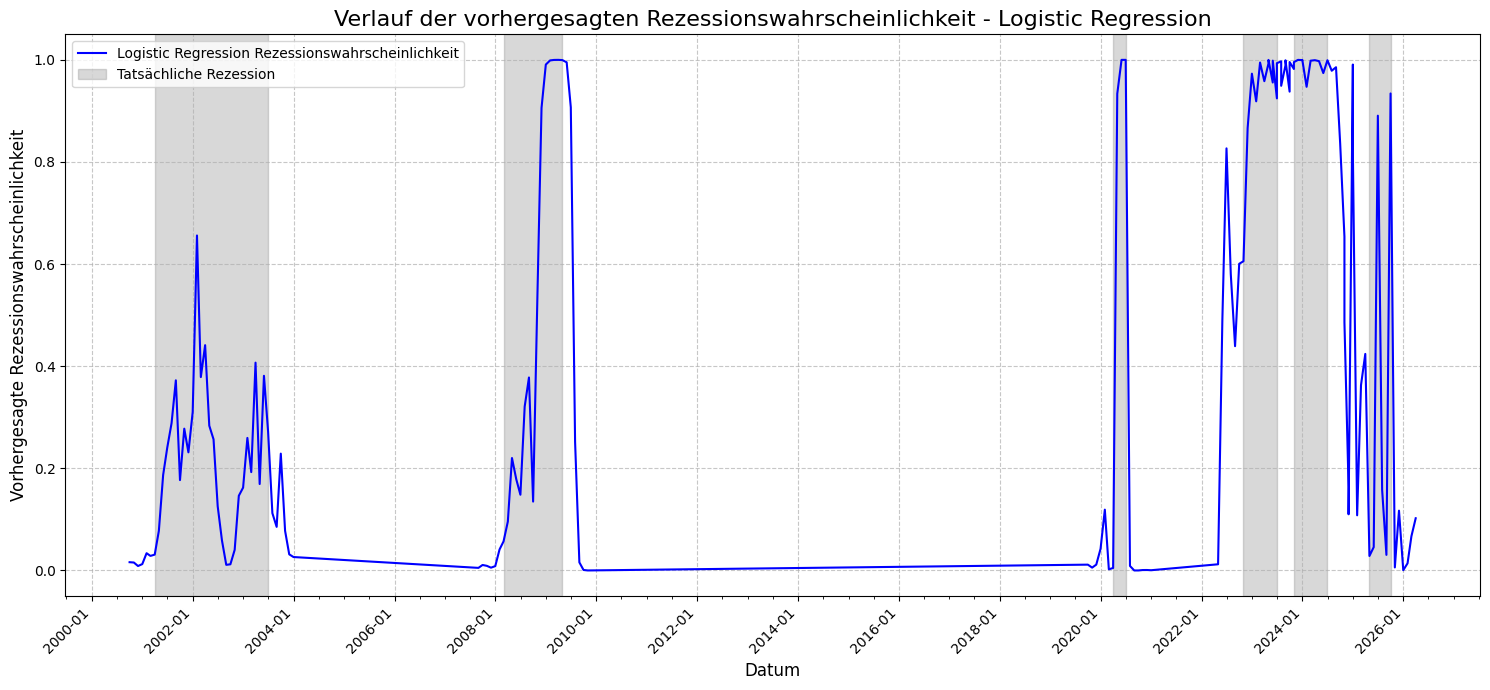

Plot für Logistic Regression gespeichert: plots_recession_probability/recession_probability_over_time_Logistic_Regression.png
Generiere Plot für Random Forest...


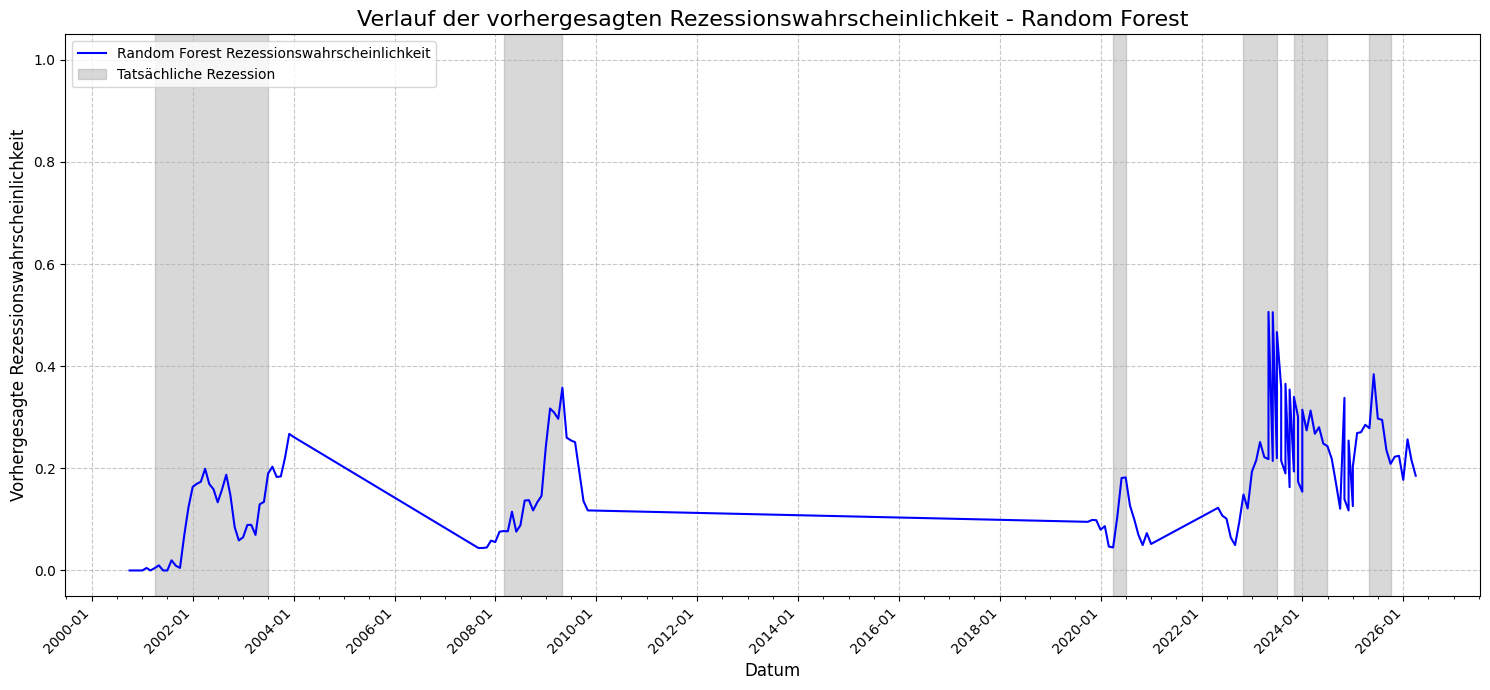

Plot für Random Forest gespeichert: plots_recession_probability/recession_probability_over_time_Random_Forest.png
Generiere Plot für XGBoost...


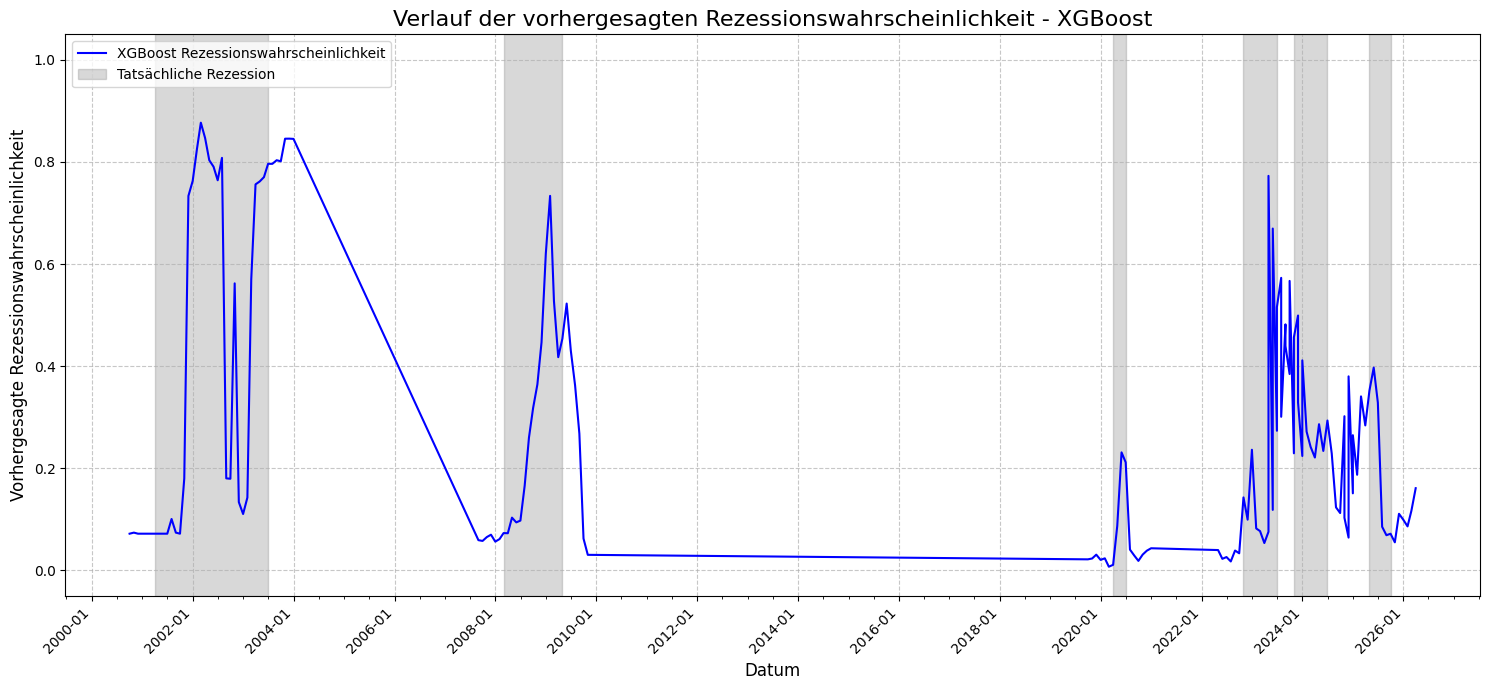

Plot für XGBoost gespeichert: plots_recession_probability/recession_probability_over_time_XGBoost.png
Generiere Plot für GRU...


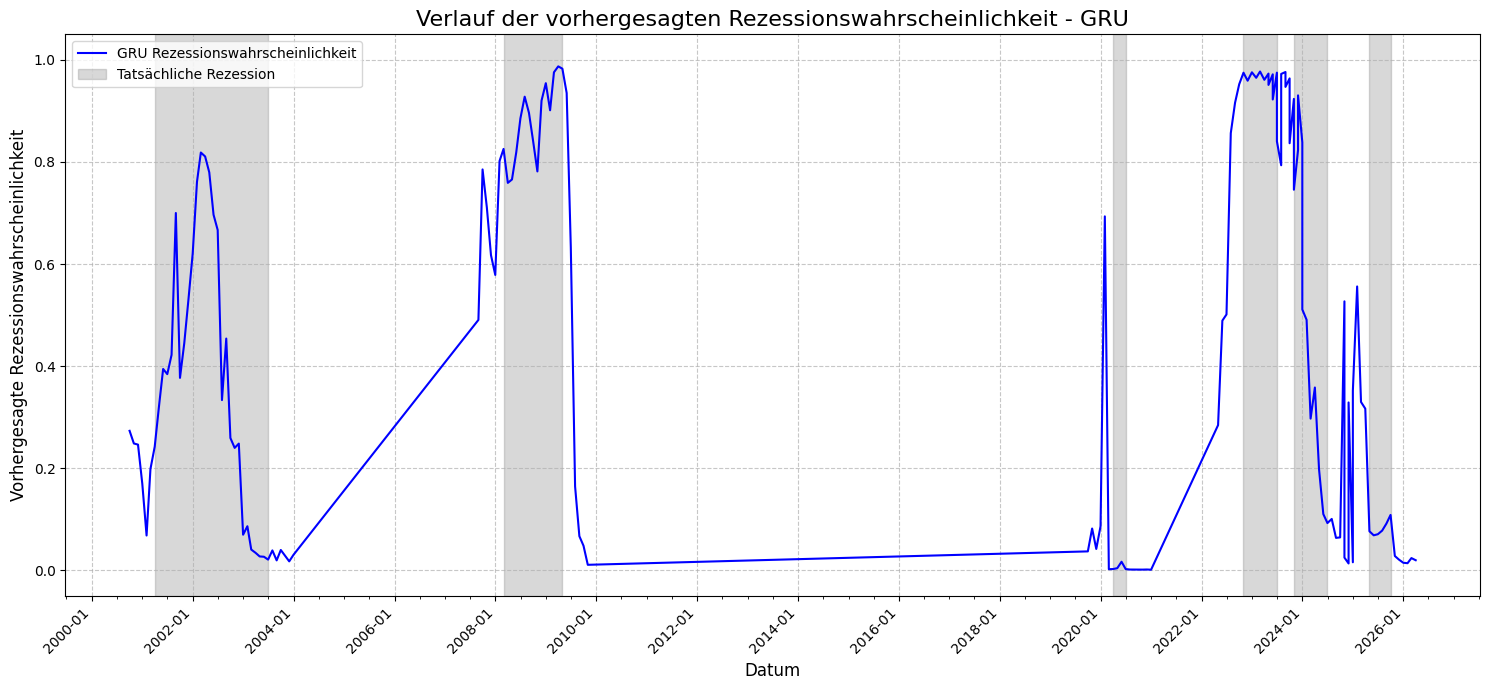

Plot für GRU gespeichert: plots_recession_probability/recession_probability_over_time_GRU.png
Generiere Plot für LSTM...


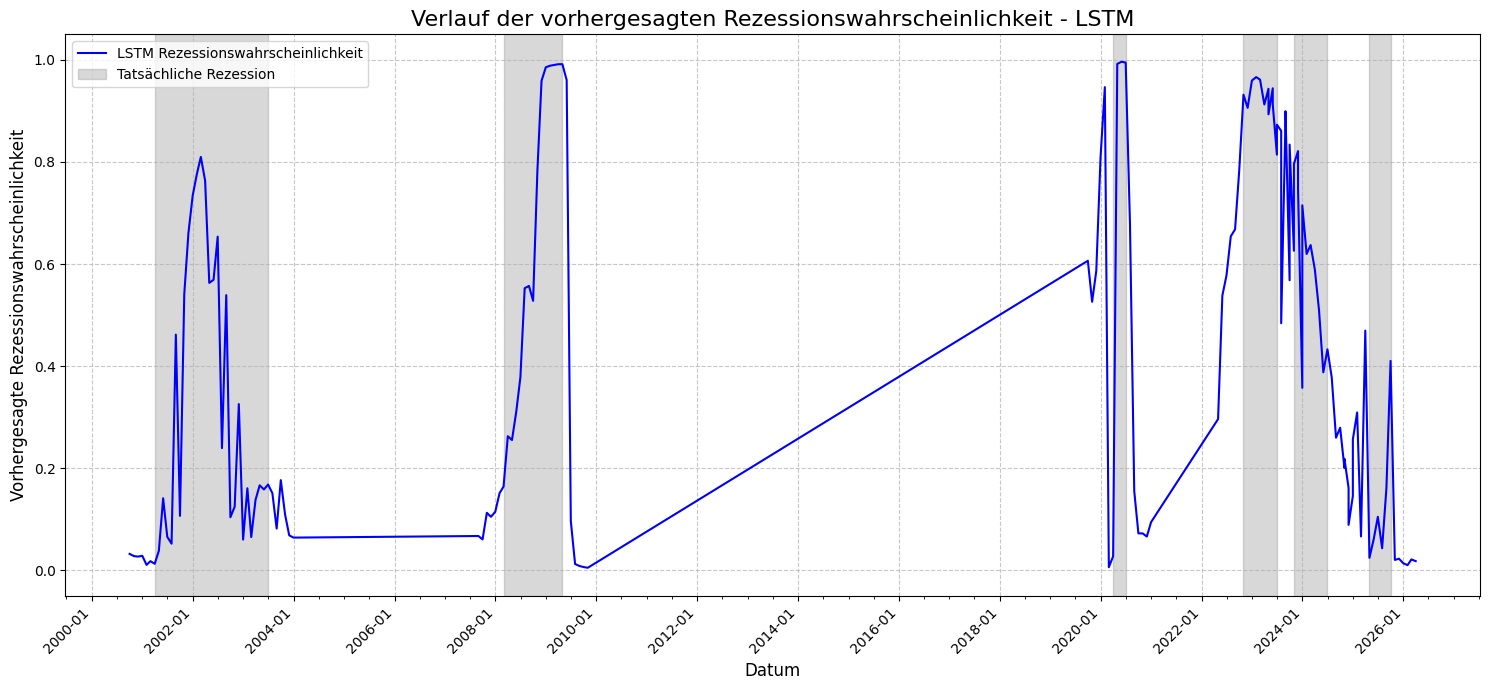

Plot für LSTM gespeichert: plots_recession_probability/recession_probability_over_time_LSTM.png

Generiere kombinierten Plot der besten Modelle...


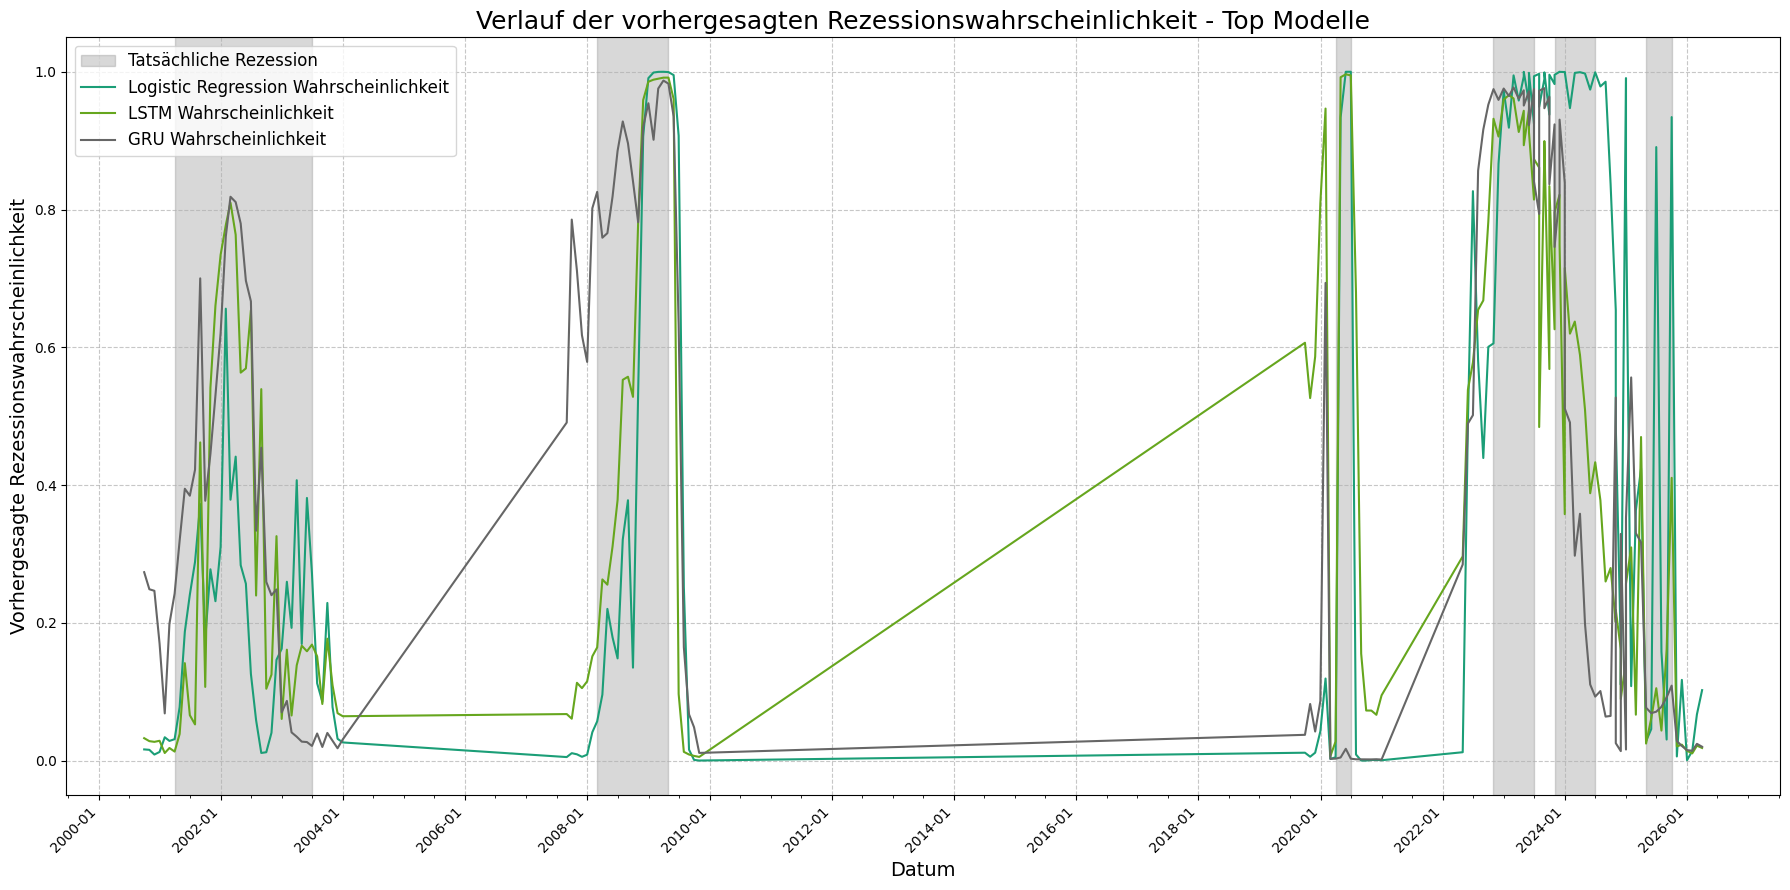

Kombinierter Plot gespeichert: plots_recession_probability/recession_probability_over_time_combined_top_models.png


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Stellen Sie sicher, dass der Ausgabeordner existiert
output_dir = "plots_recession_probability" # Changed for portability
os.makedirs(output_dir, exist_ok=True)

print("Starte Generierung der Plots für Rezessionswahrscheinlichkeiten...")

# 1. Daten für die Zeitachse der gepoolten Vorhersagen extrahieren
# Die 'Datum'-Spalte aus dem 'dates'-Series wird benötigt.
# custom_cv enthält die Testindizes in der richtigen Reihenfolge.

# Assuming 'dates' (Series with 'Datum' column) and 'custom_cv' are available from previous cells.

if 'dates' not in locals() and 'dates' not in globals():
    raise NameError("Series 'dates' wurde nicht gefunden. Bitte vorherige Zellen ausführen.")

if 'custom_cv' not in locals() and 'custom_cv' not in globals():
    raise NameError("'custom_cv' wurde nicht gefunden. Bitte vorherige Zellen ausführen.")

dates_for_pooled_predictions = []
for _, test_index in custom_cv:
    dates_for_pooled_predictions.extend(dates.iloc[test_index].tolist())

# Konvertieren in eine Pandas Series, um Datumsfunktionen zu nutzen
dates_for_pooled_predictions_series = pd.to_datetime(pd.Series(dates_for_pooled_predictions))

# 2. Plotting-Funktion definieren
def plot_recession_probability(
    model_name,
    y_true,
    y_proba,
    dates,
    output_dir,
    dpi_val=300, # Renamed dpi to dpi_val to avoid conflict with global dpi if defined
    show_plot=True
):

    # DataFrame für einfaches Plotten erstellen und nach Datum sortieren
    plot_df = pd.DataFrame({
        'Date': dates,
        'True_Recession': y_true,
        'Predicted_Probability': y_proba
    })
    plot_df = plot_df.sort_values(by='Date').reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, 7))

    # Plot vorhergesagte Wahrscheinlichkeiten
    ax.plot(
        plot_df['Date'],
        plot_df['Predicted_Probability'],
        label=f'{model_name} Rezessionswahrscheinlichkeit',
        color='blue',
        linewidth=1.5
    )

    # Tatsächliche Rezessionsperioden als graue Flächen hervorheben
    recession_shaded = False
    # Finden von zusammenhängenden Rezessionsperioden (y_true == 1)
    recession_groups = (plot_df['True_Recession'].diff() != 0).cumsum()
    for group_id in recession_groups.unique():
        sub_df = plot_df[recession_groups == group_id]
        if sub_df['True_Recession'].iloc[0] == 1: # Nur wenn es tatsächlich eine Rezession ist
            start_date = sub_df['Date'].min()
            end_date = sub_df['Date'].max()
            ax.axvspan(
                start_date,
                end_date,
                color='grey',
                alpha=0.3,
                label='Tatsächliche Rezession' if not recession_shaded else ""
            )
            recession_shaded = True # Label nur einmal hinzufügen

    # Formatierung des Plots
    ax.set_title(
        f'Verlauf der vorhergesagten Rezessionswahrscheinlichkeit - {model_name}',
        fontsize=16
    )
    ax.set_xlabel('Datum', fontsize=12)
    ax.set_ylabel('Vorhergesagte Rezessionswahrscheinlichkeit', fontsize=12)
    ax.set_ylim(-0.05, 1.05) # Sicherstellen, dass der Bereich 0-1 sichtbar ist
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left', fontsize=10)

    # Datumsformatierung auf der x-Achse
    formatter = mdates.DateFormatter('%Y-%m')
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_locator(mdates.YearLocator(2)) # Alle 2 Jahre Haupt-Ticks
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1,7))) # Alle 6 Monate Neben-Ticks
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()

    # Plot speichern
    filename = os.path.join(output_dir, f'recession_probability_over_time_{model_name.replace(" ", "_")}.png')
    plt.savefig(filename, dpi=dpi_val, bbox_inches='tight')
    if show_plot:
        plt.show()
    plt.close(fig) # Schließen der Figur, um Speicher freizugeben
    print(f"Plot für {model_name} gespeichert: {filename}")

# 3. Durchlaufen der Modelle und Plots generieren
models_to_plot = {
    'Logistic Regression': {'y_true_var': 'log_reg_all_y_true', 'y_proba_var': 'log_reg_all_y_proba'},
    'Random Forest':       {'y_true_var': 'rf_all_y_true',      'y_proba_var': 'rf_all_y_proba'},
    'XGBoost':             {'y_true_var': 'xgb_all_y_true',     'y_proba_var': 'xgb_all_y_proba'},
    'GRU':                 {'y_true_var': 'gru_all_y_true',     'y_proba_var': 'gru_all_y_proba'},
    'LSTM':                {'y_true_var': 'lstm_all_y_true',    'y_proba_var': 'lstm_all_y_proba'}
}

successful_models = []

for model_name, var_names in models_to_plot.items():
    y_true_list = globals().get(var_names['y_true_var'])
    y_proba_list = globals().get(var_names['y_proba_var'])

    if y_true_list is not None and y_proba_list is not None:
        # Sicherstellen, dass y_true_list und y_proba_list numpy arrays sind, falls noch nicht geschehen
        y_true_np = np.array(y_true_list)
        y_proba_np = np.array(y_proba_list)

        print(f"Generiere Plot für {model_name}...")
        try:
            plot_recession_probability(
                model_name,
                y_true_np,
                y_proba_np,
                dates_for_pooled_predictions_series,
                output_dir,
                dpi_val=300 # Pass dpi_val here
            )
            successful_models.append(model_name)
        except Exception as e:
            print(f"Fehler beim Plotten für {model_name}: {e}")
    else:
        print(f"Warnung: Variablen '{var_names['y_true_var']}' oder '{var_names['y_proba_var']}' für {model_name} nicht gefunden. Überspringe Plot.")

# 4. Kombinierter Plot der besten Modelle (optional, falls comparison_df existiert)
if successful_models:
    print("\nGeneriere kombinierten Plot der besten Modelle...")
    if 'comparison_df' in locals() or 'comparison_df' in globals():
        # Filtern nach erfolgreich geplotteten Modellen und Sortieren nach ROC-AUC
        top_models_for_combined_plot = comparison_df[
            comparison_df['Model'].isin(successful_models)
        ].sort_values(by='ROC-AUC', ascending=False).head(3)['Model'].tolist()

        if top_models_for_combined_plot:
            fig_combined, ax_combined = plt.subplots(figsize=(18, 9))

            # Tatsächliche Rezessionsperioden einmal für den kombinierten Plot
            # Wir verwenden hier die plot_df-Struktur aus der letzten erfolgreichen Plot-Generierung
            # Es ist wichtig, dass diese plot_df (oder ein äquivalentes DF) existiert und die tatsächlichen Rezessionen korrekt enthält.
            # Eine robustere Lösung wäre, plot_df für True_Recession hier neu zu erstellen:
            temp_plot_df = pd.DataFrame({
                'Date': dates_for_pooled_predictions_series,
                'True_Recession': np.array(globals().get(models_to_plot[successful_models[0]]['y_true_var'])) # Nehmen wir y_true vom ersten erfolgreichen Modell
            }).sort_values(by='Date').reset_index(drop=True)

            recession_shaded_combined = False
            recession_groups_combined = (temp_plot_df['True_Recession'].diff() != 0).cumsum()
            for group_id in recession_groups_combined.unique():
                sub_df_combined = temp_plot_df[recession_groups_combined == group_id]
                if sub_df_combined['True_Recession'].iloc[0] == 1:
                    start_date_combined = sub_df_combined['Date'].min()
                    end_date_combined = sub_df_combined['Date'].max()
                    ax_combined.axvspan(
                        start_date_combined,
                        end_date_combined,
                        color='grey',
                        alpha=0.3,
                        label='Tatsächliche Rezession' if not recession_shaded_combined else ""
                    )
                    recession_shaded_combined = True

            # Farbpalette für die Modelle
            colors = plt.colormaps["Dark2"] # Use plt.colormaps for modern API

            for i, model_name in enumerate(top_models_for_combined_plot):
                var_names = models_to_plot[model_name]
                y_proba_list = globals().get(var_names['y_proba_var'])

                combined_plot_df = pd.DataFrame({
                    'Date': dates_for_pooled_predictions_series,
                    'Predicted_Probability': y_proba_list
                }).sort_values(by='Date').reset_index(drop=True)

                ax_combined.plot(
                    combined_plot_df['Date'],
                    combined_plot_df['Predicted_Probability'],
                    label=f'{model_name} Wahrscheinlichkeit',
                    color=colors(i / (len(top_models_for_combined_plot) - 1)) if len(top_models_for_combined_plot) > 1 else colors(0), # Normalize i for colormap
                    linewidth=1.5
                )

            # Formatierung des kombinierten Plots
            ax_combined.set_title(
                'Verlauf der vorhergesagten Rezessionswahrscheinlichkeit - Top Modelle',
                fontsize=18
            )
            ax_combined.set_xlabel('Datum', fontsize=14)
            ax_combined.set_ylabel('Vorhergesagte Rezessionswahrscheinlichkeit', fontsize=14)
            ax_combined.set_ylim(-0.05, 1.05)
            ax_combined.grid(True, linestyle='--', alpha=0.7)
            ax_combined.legend(loc='upper left', fontsize=12)

            formatter_combined = mdates.DateFormatter('%Y-%m')
            ax_combined.xaxis.set_major_formatter(formatter_combined)
            ax_combined.xaxis.set_major_locator(mdates.YearLocator(2))
            ax_combined.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1,7)))
            plt.xticks(rotation=45, ha='right')

            plt.tight_layout()
            filename_combined = os.path.join(output_dir, 'recession_probability_over_time_combined_top_models.png')
            plt.savefig(filename_combined, dpi=300, bbox_inches='tight') # Fixed dpi directly
            plt.show()
            plt.close(fig_combined)
            print(f"Kombinierter Plot gespeichert: {filename_combined}")
        else:
            print("Keine Top-Modelle für den kombinierten Plot gefunden.")
    else:
        print("Warnung: 'comparison_df' für die Auswahl der besten Modelle nicht gefunden. Überspringe kombinierten Plot.")
else:
    print("Keine Modelle wurden erfolgreich geplottet, überspringe kombinierten Plot.")

## **4.3 Bewertung der wichtigsten Indikatoren**

**4.3.1 SHAP-Analyse für Random Forest und XGBoost**

Starte SHAP-Analyse für Random Forest und XGBoost...
Anzahl der ursprünglichen Indikatoren: 28

Berechne SHAP-Werte für Random Forest...
Aggregierte SHAP-Werte für Random Forest berechnet.


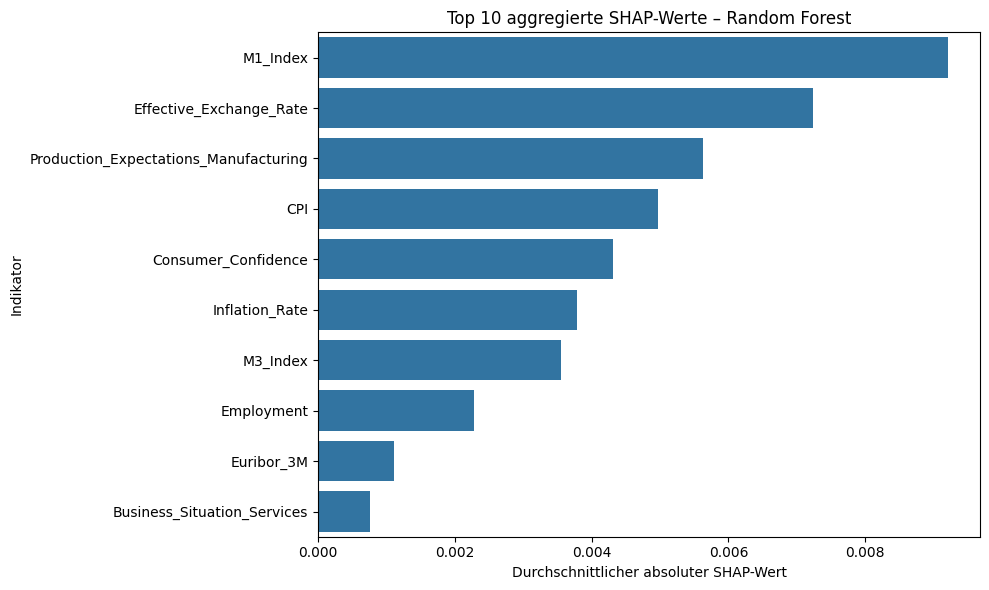


Top 10 SHAP-Indikatoren – Random Forest:


,SHAP Importance
M1_Index,0.009
Effective_Exchange_Rate,0.007
Production_Expectations_Manufacturing,0.006
CPI,0.005
Consumer_Confidence,0.004
Inflation_Rate,0.004
M3_Index,0.004
Employment,0.002
Euribor_3M,0.001
Business_Situation_Services,0.001



Berechne SHAP-Werte für XGBoost...
Aggregierte SHAP-Werte für XGBoost berechnet.


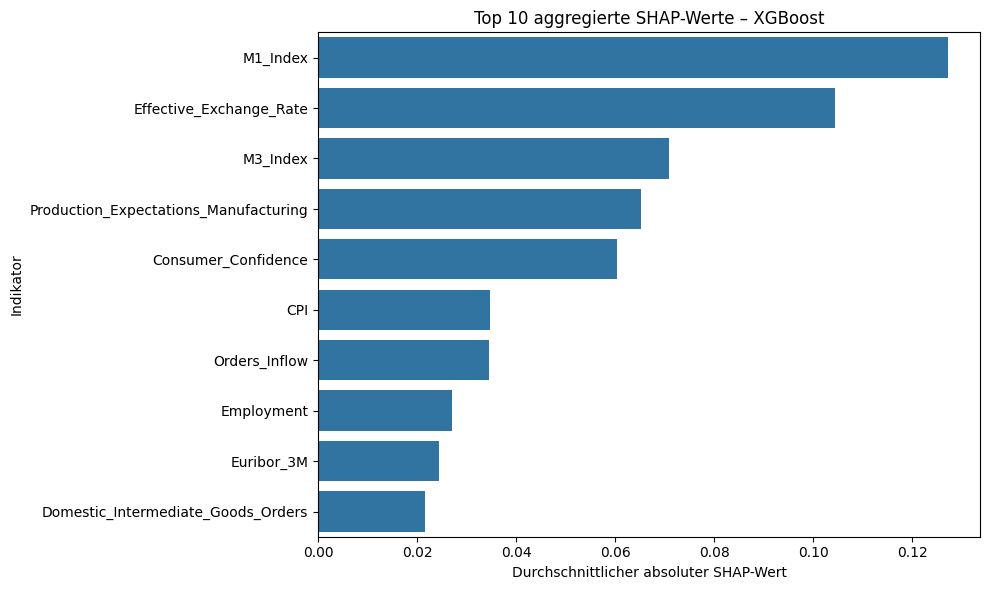


Top 10 SHAP-Indikatoren – XGBoost:


,SHAP Importance
M1_Index,0.127
Effective_Exchange_Rate,0.104
M3_Index,0.071
Production_Expectations_Manufacturing,0.065
Consumer_Confidence,0.060
CPI,0.035
Orders_Inflow,0.035
Employment,0.027
Euribor_3M,0.024
Domestic_Intermediate_Goods_Orders,0.022



SHAP-Analyse für Random Forest und XGBoost abgeschlossen.


In [34]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(SEED)

print("Starte SHAP-Analyse für Random Forest und XGBoost...")


# Helper Function: Aggregation der Lag-Features

def _aggregate_shap_values_to_indicators(
    shap_values_array,
    feature_names,
    original_feature_names
):
    """
    Aggregiert absolute SHAP-Werte der Lag-Features
    auf die ursprünglichen makroökonomischen Indikatoren.
    """

    aggregated_abs_shap = {
        name: [] for name in original_feature_names
    }

    feature_to_indicator_map = {}

    for full_feature_name in feature_names:
        indicator_name = full_feature_name.split('_lag_')[0]
        feature_to_indicator_map[full_feature_name] = indicator_name

    if shap_values_array.shape[1] != len(feature_names):
        raise ValueError(
            f"Mismatch between SHAP features "
            f"({shap_values_array.shape[1]}) and feature names "
            f"({len(feature_names)})."
        )

    for i, feature_name in enumerate(feature_names):

        indicator = feature_to_indicator_map.get(feature_name)

        if indicator in aggregated_abs_shap:
            aggregated_abs_shap[indicator].extend(
                np.abs(shap_values_array[:, i])
            )

    mean_abs_shap_by_indicator = {
        indicator: np.mean(values) if values else 0
        for indicator, values in aggregated_abs_shap.items()
    }

    return pd.Series(
        mean_abs_shap_by_indicator
    ).sort_values(ascending=False)



# Ursprüngliche Indikatoren bestimmen

all_lagged_features = X_final.columns.tolist()

original_feature_names = sorted(
    list(
        set(
            col.split('_lag_')[0]
            for col in all_lagged_features
        )
    )
)

print(
    f"Anzahl der ursprünglichen Indikatoren: "
    f"{len(original_feature_names)}"
)


# Speicherung der SHAP-Ergebnisse
all_models_aggregated_shap = {}



# Random Forest

print("\nBerechne SHAP-Werte für Random Forest...")

try:

    rf_model_inside_pipeline = (
        best_rf_model.named_steps['rf']
    )

    explainer_rf = shap.TreeExplainer(
        rf_model_inside_pipeline
    )

    shap_values_rf = explainer_rf.shap_values(
        X_final
    )

    # Positive Klasse (Rezession = 1)
    if isinstance(shap_values_rf, list):

        shap_values_rf_positive_class = (
            shap_values_rf[1]
        )

    elif (
        shap_values_rf.ndim == 3
        and shap_values_rf.shape[2] == 2
    ):

        shap_values_rf_positive_class = (
            shap_values_rf[:, :, 1]
        )

    else:
        raise ValueError(
            "Unexpected shape or type for "
            "Random Forest SHAP values."
        )

    aggregated_shap_rf = (
        _aggregate_shap_values_to_indicators(
            shap_values_rf_positive_class,
            all_lagged_features,
            original_feature_names
        )
    )

    all_models_aggregated_shap[
        'Random Forest'
    ] = aggregated_shap_rf

    print(
        "Aggregierte SHAP-Werte für "
        "Random Forest berechnet."
    )

    # Top-10-Visualisierung
    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=aggregated_shap_rf.head(10).values,
        y=aggregated_shap_rf.head(10).index
    )

    plt.title(
        'Top 10 aggregierte SHAP-Werte – Random Forest'
    )
    plt.xlabel(
        'Durchschnittlicher absoluter SHAP-Wert'
    )
    plt.ylabel('Indikator')

    plt.tight_layout()
    plt.show()

    print(
        "\nTop 10 SHAP-Indikatoren – Random Forest:"
    )

    display(
        aggregated_shap_rf
        .head(10)
        .to_frame(name='SHAP Importance')
        .round(3)
    )

except Exception as e:

    print(
        f"Fehler bei der SHAP-Analyse "
        f"für Random Forest: {e}"
    )

# XGBoost


print("\nBerechne SHAP-Werte für XGBoost...")

try:

    xgb_model_inside_pipeline = (
        best_xgb_model.named_steps['xgb']
    )

    explainer_xgb = shap.TreeExplainer(
        xgb_model_inside_pipeline
    )

    shap_values_xgb = (
        explainer_xgb.shap_values(X_final)
    )

    # Positive Klasse (Rezession = 1)
    if isinstance(shap_values_xgb, list):

        shap_values_xgb_positive_class = (
            shap_values_xgb[1]
        )

    elif (
        isinstance(shap_values_xgb, np.ndarray)
        and shap_values_xgb.ndim == 3
        and shap_values_xgb.shape[2] == 2
    ):

        shap_values_xgb_positive_class = (
            shap_values_xgb[:, :, 1]
        )

    else:

        shap_values_xgb_positive_class = (
            shap_values_xgb
        )

    aggregated_shap_xgb = (
        _aggregate_shap_values_to_indicators(
            shap_values_xgb_positive_class,
            all_lagged_features,
            original_feature_names
        )
    )

    all_models_aggregated_shap[
        'XGBoost'
    ] = aggregated_shap_xgb

    print(
        "Aggregierte SHAP-Werte für "
        "XGBoost berechnet."
    )

    # Top-10-Visualisierung
    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=aggregated_shap_xgb.head(10).values,
        y=aggregated_shap_xgb.head(10).index
    )

    plt.title(
        'Top 10 aggregierte SHAP-Werte – XGBoost'
    )
    plt.xlabel(
        'Durchschnittlicher absoluter SHAP-Wert'
    )
    plt.ylabel('Indikator')

    plt.tight_layout()
    plt.show()

    print(
        "\nTop 10 SHAP-Indikatoren – XGBoost:"
    )

    display(
        aggregated_shap_xgb
        .head(10)
        .to_frame(name='SHAP Importance')
        .round(3)
    )

except Exception as e:

    print(
        f"Fehler bei der SHAP-Analyse "
        f"für XGBoost: {e}"
    )


print(
    "\nSHAP-Analyse für Random Forest "
    "und XGBoost abgeschlossen."
)

**4.3.2 Permutation Importance der Logistischen Regression**

Zur Bestimmung der Bedeutung der Prädiktoren für die Logistische Regression wird die Permutation Importance innerhalb der zeitbasierten Cross-Validation berechnet. Die Importance-Werte werden zunächst für die einzelnen Lag-Features bestimmt und anschließend den ursprünglichen makroökonomischen Indikatoren zugeordnet und aggregiert. Abschließend werden die zehn wichtigsten Indikatoren tabellarisch und grafisch dargestellt.

Aggregierte Permutation Importance für Logistische Regression berechnet.


/tmp/ipykernel_830/3249785487.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=aggregated_perm_imp_lr.head(10).values, y=aggregated_perm_imp_lr.head(10).index, palette='viridis')


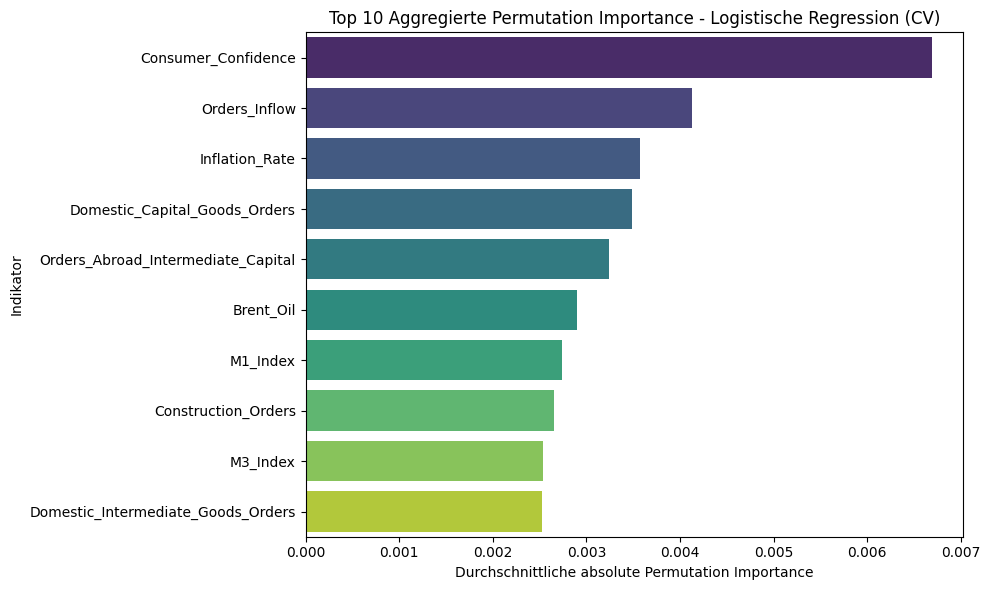


Top 10 Aggregierte Permutation Importance für Logistische Regression:


,Importance
Consumer_Confidence,0.007
Orders_Inflow,0.004
Inflation_Rate,0.004
Domestic_Capital_Goods_Orders,0.003
Orders_Abroad_Intermediate_Capital,0.003
Brent_Oil,0.003
M1_Index,0.003
Construction_Orders,0.003
M3_Index,0.003
Domestic_Intermediate_Goods_Orders,0.003


In [35]:
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Added for plotting

# Helper function to aggregate permutation importance from lagged features to original indicators
# This function was present in a previously deleted cell and is necessary for this cell's logic.
def _aggregate_permutation_importance_to_indicators(perm_importance_df, original_feature_names):
    """
    Aggregates Permutation Importance-values from lagged features to their original indicators.

    Args:
        perm_importance_df (pd.DataFrame): DataFrame with 'feature' and 'weight' columns.
                                            'feature' names are expected to be in 'OriginalFeatureName_lag_X' format.
        original_feature_names (list): List of original indicator names.

    Returns:
        pd.Series: Aggregated absolute Permutation Importance per original indicator,
                   sorted from most important to least important.
    """
    aggregated_abs_perm_imp = {name: [] for name in original_feature_names}

    feature_to_indicator_map = {}
    for full_feature_name in perm_importance_df['feature'].tolist():
        indicator_name = full_feature_name.split('_lag_')[0]
        feature_to_indicator_map[full_feature_name] = indicator_name

    for _, row in perm_importance_df.iterrows():
        full_feature_name = row['feature']
        importance_weight = abs(row['weight']) # Use absolute importance
        indicator = feature_to_indicator_map.get(full_feature_name)

        if indicator and indicator in aggregated_abs_perm_imp:
            aggregated_abs_perm_imp[indicator].append(importance_weight)

    mean_abs_perm_imp_by_indicator = {
        indicator: np.mean(values) if values else 0
        for indicator, values in aggregated_abs_perm_imp.items()
    }
    aggregated_importance_series = pd.Series(mean_abs_perm_imp_by_indicator)
    return aggregated_importance_series.sort_values(ascending=False)

all_perm_importances = []

# Prepare Logistic Regression parameters for direct use in the model (without pipeline prefix)
# best_log_reg_params has keys like 'log_reg__C', 'log_reg__penalty'
logreg_model_params = {
    key.replace('log_reg__', ''): value
    for key, value in best_log_reg_params.items() # Fix: Use best_log_reg_params
}
# Add other fixed parameters used during hyperparameter tuning
logreg_model_params['solver'] = "saga"
logreg_model_params['random_state'] = SEED
logreg_model_params['class_weight'] = "balanced"
logreg_model_params['max_iter'] = 5000 # Increased max_iter to address ConvergenceWarning

for fold_idx, (train_index, test_index) in enumerate(custom_cv):

    # Daten aufteilen
    X_train = X_final.iloc[train_index]
    X_test = X_final.iloc[test_index]

    y_train = y_final.iloc[train_index]
    y_test = y_final.iloc[test_index]

    # Skalierung
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Modell neu trainieren mit den extrahierten und fixed Parametern
    model = LogisticRegression(**logreg_model_params)
    model.fit(X_train_scaled, y_train)

    # Permutation Importance auf den Testdaten
    perm = permutation_importance(
        estimator=model,
        X=X_test_scaled,
        y=y_test,
        scoring="roc_auc",
        n_repeats=10,
        random_state=SEED,
        n_jobs=-1
    )

    all_perm_importances.append(perm.importances_mean)

# Calculate the mean of permutation importances across all folds
mean_perm_importances_across_folds = np.mean(all_perm_importances, axis=0)

# Create a temporary DataFrame for aggregation
perm_df = pd.DataFrame({
    'feature': X_final.columns,
    'weight': mean_perm_importances_across_folds
})

# Aggregate to original indicators
aggregated_perm_imp_lr = _aggregate_permutation_importance_to_indicators(
    perm_df,
    original_feature_names # This variable is available from the kernel state.
)

# Store aggregated Permutation Importances for Logistic Regression
# Initialize all_models_aggregated_perm_imp if it doesn't exist
if 'all_models_aggregated_perm_imp' not in globals():
    all_models_aggregated_perm_imp = {}
all_models_aggregated_perm_imp['Logistic Regression'] = aggregated_perm_imp_lr
print("Aggregierte Permutation Importance für Logistische Regression berechnet.")

# Plotting for Logistic Regression
plt.figure(figsize=(10, 6))
# Using .values and .index for plotting, as sns.barplot expects array-like inputs
sns.barplot(x=aggregated_perm_imp_lr.head(10).values, y=aggregated_perm_imp_lr.head(10).index, palette='viridis')
plt.title('Top 10 Aggregierte Permutation Importance - Logistische Regression (CV)')
plt.xlabel('Durchschnittliche absolute Permutation Importance')
plt.ylabel('Indikator')
plt.tight_layout()
plt.show()

# Display the table for LR Permutation Importance
print("\nTop 10 Aggregierte Permutation Importance für Logistische Regression:")
display(aggregated_perm_imp_lr.head(10).to_frame(name='Importance').round(3).replace(0.0, '–'))

**4.3.3 Permutation Importance Berechnung für GRU**

Zur Bestimmung der wichtigsten Indikatoren des GRU-Modells wird eine sequenzielle Permutation Importance durchgeführt. Dabei werden die Werte eines Indikators über alle 12 Zeitschritte gemeinsam permutiert und anschließend die Veränderung der ROC-AUC gemessen. Die Berechnung erfolgt für jeden Fold der Expanding-Window Time-Series Cross-Validation und wird über alle Folds gemittelt. Abschließend werden die zehn wichtigsten Indikatoren tabellarisch und grafisch dargestellt.

Starte Permutation Importance Berechnung für GRU...
Permutation Importance für GRU Fold 1 berechnet.
Permutation Importance für GRU Fold 2 berechnet.
Permutation Importance für GRU Fold 3 berechnet.
Permutation Importance für GRU Fold 4 berechnet.
Permutation Importance für GRU Fold 5 berechnet.
Permutation Importance für GRU Fold 6 berechnet.

Aggregierte Permutation Importance für GRU berechnet.


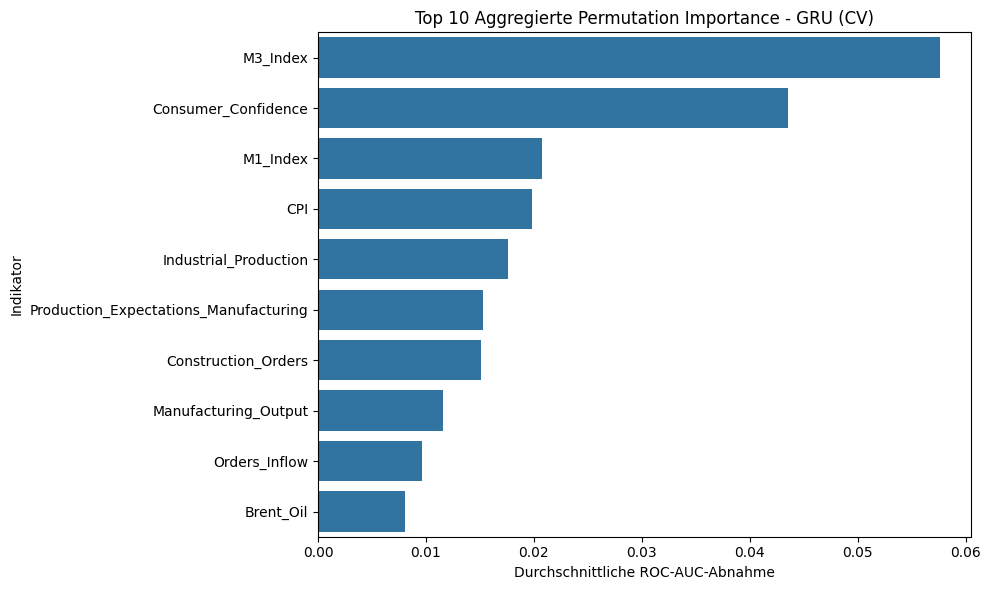


Top 10 Aggregierte Permutation Importance für GRU:


,Importance
M3_Index,0.058
Consumer_Confidence,0.044
M1_Index,0.021
CPI,0.020
Industrial_Production,0.018
Production_Expectations_Manufacturing,0.015
Construction_Orders,0.015
Manufacturing_Output,0.012
Orders_Inflow,0.010
Brent_Oil,0.008



Permutation Importance-Analyse für GRU abgeschlossen.


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Ensure reproducibility settings (copied from previous GRU cells)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Starte Permutation Importance Berechnung für GRU...")

# Re-define create_gru_model to ensure it is available

def create_gru_model(gru_units, dropout_rate, learning_rate, input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(units=gru_units, activation="tanh"),
        Dropout(rate=dropout_rate),
        Dense(units=1, activation="sigmoid")
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Sequential Permutation Importance function

def calculate_sequential_permutation_importance(
    model,
    X_val,
    y_val,
    feature_names,
    n_repeats=10,
    random_state=42
):
    """
    Berechnet die sequenzielle Permutation Importance für GRU/LSTM.

    Ein Indikator wird über alle Zeitschritte hinweg gemeinsam
    zwischen den Beobachtungen permutiert.

    X_val Shape:
    [Samples, Time_Steps, Features]

    Importance:
    Baseline ROC-AUC - ROC-AUC nach Permutation
    """

    y_val_array = np.asarray(y_val)

    # ROC-AUC requires both classes
    if len(np.unique(y_val_array)) < 2:
        print(
            "Warnung: Der Test-Fold enthält nur eine Klasse. "
            "Permutation Importance wird für diesen Fold übersprungen."
        )
        return None

    # 1. Baseline Score (ROC-AUC) berechnen
    baseline_probs = model.predict(
        X_val,
        verbose=0
    ).ravel()

    baseline_auc = roc_auc_score(
        y_val_array,
        baseline_probs
    )

    importances = {}

    rng = np.random.default_rng(random_state)

    # 2. Iteration über jeden Indikator (Feature-Achse)
    for i, feat in enumerate(feature_names):

        repeated_importances = []

        # Permutation mehrfach wiederholen
        for _ in range(n_repeats):

            X_permuted = X_val.copy()

            # Zufällige Permutation der Samples
            shuffled_indices = rng.permutation(
                len(X_val)
            )

            # Vertauschen des Indikators über die gesamte
            # Sequenz (alle 12 Time Steps)
            X_permuted[:, :, i] = (
                X_val[shuffled_indices, :, i]
            )

            # 3. ROC-AUC nach Permutation berechnen
            permuted_probs = model.predict(
                X_permuted,
                verbose=0
            ).ravel()

            permuted_auc = roc_auc_score(
                y_val_array,
                permuted_probs
            )

            # Wichtigkeit = Verlust an Vorhersagegüte
            repeated_importances.append(
                baseline_auc - permuted_auc
            )

        # Durchschnitt über alle Wiederholungen
        importances[feat] = np.mean(
            repeated_importances
        )

    return importances


# Data reshaping constants

num_timesteps = 12

original_features_count = (
    X_final.shape[1] // num_timesteps
)

# Original feature names derived from lagged feature names

original_feature_names = []

for col in X_final.columns:
    if "_lag_" in col:
        feature_name = col.split("_lag_")[0]
    else:
        feature_name = col

    if feature_name not in original_feature_names:
        original_feature_names.append(feature_name)


# Check whether feature dimensions are consistent

if len(original_feature_names) != original_features_count:
    raise ValueError(
        f"Anzahl der ursprünglichen Indikatoren "
        f"({len(original_feature_names)}) stimmt nicht mit "
        f"der Feature-Dimension des GRU-Modells "
        f"({original_features_count}) überein."
    )


# Ensure reshaped GRU data are available

X_reshaped_for_gru = X_final.values.reshape(
    X_final.shape[0],
    num_timesteps,
    original_features_count
)


all_fold_permutation_importances = []


for fold_idx, (train_index, test_index) in enumerate(custom_cv):

    # Set seeds for each fold to ensure reproducibility

    current_fold_seed = SEED + fold_idx

    tf.keras.backend.clear_session()

    tf.keras.utils.set_random_seed(
        current_fold_seed
    )

    np.random.seed(
        current_fold_seed
    )

    random.seed(
        current_fold_seed
    )

    os.environ["PYTHONHASHSEED"] = str(
        current_fold_seed
    )


    X_train_fold_reshaped = (
        X_reshaped_for_gru[train_index]
    )

    X_test_fold_reshaped = (
        X_reshaped_for_gru[test_index]
    )

    y_train_fold = y_final.iloc[
        train_index
    ]

    y_test_fold = y_final.iloc[
        test_index
    ]


    # Per-Fold Standardisierung

    scaler = StandardScaler()

    X_train_2d = X_train_fold_reshaped.reshape(
        -1,
        original_features_count
    )

    X_test_2d = X_test_fold_reshaped.reshape(
        -1,
        original_features_count
    )

    scaler.fit(
        X_train_2d
    )

    X_train_scaled = scaler.transform(
        X_train_2d
    ).reshape(
        X_train_fold_reshaped.shape
    )

    X_test_scaled = scaler.transform(
        X_test_2d
    ).reshape(
        X_test_fold_reshaped.shape
    )


    # Class Weights berechnen

    class_counts = y_train_fold.value_counts()

    class_weights = {}

    if 0 in class_counts:
        class_weights[0] = (
            len(y_train_fold)
            / (2 * class_counts[0])
        )
    else:
        class_weights[0] = 1.0

    if 1 in class_counts:
        class_weights[1] = (
            len(y_train_fold)
            / (2 * class_counts[1])
        )
    else:
        class_weights[1] = 1.0


    # Create GRU model with best parameters

    gru_model_fold = create_gru_model(
        gru_units=best_gru_params["gru_units"],
        dropout_rate=best_gru_params["dropout_rate"],
        learning_rate=best_gru_params["learning_rate"],
        input_shape=(
            num_timesteps,
            original_features_count
        )
    )


    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )


    gru_model_fold.fit(
        X_train_scaled,
        y_train_fold,
        validation_split=0.2,
        epochs=best_gru_params["epochs"],
        batch_size=best_gru_params["batch_size"],
        class_weight=class_weights,
        callbacks=[early_stopping],
        shuffle=False,
        verbose=0
    )


    # Calculate permutation importance for the current fold

    fold_importances = (
        calculate_sequential_permutation_importance(
            model=gru_model_fold,
            X_val=X_test_scaled,
            y_val=y_test_fold,
            feature_names=original_feature_names,
            n_repeats=10,
            random_state=current_fold_seed
        )
    )


    if fold_importances is not None:

        all_fold_permutation_importances.append(
            fold_importances
        )

        print(
            f"Permutation Importance für GRU "
            f"Fold {fold_idx + 1} berechnet."
        )


# Aggregate permutation importances across all folds

# Convert list of dictionaries to DataFrame
# and calculate mean

if all_fold_permutation_importances:

    mean_gru_perm_importances = (
        pd.DataFrame(
            all_fold_permutation_importances
        )
        .mean()
        .sort_values(
            ascending=False
        )
    )

else:

    mean_gru_perm_importances = pd.Series(
        dtype=float
    )


# Store aggregated Permutation Importances for GRU

# Initialize dictionary if it does not exist

if "all_models_aggregated_perm_imp" not in globals():
    all_models_aggregated_perm_imp = {}

all_models_aggregated_perm_imp["GRU"] = (
    mean_gru_perm_importances
)

print(
    "\nAggregierte Permutation Importance "
    "für GRU berechnet."
)


# Plotting for GRU

TOP_N_FEATURES = 10

plt.figure(figsize=(10, 6))

if not mean_gru_perm_importances.empty:

    sns.barplot(
        x=mean_gru_perm_importances.head(
            TOP_N_FEATURES
        ).values,
        y=mean_gru_perm_importances.head(
            TOP_N_FEATURES
        ).index
    )

    plt.title(
        "Top 10 Aggregierte Permutation Importance - GRU (CV)"
    )

    plt.xlabel(
        "Durchschnittliche ROC-AUC-Abnahme"
    )

    plt.ylabel(
        "Indikator"
    )

    plt.tight_layout()
    plt.show()


    # Display the table for GRU Permutation Importance

    print(
        f"\nTop {TOP_N_FEATURES} Aggregierte "
        "Permutation Importance für GRU:"
    )

    display(
        mean_gru_perm_importances
        .head(TOP_N_FEATURES)
        .to_frame(name="Importance")
        .round(3)
        .replace(0.0, "–")
    )

else:

    plt.close()

    print(
        "Keine Permutation Importances für GRU "
        "zum Plotten oder Anzeigen gefunden."
    )


print(
    "\nPermutation Importance-Analyse "
    "für GRU abgeschlossen."
)

**4.3.4 Permutation Importance Berechnung für LSTM**

Für das LSTM-Modell wird die Relevanz der einzelnen Indikatoren mithilfe der sequenziellen Permutation Importance untersucht. Hierzu wird jeder Indikator über alle 12 Zeitschritte gemeinsam zufällig permutiert. Anschließend wird geprüft, wie stark sich dadurch die ROC-AUC des Modells verschlechtert. Eine stärkere Abnahme der ROC-AUC weist auf eine höhere Bedeutung des jeweiligen Indikators für die Rezessionsklassifikation hin. Die Importance-Werte werden über alle Folds der Expanding-Window Time-Series Cross-Validation gemittelt. Die zehn Indikatoren mit der höchsten durchschnittlichen Importance werden anschließend tabellarisch und grafisch ausgegeben.

Starte Permutation Importance für LSTM...
LSTM Permutation Importance – Fold 1 abgeschlossen.
LSTM Permutation Importance – Fold 2 abgeschlossen.
LSTM Permutation Importance – Fold 3 abgeschlossen.
LSTM Permutation Importance – Fold 4 abgeschlossen.
LSTM Permutation Importance – Fold 5 abgeschlossen.
LSTM Permutation Importance – Fold 6 abgeschlossen.

Top 10 Indikatoren – LSTM:


,Permutation Importance
Exports,0.035
Domestic_Intermediate_Goods_Orders,0.034
M1_Index,0.029
Manufacturing_Output,0.026
German_Bond_Yield,0.026
Imports,0.021
Construction_Orders,0.017
Orders_Abroad_Intermediate_Capital,0.017
Exchange_Rate_USD_EUR,0.015
Inflation_Rate,0.013


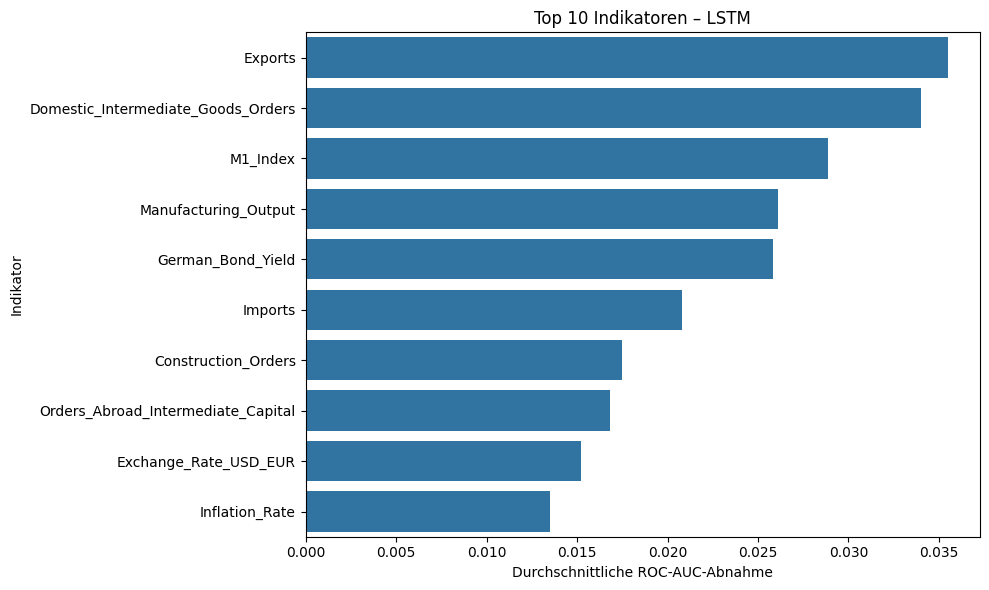


Permutation Importance für LSTM abgeschlossen.


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# 1. Reproduzierbarkeit
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Starte Permutation Importance für LSTM...")


# 2. LSTM-Modell definieren
def create_lstm_model(lstm_units, dropout_rate, learning_rate, input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units=lstm_units, activation="tanh"),
        Dropout(rate=dropout_rate),
        Dense(units=1, activation="sigmoid")
    ])

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# 3. Sequenzielle Permutation Importance
def calculate_sequential_permutation_importance(
    model, X_val, y_val, feature_names,
    n_repeats=10, random_state=42
):
    baseline_probs = model.predict(X_val, verbose=0).ravel()
    baseline_auc = roc_auc_score(y_val, baseline_probs)

    rng = np.random.default_rng(random_state)
    importances = {}

    for i, feature in enumerate(feature_names):
        repeated_importances = []

        for _ in range(n_repeats):
            X_permuted = X_val.copy()
            shuffled_indices = rng.permutation(len(X_val))

            # Indikator über alle 12 Zeitschritte gemeinsam permutieren
            X_permuted[:, :, i] = X_permuted[shuffled_indices, :, i]

            permuted_probs = model.predict(
                X_permuted,
                verbose=0
            ).ravel()

            permuted_auc = roc_auc_score(
                y_val,
                permuted_probs
            )

            repeated_importances.append(
                baseline_auc - permuted_auc
            )

        importances[feature] = np.mean(repeated_importances)

    return importances


# 4. Daten vorbereiten
num_timesteps = 12
original_features_count = X_final.shape[1] // num_timesteps

original_feature_names = sorted(
    list(set(
        col.split("_lag_")[0]
        for col in X_final.columns
    ))
)

if len(original_feature_names) != original_features_count:
    raise ValueError(
        "Die Anzahl der Indikatoren stimmt nicht mit "
        "der Feature-Dimension der LSTM-Daten überein."
    )

all_fold_lstm_permutation_importances = []


# 5. Expanding-Window Cross-Validation
for fold_idx, (train_index, test_index) in enumerate(custom_cv):

    current_fold_seed = SEED + fold_idx

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(current_fold_seed)
    np.random.seed(current_fold_seed)
    random.seed(current_fold_seed)

    X_train_fold = X_reshaped_for_lstm[train_index]
    X_test_fold = X_reshaped_for_lstm[test_index]

    y_train_fold = y_final.iloc[train_index]
    y_test_fold = y_final.iloc[test_index]

    # Standardisierung pro Fold
    scaler = StandardScaler()

    X_train_2d = X_train_fold.reshape(
        -1, original_features_count
    )
    X_test_2d = X_test_fold.reshape(
        -1, original_features_count
    )

    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(
        X_train_2d
    ).reshape(X_train_fold.shape)

    X_test_scaled = scaler.transform(
        X_test_2d
    ).reshape(X_test_fold.shape)

    # Klassenungleichgewicht berücksichtigen
    class_counts = y_train_fold.value_counts()

    class_weights = {
        0: len(y_train_fold) / (2 * class_counts[0])
        if 0 in class_counts else 1.0,

        1: len(y_train_fold) / (2 * class_counts[1])
        if 1 in class_counts else 1.0
    }

    # LSTM mit optimalen Hyperparametern
    lstm_model_fold = create_lstm_model(
        lstm_units=best_lstm_params["lstm_units"],
        dropout_rate=best_lstm_params["dropout_rate"],
        learning_rate=best_lstm_params["learning_rate"],
        input_shape=(num_timesteps, original_features_count)
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=0
    )

    lstm_model_fold.fit(
        X_train_scaled,
        y_train_fold,
        validation_split=0.2,
        epochs=best_lstm_params["epochs"],
        batch_size=best_lstm_params["batch_size"],
        class_weight=class_weights,
        callbacks=[early_stopping],
        shuffle=False,
        verbose=0
    )

    # ROC-AUC benötigt beide Klassen
    if len(np.unique(y_test_fold)) < 2:
        print(f"Fold {fold_idx + 1} übersprungen: nur eine Klasse.")
        continue

    fold_importances = calculate_sequential_permutation_importance(
        model=lstm_model_fold,
        X_val=X_test_scaled,
        y_val=y_test_fold,
        feature_names=original_feature_names,
        n_repeats=10,
        random_state=current_fold_seed
    )

    all_fold_lstm_permutation_importances.append(
        fold_importances
    )

    print(
        f"LSTM Permutation Importance – "
        f"Fold {fold_idx + 1} abgeschlossen."
    )


# 6. Ergebnisse über alle Folds aggregieren
if all_fold_lstm_permutation_importances:
    mean_lstm_perm_importances = (
        pd.DataFrame(all_fold_lstm_permutation_importances)
        .mean()
        .sort_values(ascending=False)
    )
else:
    mean_lstm_perm_importances = pd.Series(dtype=float)

if "all_models_aggregated_perm_imp" not in globals():
    all_models_aggregated_perm_imp = {}

all_models_aggregated_perm_imp["LSTM"] = mean_lstm_perm_importances


# 7. Top 10 Indikatoren
TOP_N_FEATURES = 10
top_lstm_importances = mean_lstm_perm_importances.head(
    TOP_N_FEATURES
)

print("\nTop 10 Indikatoren – LSTM:")
display(
    top_lstm_importances
    .to_frame(name="Permutation Importance")
    .round(3)
)


# 8. Visualisierung
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_lstm_importances.values,
    y=top_lstm_importances.index
)

plt.title("Top 10 Indikatoren – LSTM")
plt.xlabel("Durchschnittliche ROC-AUC-Abnahme")
plt.ylabel("Indikator")
plt.tight_layout()
plt.show()

print("\nPermutation Importance für LSTM abgeschlossen.")

Aggregierte Rangliste der robustesten Indikatoren (Top 10 Vorkommen über alle Modelle):


,Indicator,Top 10 Occurrences
0,M1_Index,5
1,Consumer_Confidence,4
2,M3_Index,4
3,Construction_Orders,3
4,Inflation_Rate,3
5,Orders_Inflow,3
6,CPI,3
7,Production_Expectations_Manufacturing,3
8,Domestic_Intermediate_Goods_Orders,3
9,Orders_Abroad_Intermediate_Capital,2


/tmp/ipykernel_830/4217541092.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Top 10 Occurrences', y='Indicator', data=aggr_rank_df, palette='viridis')


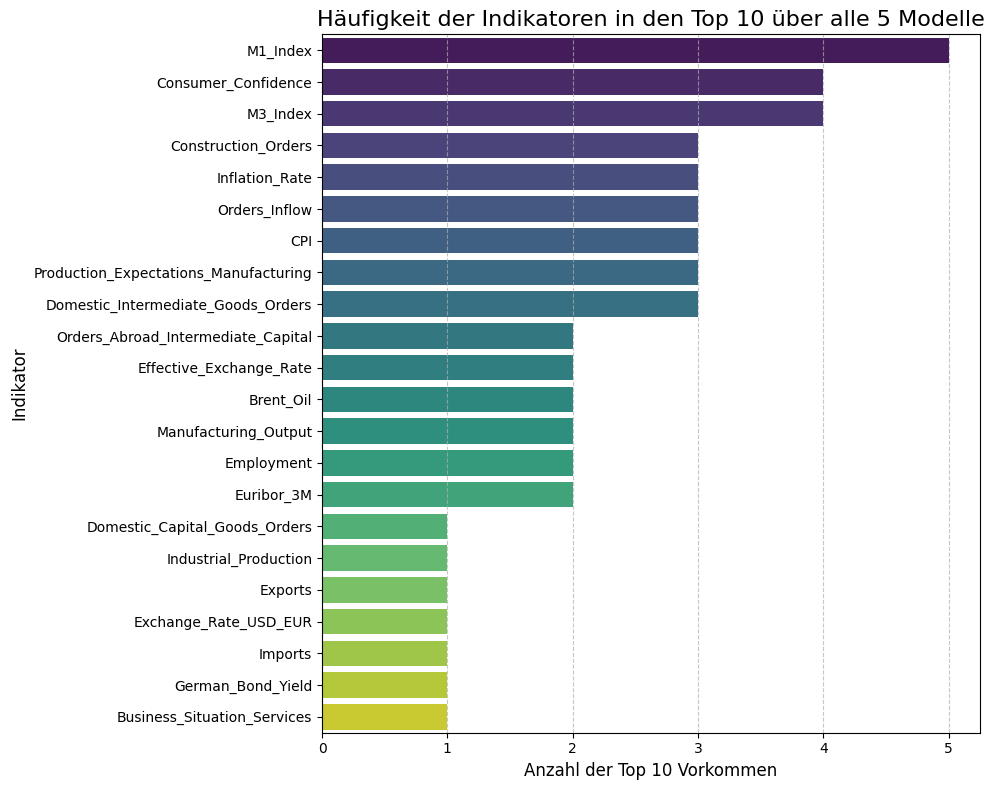


Diese Rangliste zeigt, welche Indikatoren am häufigsten zu den Top 10 der wichtigsten Merkmale in den fünf verschiedenen Modellen gehören. Dies ist eine robuste Methode, um die Schlüsselindikatoren für die Forschungsfrage zu identifizieren.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure all_models_aggregated_shap and all_models_aggregated_perm_imp are available
# from the kernel state.
# Combine all importance results into a single dictionary
all_model_importances = {}

if 'all_models_aggregated_perm_imp' in globals():
    # Convert any potentially non-Series values to Series for consistency
    for model, importance in all_models_aggregated_perm_imp.items():
        if not isinstance(importance, pd.Series):
            all_models_aggregated_perm_imp[model] = pd.Series(importance)
    all_model_importances.update(all_models_aggregated_perm_imp)

if 'all_models_aggregated_shap' in globals():
    # Convert any potentially non-Series values to Series for consistency
    for model, importance in all_models_aggregated_shap.items():
        if not isinstance(importance, pd.Series):
            all_models_aggregated_shap[model] = pd.Series(importance)
    all_model_importances.update(all_models_aggregated_shap)

# Dictionary to store counts of indicators in top 10
top_10_indicator_counts = {}

# Iterate through each model's importances and count top 10 occurrences
for model_name, importance_series in all_model_importances.items():
    # Ensure numeric type and drop NaN
    importance_series = pd.to_numeric(importance_series, errors='coerce').dropna()

    # Get top 10 indicators based on their positive importance
    # Filter for positive importance values before taking nlargest
    filtered_importance = importance_series[importance_series > 0].nlargest(10)

    for indicator in filtered_importance.index:
        top_10_indicator_counts[indicator] = top_10_indicator_counts.get(indicator, 0) + 1

# Convert to DataFrame for easy sorting and display
aggr_rank_df = pd.DataFrame(
    list(top_10_indicator_counts.items()),
    columns=['Indicator', 'Top 10 Occurrences']
)

# Sort by occurrences in descending order
aggr_rank_df = aggr_rank_df.sort_values(by='Top 10 Occurrences', ascending=False).reset_index(drop=True)

print("Aggregierte Rangliste der robustesten Indikatoren (Top 10 Vorkommen über alle Modelle):")
display(aggr_rank_df)

# Visualization (Horizontal Bar Chart)
plt.figure(figsize=(10, 8))
sns.barplot(x='Top 10 Occurrences', y='Indicator', data=aggr_rank_df, palette='viridis')
plt.title('Häufigkeit der Indikatoren in den Top 10 über alle 5 Modelle', fontsize=16)
plt.xlabel('Anzahl der Top 10 Vorkommen', fontsize=12)
plt.ylabel('Indikator', fontsize=12)
# Ensure integer ticks for the x-axis
plt.xticks(np.arange(0, aggr_rank_df['Top 10 Occurrences'].max() + 1, 1))
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nDiese Rangliste zeigt, welche Indikatoren am häufigsten zu den Top 10 der wichtigsten Merkmale in den fünf verschiedenen Modellen gehören. Dies ist eine robuste Methode, um die Schlüsselindikatoren für die Forschungsfrage zu identifizieren.")


**4.5 Analyse der Fehlklassifikationen und Rezessionssignale**

Die Fehlklassifikationen der fünf Modelle werden untersucht, um zwischen False Positives und False Negatives zu unterscheiden. False Positives stellen dabei fälschlicherweise vorhergesagte Rezessionssignale dar, während False Negatives tatsächlich eingetretene, aber vom Modell nicht erkannte Rezessionen repräsentieren. Zusätzlich wird für jedes Modell die gesamte Fehlklassifikationsrate bestimmt. Die Analyse ergänzt die aggregierten Evaluationsmetriken und ermöglicht eine gezieltere Beurteilung der Qualität der Rezessionserkennung.

In [47]:
print("Starte Analyse der Fehlklassifikationen...")

# Dictionary to store misclassified data for each model
all_models_misclassifications = {}

# Helper function to get original feature names for display
def get_original_feature_names(feature_names):
    return sorted(list(set(col.split('_lag_')[0] for col in feature_names)))

# Get the feature names from X_final (excluding 'Datum' and 'Rezession')
current_feature_names = X_final.columns.tolist()

# Iterate through each model's predictions
model_prediction_data = {
    'Logistic Regression': {'y_true': log_reg_all_y_true, 'y_pred': log_reg_all_y_pred, 'y_proba': log_reg_all_y_proba},
    'Random Forest': {'y_true': rf_all_y_true, 'y_pred': rf_all_y_pred, 'y_proba': rf_all_y_proba},
    'XGBoost': {'y_true': xgb_all_y_true, 'y_pred': xgb_all_y_pred, 'y_proba': xgb_all_y_proba},
    'GRU': {'y_true': gru_all_y_true, 'y_pred': gru_all_y_pred, 'y_proba': gru_all_y_proba},
    'LSTM': {'y_true': lstm_all_y_true, 'y_pred': lstm_all_y_pred, 'y_proba': lstm_all_y_proba}
}

for model_name, data in model_prediction_data.items():
    # Create a DataFrame for predictions and true labels
    predictions_df = pd.DataFrame({
        'y_true': data['y_true'],
        'y_pred': data['y_pred'],
        'y_proba': data['y_proba']
    })

    # Identify misclassifications
    misclassified_df = predictions_df[predictions_df['y_true'] != predictions_df['y_pred']].copy()

    # Store for further analysis if needed
    all_models_misclassifications[model_name] = misclassified_df

    print(f"\n--- Misklassifikationsanalyse für {model_name} ---")
    print(f"Anzahl der Instanzen: {len(predictions_df)}")
    print(f"Anzahl der Fehlklassifikationen: {len(misclassified_df)}")
    if not predictions_df.empty:
        misclassification_rate = len(misclassified_df) / len(predictions_df)
        print(f"Fehlklassifikationsrate: {misclassification_rate:.2%}")

    if not misclassified_df.empty:
        print("\nErste 5 fehlklassifizierte Instanzen:")
        display(misclassified_df.head())

        # Analyze false positives and false negatives
        false_positives = misclassified_df[misclassified_df['y_true'] == 0]
        false_negatives = misclassified_df[misclassified_df['y_true'] == 1]

        print(f"\nAnzahl Falsch-Positive (True=0, Pred=1): {len(false_positives)}")
        print(f"Anzahl Falsch-Negative (True=1, Pred=0): {len(false_negatives)}")

        # Optional: Further analysis of misclassified instances' features
        # For this, we'd need to link back to X_final based on the original indices
        # The 'y_true', 'y_pred', 'y_proba' lists are pooled, so direct indexing to X_final is not straightforward.
        # To do this correctly, we would need to store original indices during the evaluation loop.
        # For now, we will focus on the prediction outcomes.
    else:
        print("Keine Fehlklassifikationen gefunden.")

print("\nAnalyse der Fehlklassifikationen abgeschlossen.")

Starte Analyse der Fehlklassifikationen...

--- Misklassifikationsanalyse für Logistic Regression ---
Anzahl der Instanzen: 143
Anzahl der Fehlklassifikationen: 57
Fehlklassifikationsrate: 39.86%

Erste 5 fehlklassifizierte Instanzen:


,y_true,y_pred,y_proba
6,1,0,0.031019
7,1,0,0.077573
8,1,0,0.186981
9,1,0,0.240862
10,1,0,0.288445



Anzahl Falsch-Positive (True=0, Pred=1): 17
Anzahl Falsch-Negative (True=1, Pred=0): 40

--- Misklassifikationsanalyse für Random Forest ---
Anzahl der Instanzen: 143
Anzahl der Fehlklassifikationen: 75
Fehlklassifikationsrate: 52.45%

Erste 5 fehlklassifizierte Instanzen:


,y_true,y_pred,y_proba
6,1,0,0.004620
7,1,0,0.010000
8,1,0,0.000000
9,1,0,0.000000
10,1,0,0.019866



Anzahl Falsch-Positive (True=0, Pred=1): 0
Anzahl Falsch-Negative (True=1, Pred=0): 75

--- Misklassifikationsanalyse für XGBoost ---
Anzahl der Instanzen: 143
Anzahl der Fehlklassifikationen: 65
Fehlklassifikationsrate: 45.45%

Erste 5 fehlklassifizierte Instanzen:


...


Anzahl Falsch-Positive (True=0, Pred=1): 9
Anzahl Falsch-Negative (True=1, Pred=0): 56

--- Misklassifikationsanalyse für GRU ---
Anzahl der Instanzen: 143
Anzahl der Fehlklassifikationen: 55
Fehlklassifikationsrate: 38.46%

Erste 5 fehlklassifizierte Instanzen:


,y_true,y_pred,y_proba
6,1,0,0.242422
7,1,0,0.319206
8,1,0,0.394607
9,1,0,0.384505
10,1,0,0.422193



Anzahl Falsch-Positive (True=0, Pred=1): 20
Anzahl Falsch-Negative (True=1, Pred=0): 35

--- Misklassifikationsanalyse für LSTM ---
Anzahl der Instanzen: 143
Anzahl der Fehlklassifikationen: 50
Fehlklassifikationsrate: 34.97%

Erste 5 fehlklassifizierte Instanzen:


,y_true,y_pred,y_proba
6,1,0,0.013031
7,1,0,0.038545
8,1,0,0.141408
9,1,0,0.065780
10,1,0,0.052461



Anzahl Falsch-Positive (True=0, Pred=1): 17
Anzahl Falsch-Negative (True=1, Pred=0): 33

Analyse der Fehlklassifikationen abgeschlossen.


**4.5.1 Vergleich der Fehlklassifikationen zwischen den Modellen**

Die Fehlklassifikationsergebnisse aller Modelle werden in einer gemeinsamen Tabelle zusammengeführt. Für jedes Modell werden die Gesamtzahl der Fehlklassifikationen, die Fehlklassifikationsrate sowie die Anzahl der False Positives und False Negatives ausgewiesen. Dadurch lässt sich insbesondere vergleichen, welche Modelle zu falschen Rezessionssignalen neigen und welche tatsächliche Rezessionen häufiger übersehen.

In [49]:
import pandas as pd

print("Erstelle Vergleichstabelle der Fehlklassifikationen...")

# Prepare data for the misclassification comparison table
misclassification_comparison_rows = []

for model_name, data in model_prediction_data.items():
    # Re-create predictions_df and misclassified_df for calculation consistency
    predictions_df = pd.DataFrame({
        'y_true': data['y_true'],
        'y_pred': data['y_pred'],
        'y_proba': data['y_proba']
    })
    misclassified_df = predictions_df[predictions_df['y_true'] != predictions_df['y_pred']].copy()

    total_instances = len(predictions_df)
    num_misclassifications = len(misclassified_df)
    misclassification_rate = num_misclassifications / total_instances if total_instances > 0 else 0

    false_positives = misclassified_df[misclassified_df['y_true'] == 0]
    false_negatives = misclassified_df[misclassified_df['y_true'] == 1]

    misclassification_comparison_rows.append({
        'Model': model_name,
        'Total Instances': total_instances,
        'Misclassifications': num_misclassifications,
        'Misclassification Rate': f'{misclassification_rate:.2%}',
        'False Positives': len(false_positives),
        'False Negatives': len(false_negatives)
    })

misclassification_comparison_df = pd.DataFrame(misclassification_comparison_rows)

print("Vergleichstabelle der Fehlklassifikationen:")
display(misclassification_comparison_df)


Erstelle Vergleichstabelle der Fehlklassifikationen...
Vergleichstabelle der Fehlklassifikationen:


,Model,Total Instances,Misclassifications,Misclassification Rate,False Positives,False Negatives
0,Logistic Regression,143,57,39.86%,17,40
1,Random Forest,143,75,52.45%,0,75
2,XGBoost,143,65,45.45%,9,56
3,GRU,143,55,38.46%,20,35
4,LSTM,143,50,34.97%,17,33
